In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim

device = 'cuda'

In [2]:
from sda.mcs import KolmogorovFlow

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=2


In [3]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_linear =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
model_linear.load_state_dict(checkpoint)

model_cubic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_211/best_model.pth')
model_cubic.load_state_dict(checkpoint)

model_quadratic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_212/best_model.pth')
model_quadratic.load_state_dict(checkpoint)

model_piecewise =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_213/best_model.pth')
model_piecewise.load_state_dict(checkpoint)

model_linear_0 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_42/best_model.pth')
model_linear_0.load_state_dict(checkpoint)

model_psd_plus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_215/best_model.pth')
model_psd_plus.load_state_dict(checkpoint)


<All keys matched successfully>

In [4]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_cubic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_44/best_model.pth')
model_cubic.load_state_dict(checkpoint)

model_quadratic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_20/best_model.pth')
model_quadratic.load_state_dict(checkpoint)

<All keys matched successfully>

In [5]:
model_logminus5uniform = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_234/best_model.pth')
model_logminus5uniform.load_state_dict(checkpoint)

model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_linear =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
model_linear.load_state_dict(checkpoint)

models = {'Linear Schedule': model_linear, 'PSD Schedule':  model_psd, 'LogMinus5Uniform Schedule': model_logminus5uniform}

In [6]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [7]:
def compute_estimate(model, k, cond, gt):
    #dNoisy = torch.randn_like(gt).to('cuda')
    with torch.no_grad():

        interm_estimates = []
        
        dNoisy = model.sqrtAlphasCumprod[k] * gt + model.sqrtOneMinusAlphasCumprod[k] * torch.randn_like(gt).to('cuda')

        for i in reversed(range(0, k+1, 1)):


            t = i * torch.ones(dNoisy.shape[0]).to('cuda').long()
            dNoiseCond = torch.concat((cond, dNoisy), dim=1)

            predictedNoiseCond = model.unet(dNoiseCond, t)

            # use model (noise predictor) to predict mean
            modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])
            dNoisy = modelMean[:, cond.shape[1]:]
            
            dNoisy = dNoisy + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoisy)

            estimate = (dNoiseCond[:, cond.shape[1]:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, cond.shape[1]:])/model.sqrtAlphasCumprod[t]

            interm_estimates.append(estimate)

        return estimate, interm_estimates

In [7]:
model_linear.eval()
model_psd.eval()
model_cubic.eval()
model_quadratic.eval()
model_piecewise.eval()
model_linear_0.eval()
model_psd_plus.eval()


statistics_eval_mode = {}

targets = []
conditions = []
estimates = []
estimates_clean = []

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        prediction1_linear, x0_estimates_linear = model_linear(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_linear = model_linear(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        prediction1_linear_0, x0_estimates_linear_0 = model_linear_0(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_linear_0 = model_linear_0(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        prediction1_psd, x0_estimates_psd = model_psd(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_psd = model_psd(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        prediction1_cubic, x0_estimates_cubic = model_cubic(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_cubic = model_cubic(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        _, x0_estimates_quadratic = model_quadratic(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_quadratic = model_quadratic(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        _, x0_estimates_piecewise = model_piecewise(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_piecewise = model_piecewise(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        _, x0_estimates_psd_plus = model_psd_plus(conditioning_frame, return_x0_estimate = True)
        _, x0_estimates_clean_psd_plus = model_psd_plus(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

        if batch_idx == 0: break

: 

: 

In [ ]:
model = model_psd

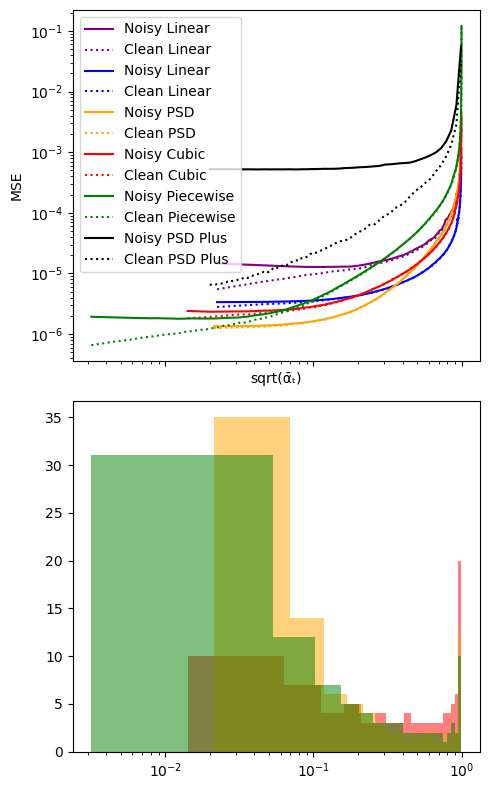

In [11]:
import numpy as np

fig, ax = plt.subplots(2, sharex=True, figsize=(5,8))

alphas_linear = torch.ravel(model_linear.sqrtOneMinusAlphasCumprod)
alphas_psd = torch.ravel(model_psd.sqrtOneMinusAlphasCumprod)
alphas_cubic = torch.ravel(model_cubic.sqrtOneMinusAlphasCumprod)
alphas_quadratic = torch.ravel(model_quadratic.sqrtOneMinusAlphasCumprod)
alphas_piecewise = torch.ravel(model_piecewise.sqrtOneMinusAlphasCumprod)
alphas_psd_plus = torch.ravel(model_psd_plus.sqrtOneMinusAlphasCumprod)


# Main plots

ax[0].plot(alphas_linear.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_linear_0][::-1], label="Noisy Linear", color='purple')
ax[0].plot(alphas_linear.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_linear_0][::-1], label="Clean Linear", color='purple', linestyle='dotted')

ax[0].plot(alphas_linear.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_linear][::-1], label="Noisy Linear", color='blue')
ax[0].plot(alphas_linear.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_linear][::-1], label="Clean Linear", color='blue', linestyle='dotted')

ax[0].plot(alphas_psd.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_psd][::-1], label="Noisy PSD", color='orange')
ax[0].plot(alphas_psd.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_psd][::-1], label="Clean PSD", color='orange', linestyle='dotted')

ax[0].plot(alphas_cubic.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_cubic][::-1], label="Noisy Cubic", color='red')
ax[0].plot(alphas_cubic.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_cubic][::-1], label="Clean Cubic", color='red', linestyle='dotted')

#ax[0].plot(alphas_quadratic.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_quadratic][::-1], label="Noisy Quadratic", color='green')
#ax[0].plot(alphas_quadratic.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_quadratic][::-1], label="Clean Quadratic", color='green', linestyle='dotted')

ax[0].plot(alphas_piecewise.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_piecewise][::-1], label="Noisy Piecewise", color='green')
ax[0].plot(alphas_piecewise.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_piecewise][::-1], label="Clean Piecewise", color='green', linestyle='dotted')

ax[0].plot(alphas_psd_plus.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_psd_plus][::-1], label="Noisy PSD Plus", color='black')
ax[0].plot(alphas_psd_plus.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean_psd_plus][::-1], label="Clean PSD Plus", color='black', linestyle='dotted')

# Print minimum MSEs
#print(torch.min(torch.tensor([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean])))
#print(torch.min(torch.tensor([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates])))

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_xlabel("sqrt(ᾱₜ)")
ax[0].set_ylabel("MSE")
ax[0].legend()
"""
# Create secondary x-axis on top
ax2 = ax.twiny()

# Align with the same x limits
ax2.set_xlim(ax.get_xlim())

# Define ticks for the new axis
ticks = np.linspace(0, len(alphas)-1, 10, dtype=int)  # 10 evenly spaced ticks
ax2.set_xticks(alphas.cpu()[ticks])                    # position them using alphas
ax2.set_xticklabels([str(i) for i in range(1, 101, 11)])  # label them 1–100 range

ax2.set_xlabel("Diffusion Step (t)")
"""

ax[1].hist(alphas_cubic.cpu(), alpha=0.5, color='red', bins=20)
ax[1].hist(alphas_psd.cpu(), alpha=0.5, color='orange', bins=20)
ax[1].hist(alphas_piecewise.cpu(), alpha=0.5, color='green', bins=20)


plt.tight_layout()
plt.show()


In [22]:
def piecewise_log_beta_schedule(timesteps):
    nb_low_points = int(0.7*timesteps)
    nb_high_points = timesteps - nb_low_points
    return torch.concatenate((torch.linspace(10**(-3.5), 10**(-3.4), nb_low_points), torch.logspace(-3.4, -0.2, nb_high_points)))

[2.85258961e-05 8.19513438e-05 2.35435995e-04 6.76378268e-04
 1.94315045e-03 5.58242904e-03 1.60376228e-02 4.60740912e-02
 1.32365121e-01 3.80268493e-01]
[1.00000000e-04 2.64376119e-04 6.98947325e-04 1.84784981e-03
 4.88527363e-03 1.29154968e-02 3.41454894e-02 9.02725197e-02
 2.38658985e-01 6.30957362e-01]


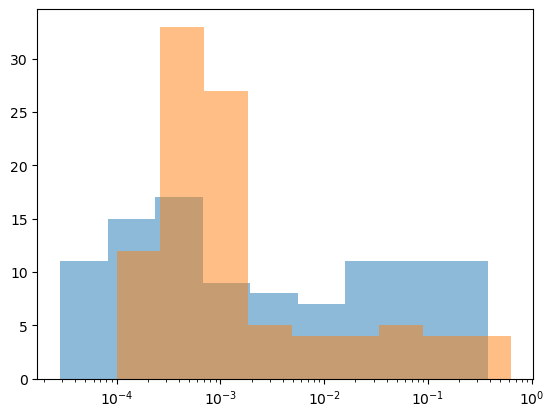

In [12]:
from src.diffusion_utils import psd_beta_schedule, cosine_beta_schedule, cubic_beta_schedule
import numpy as np

data = psd_beta_schedule(100)
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 10)
print(bins)
plt.hist(data, bins=bins, alpha=0.5)
plt.xscale('log')

data = piecewise_log_beta_schedule(100)
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 10)
print(bins)
plt.hist(data, bins=bins, alpha=0.5)
plt.xscale('log')

/tmp/ipykernel_4167400/744477193.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  betas = torch.tensor(betas).unsqueeze(1).unsqueeze(2).unsqueeze(3)


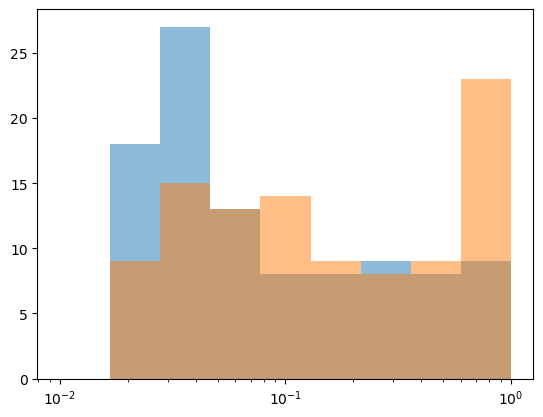

In [52]:
import torch.nn.functional as F

alphas_psd = model_psd.sqrtOneMinusAlphasCumprod.ravel()

#data = piecewise_log_beta_schedule(100)
betas = betas_from_sqrtOneMinusAlphasCumprod(torch.concatenate((torch.logspace(-1.7, -1.3, 50), torch.logspace(-1.3, 0, 50))))
betas = torch.tensor(betas).unsqueeze(1).unsqueeze(2).unsqueeze(3)
alphas = 1.0 - betas
alphasCumprod = torch.cumprod(alphas, axis=0)
alphasCumprodPrev = F.pad(alphasCumprod[:-1], (0,0,0,0,0,0,1,0), value=1.0)
sqrtRecipAlphas = torch.sqrt(1.0 / alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrtAlphasCumprod = torch.sqrt(alphasCumprod)
sqrtOneMinusAlphasCumprod = torch.sqrt(1. - alphasCumprod)

bins = np.logspace(-2, 0, 10)

plt.hist(sqrtOneMinusAlphasCumprod.ravel(), bins=bins, alpha=0.5)
plt.hist(alphas_psd.cpu(), bins=bins, alpha=0.5)
#plt.hist(alphas_linear.cpu(), bins=bins, alpha=0.5)
plt.xscale('log')

In [ ]:
print()

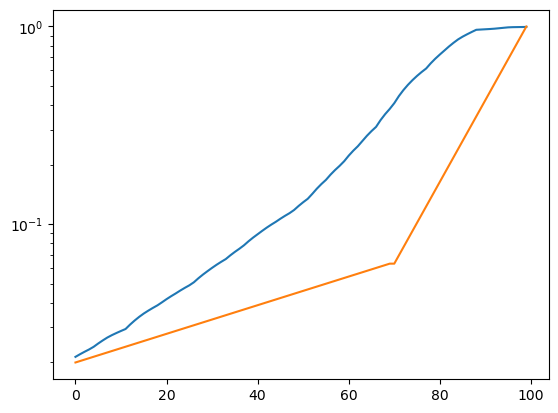

In [38]:
#plt.plot(sqrtOneMinusAlphasCumprod.ravel())
plt.plot(alphas_psd.cpu())
plt.plot(torch.concatenate((torch.logspace(-1.7, -1.2, 70), torch.logspace(-1.2, 0, 30))))
plt.yscale('log')

In [50]:
betas = betas_from_sqrtOneMinusAlphasCumprod(torch.concatenate((torch.logspace(-1.7, -1, 70), torch.logspace(-1, 0, 30))))

In [51]:
print(betas)

tensor([3.9810e-04, 1.9073e-05, 1.9908e-05, 2.0921e-05, 2.1935e-05, 2.2948e-05,
        2.4021e-05, 2.5213e-05, 2.6405e-05, 2.7657e-05, 2.9027e-05, 3.0339e-05,
        3.1829e-05, 3.3379e-05, 3.4928e-05, 3.6657e-05, 3.8385e-05, 4.0293e-05,
        4.2200e-05, 4.4227e-05, 4.6313e-05, 4.8518e-05, 5.0843e-05, 5.3287e-05,
        5.5790e-05, 5.8532e-05, 6.1274e-05, 6.4194e-05, 6.7353e-05, 7.0572e-05,
        7.3910e-05, 7.7426e-05, 8.1182e-05, 8.5056e-05, 8.9169e-05, 9.3400e-05,
        9.7871e-05, 1.0258e-04, 1.0753e-04, 1.1259e-04, 1.1808e-04, 1.2368e-04,
        1.2964e-04, 1.3584e-04, 1.4234e-04, 1.4925e-04, 1.5640e-04, 1.6385e-04,
        1.7166e-04, 1.8001e-04, 1.8859e-04, 1.9771e-04, 2.0713e-04, 2.1714e-04,
        2.2757e-04, 2.3848e-04, 2.4998e-04, 2.6202e-04, 2.7454e-04, 2.8783e-04,
        3.0166e-04, 3.1620e-04, 3.3140e-04, 3.4738e-04, 3.6407e-04, 3.8171e-04,
        4.0007e-04, 4.1938e-04, 4.3958e-04, 4.6086e-04, 1.0000e-08, 1.7384e-03,
        2.0411e-03, 2.3974e-03, 2.8167e-

In [49]:
import torch
import torch.nn.functional as F

def betas_from_sqrtOneMinusAlphasCumprod(sqrtOneMinusAlphasCumprod: torch.Tensor) -> torch.Tensor:
    """
    Given sqrtOneMinusAlphasCumprod (shape [T] or [T, 1, 1, 1]), reconstructs a stable betas schedule.
    Ensures betas ∈ (0, 0.99].
    """
    # Flatten
    sqrtOneMinusAlphasCumprod = sqrtOneMinusAlphasCumprod.flatten().float()

    # 1. Compute alphas_cumprod
    alphas_cumprod = 1.0 - sqrtOneMinusAlphasCumprod ** 2  # shape [T]

    # Numerical safety
    alphas_cumprod = torch.clamp(alphas_cumprod, min=1e-8, max=1.0)

    # 2. Compute alphas from ratio
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    alphas = alphas_cumprod / alphas_cumprod_prev
    alphas = torch.clamp(alphas, min=1e-8, max=1.0)

    # 3. Compute betas
    betas = 1.0 - alphas

    # 4. Clamp betas for stability
    betas = torch.clamp(betas, min=1e-8, max=0.99)

    return betas


In [27]:
model_log.sqrtPosteriorVariance.ravel(), model_log.betas.ravel()[-2:], model_log.sqrtRecipAlphas.ravel()

(tensor([0.0000, 0.0023, 0.0028, 0.0032, 0.0035, 0.0037, 0.0040, 0.0043, 0.0046,
         0.0049, 0.0052, 0.0055, 0.0059, 0.0063, 0.0066, 0.0071, 0.0075, 0.0079,
         0.0084, 0.0089, 0.0095, 0.0101, 0.0107, 0.0113, 0.0120, 0.0127, 0.0135,
         0.0143, 0.0152, 0.0161, 0.0170, 0.0181, 0.0192, 0.0203, 0.0215, 0.0228,
         0.0242, 0.0256, 0.0272, 0.0288, 0.0305, 0.0324, 0.0343, 0.0364, 0.0385,
         0.0408, 0.0433, 0.0459, 0.0486, 0.0516, 0.0547, 0.0579, 0.0614, 0.0651,
         0.0690, 0.0731, 0.0775, 0.0822, 0.0871, 0.0924, 0.0979, 0.1038, 0.1101,
         0.1167, 0.1238, 0.1312, 0.1392, 0.1476, 0.1565, 0.1660, 0.1761, 0.1868,
         0.1982, 0.2103, 0.2232, 0.2369, 0.2515, 0.2670, 0.2835, 0.3010, 0.3198,
         0.3397, 0.3609, 0.3836, 0.4077, 0.4333, 0.4606, 0.4897, 0.5205, 0.5532,
         0.5878, 0.6244, 0.6631, 0.7038, 0.7467, 0.7920, 0.8397, 0.8901, 0.9435,
         1.0000], device='cuda:0'),
 tensor([0.8902, 1.0000], device='cuda:0'),
 tensor([1.0000, 1.0000, 1.00

As one can see, the Linear schedule puts too much emphasis on high noise levels, thus leading to a better performance at those frequencies but tends to under perform in high noise-levels, thus leading to a poor score. One can conclude that it is not needed to perform as well on high noise levels in order to perform well in lower noise levels, i.e.

tensor(1.2339e-06)
tensor(1.2994e-06)


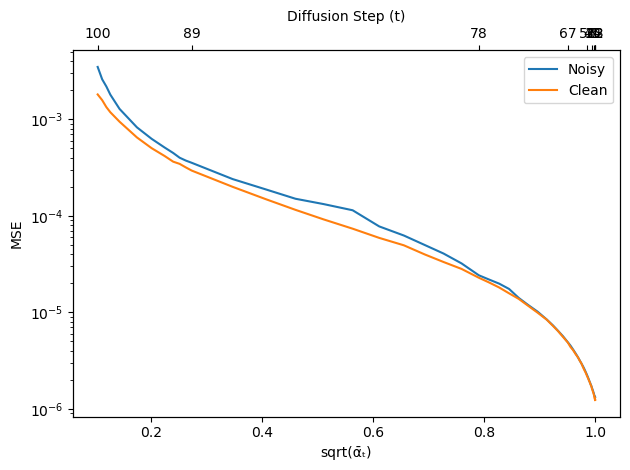

In [15]:
import numpy as np

alphas = torch.ravel(model.sqrtAlphasCumprod)

fig, ax = plt.subplots()

# Main plots
ax.plot(alphas.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates][::-1], label="Noisy")
ax.plot(alphas.cpu(), [torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean][::-1], label="Clean")

# Print minimum MSEs
print(torch.min(torch.tensor([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean])))
print(torch.min(torch.tensor([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates])))

ax.set_yscale('log')
ax.set_xlabel("sqrt(ᾱₜ)")
ax.set_ylabel("MSE")
ax.legend()

# Create secondary x-axis on top
ax2 = ax.twiny()

# Align with the same x limits
ax2.set_xlim(ax.get_xlim())

# Define ticks for the new axis
ticks = np.linspace(0, len(alphas)-1, 10, dtype=int)  # 10 evenly spaced ticks
ax2.set_xticks(alphas.cpu()[ticks])                    # position them using alphas
ax2.set_xticklabels([str(i) for i in range(1, 101, 11)])  # label them 1–100 range

ax2.set_xlabel("Diffusion Step (t)")

plt.tight_layout()
plt.show()


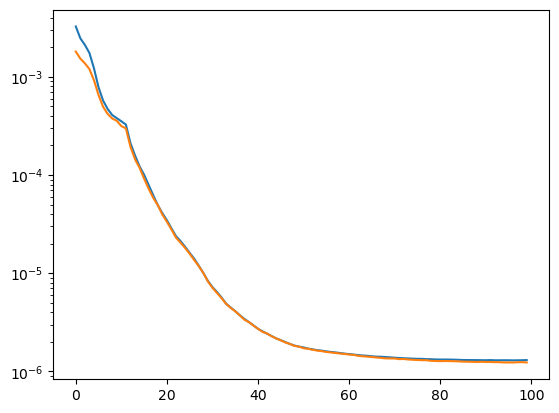

In [24]:
import numpy as np

alphas = torch.ravel(model.sqrtAlphasCumprod)

fig, ax = plt.subplots()

# Main plots
ax.plot([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates])
ax.plot([torch.mean((est.cpu() - target_frame.cpu())**2) for est in x0_estimates_clean])

ax.set_yscale('log')

In [12]:
cond = conditioning_frame

new_estimates = []

with torch.no_grad():

    for i in range(0, 98):
        d = x0_estimates[99-i-1]
        print(d.shape)

        t = torch.ones(d.shape[0]).long().to('cuda') * i
        
        dNoise = torch.randn_like(d, device=device)
        dNoisy = model.sqrtAlphasCumprod[t] * d + model.sqrtOneMinusAlphasCumprod[t] * dNoise

        noise = torch.concat((cond, dNoise), dim=1)
        dNoisy = torch.concat((cond, dNoisy), dim=1)

        # noise prediction with network
        predictedNoise = model.unet(dNoisy, t)[:, cond.shape[1]:]
        noise = noise[:, cond.shape[1]:]
        # unstack batch and sequence dimension again

        
        estimate = (dNoisy[:, cond.shape[1]:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoise)/model.sqrtAlphasCumprod[t]
        
        new_estimates.append(estimate)

    new_estimates = torch.stack(new_estimates)

torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 64, 64])
torch.Size([64, 2, 6

In [14]:
torch.mean((new_estimates - target_frame)**2)

tensor(0.0004, device='cuda:0')

In [27]:
x0_estimates.shape, target_frame.shape

(torch.Size([100, 64, 2, 64, 64]), torch.Size([64, 2, 64, 64]))

In [28]:
torch.mean((x0_estimates - target_frame)**2)

tensor(0.0005, device='cuda:0')

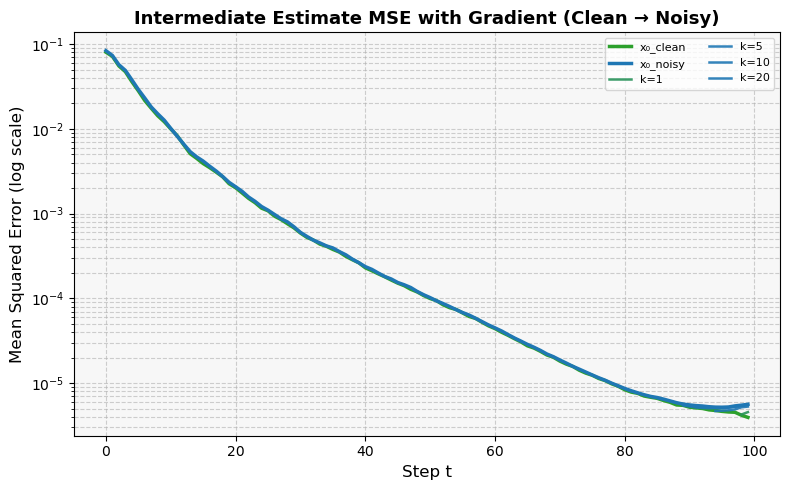

In [29]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

k_s = [1, 5, 10, 20]

# === Compute MSE arrays ===
mse_x0 = [(torch.mean((x0_estimates[t].cpu() - target_frame.cpu())**2)).item()
          for t in range(len(x0_estimates))]
mse_x0_clean = [(torch.mean((x0_estimates_clean[t].cpu() - target_frame.cpu())**2)).item()
                for t in range(len(x0_estimates))]

# === Create base plot ===
fig, ax = plt.subplots(figsize=(8, 5))

# Plot reference lines
line_clean = ax.plot(range(len(x0_estimates)), mse_x0_clean, label='x₀_clean', color='#2ca02c', linewidth=2.5)  # greenish
line_noisy = ax.plot(range(len(x0_estimates)), mse_x0, label='x₀_noisy', color='#1f77b4', linewidth=2.5)        # blueish

# === Create a nice reversed gradient from clean → noisy ===
color_start = plt.getp(line_clean[0], 'color')
color_end = plt.getp(line_noisy[0], 'color')
cmap = LinearSegmentedColormap.from_list("clean_to_noisy", [color_start, color_end], N=10)
colors = [cmap(i / (len(k_s)-1)) for i in k_s]

# === Plot intermediate estimates with gradient colors ===
for i, k in enumerate(k_s):
    est, interm_estimates = compute_estimate(model, k,
                                             conditioning_frame.cuda(),
                                             target_frame.cuda())
    mse_interm = [(torch.mean((interm_estimates[t].cpu() - target_frame.cpu())**2)).item()
                  for t in range(len(interm_estimates))]
    
    ax.plot(range(len(x0_estimates))[-(k+1):], mse_interm,
            color=colors[i], linewidth=1.8, alpha=0.9,
            label=f'k={k}')

# === Plot settings ===
ax.set_yscale('log')
ax.set_xlabel('Step t', fontsize=12)
ax.set_ylabel('Mean Squared Error (log scale)', fontsize=12)
ax.set_title('Intermediate Estimate MSE with Gradient (Clean → Noisy)', fontsize=13, weight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_facecolor('#f7f7f7')  # subtle background for contrast

plt.tight_layout()
plt.show()


In [8]:
model = model_psd

In [9]:
model.eval()

statistics_eval_mode = {}

targets = []
conditions = []
estimates = []
estimates_clean = []

n_samples = 2

predictions = []

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        for i in range(n_samples):

            data = sample["data"].to(device)
            conditioning_frame = data[:, 0]
            target_frame = data[:, 1]
            
            pred_sample, x0_estimates = model(conditioning_frame, return_x0_estimate = True)
            _, x0_estimates_clean = model(conditioning_frame, data=target_frame, return_x0_estimate = True, with_clean_input=True)

            #conditions.append(conditioning_frame.to('cpu'))
            #targets.append(target_frame.to('cpu'))
            #estimates.append(x0_estimates.to('cpu'))
            #estimates_clean.append(x0_estimates_clean.to('cpu'))

            predictions.append(pred_sample)


        if batch_idx == 0: break

pred = torch.stack(predictions)

/tmp/ipykernel_3955497/686986183.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_2nd_step = torch.tensor(data[:, 2]).to('cuda')
/tmp/ipykernel_3955497/686986183.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred_1st_step = torch.tensor(pred[0]).to('cuda')
/tmp/ipykernel_3955497/686986183.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred_1st_step_alt = torch.tensor(pred[1]).to('cuda')  # --- NEW: second diffusion prediction


torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0087e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0282e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0328e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0014e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0194e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0320e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0157e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(1.9959e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0057e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0211e-07, device='cuda:0')
torch.Size([64, 2, 64, 64]) torch.Size([64, 2, 64, 64])
tensor(2.0732e-07, devic

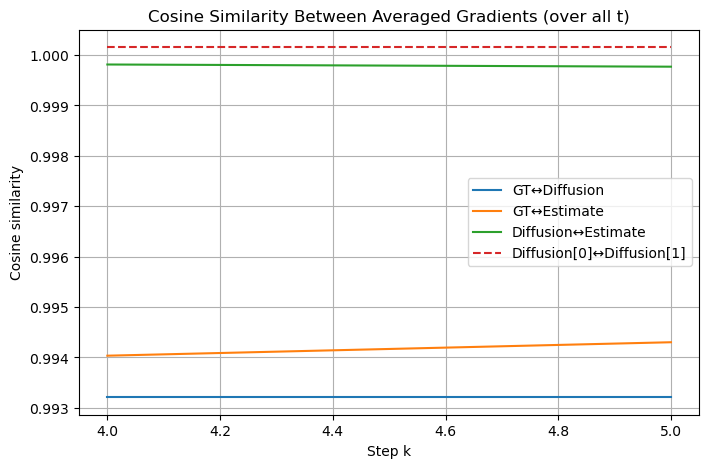

In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ddim_max_steps = 4
diffusion_steps = 100

def cosine_sim(a, b):
    return F.cosine_similarity(a, b, dim=0)

ddim_steps = range(ddim_max_steps, ddim_max_steps + 2)

# Store flattened gradients for each t,k
# Added new category: diffusion1, diffusion2
grads_per_k = {
    k: {"gt": [], "diffusion": [], "estimate": [], "diffusion_alt": []}
    for k in ddim_steps
}

for t in range(diffusion_steps):
    t_tensor = torch.tensor([t]).long().to('cuda')
    gt_2nd_step = torch.tensor(data[:, 2]).to('cuda')
    dNoise = torch.randn_like(gt_2nd_step, device=device)
    dNoisy = model.sqrtAlphasCumprod[t_tensor] * gt_2nd_step + model.sqrtOneMinusAlphasCumprod[t_tensor] * dNoise

    for k in ddim_steps:
        # --- Prepare conditions ---
        pred_1st_step = torch.tensor(pred[0]).to('cuda')
        pred_1st_step_alt = torch.tensor(pred[1]).to('cuda')  # --- NEW: second diffusion prediction

        cond_1st_step = conditioning_frame

        cond_2nd_step_gt = target_frame
        cond_2nd_step_diffusion = pred_1st_step
        cond_2nd_step_diffusion_alt = pred_1st_step_alt

        with torch.no_grad():
            estimate_pred = compute_estimate(model, k, cond_1st_step, target_frame)[0]

        print(estimate_pred.shape, pred_1st_step.shape)
        cond_2nd_step_estimate = estimate_pred
        print(torch.mean((estimate_pred - pred_1st_step)**2))

        # Build noisy inputs
        dNoisyCond_gt = torch.cat((cond_2nd_step_gt, dNoisy), dim=1)
        dNoisyCond_diffusion = torch.cat((cond_2nd_step_diffusion, dNoisy), dim=1)
        dNoisyCond_diffusion_alt = torch.cat((cond_2nd_step_diffusion_alt, dNoisy), dim=1)  # --- NEW
        dNoisyCond_estimate = torch.cat((cond_2nd_step_estimate, dNoisy), dim=1)

        dNoiseCond_gt = torch.cat((cond_2nd_step_gt, dNoise), dim=1)
        dNoiseCond_diffusion = torch.cat((cond_2nd_step_diffusion, dNoise), dim=1)
        dNoiseCond_diffusion_alt = torch.cat((cond_2nd_step_diffusion_alt, dNoise), dim=1)  # --- NEW
        dNoiseCond_estimate = torch.cat((cond_2nd_step_estimate, dNoise), dim=1)

        # Forward
        predictedNoiseCond_gt = model.unet(dNoisyCond_gt, t_tensor)
        predictedNoiseCond_diffusion = model.unet(dNoisyCond_diffusion, t_tensor)
        predictedNoiseCond_diffusion_alt = model.unet(dNoisyCond_diffusion_alt, t_tensor)  # --- NEW
        predictedNoiseCond_estimate = model.unet(dNoisyCond_estimate, t_tensor)

        # Losses
        loss_gt = F.smooth_l1_loss(predictedNoiseCond_gt[:, -2:], dNoiseCond_gt[:, -2:])
        loss_diffusion = F.smooth_l1_loss(predictedNoiseCond_diffusion[:, -2:], dNoiseCond_diffusion[:, -2:])
        loss_diffusion_alt = F.smooth_l1_loss(predictedNoiseCond_diffusion_alt[:, -2:], dNoiseCond_diffusion_alt[:, -2:])  # --- NEW
        loss_estimate = F.smooth_l1_loss(predictedNoiseCond_estimate[:, -2:], dNoiseCond_estimate[:, -2:])

        # Compute gradients
        for name, loss in zip(["gt", "diffusion", "diffusion_alt", "estimate"],
                              [loss_gt, loss_diffusion, loss_diffusion_alt, loss_estimate]):
            model.unet.zero_grad()
            loss.backward(retain_graph=True)
            grad_flat = torch.cat([
                p.grad.detach().flatten() for p in model.unet.parameters() if p.grad is not None
            ])
            grads_per_k[k][name].append(grad_flat.cpu())

# === Compute cosine similarities between average gradients over t ===
avg_cosine_per_k = torch.zeros(len(ddim_steps), 4)  # now 4 categories

for i, k in enumerate(ddim_steps):
    # Average gradients across all diffusion steps
    avg_grads = {
        name: torch.stack(grads_per_k[k][name], dim=0).mean(dim=0)
        for name in ["gt", "diffusion", "diffusion_alt", "estimate"]
    }

    # Compute cosine similarities between averaged gradients
    avg_cosine_per_k[i, 0] = cosine_sim(avg_grads["gt"], avg_grads["diffusion"])
    avg_cosine_per_k[i, 1] = cosine_sim(avg_grads["gt"], avg_grads["estimate"])
    avg_cosine_per_k[i, 2] = cosine_sim(avg_grads["diffusion"], avg_grads["estimate"])
    avg_cosine_per_k[i, 3] = cosine_sim(avg_grads["diffusion"], avg_grads["diffusion_alt"])  # --- NEW

# === Plot cosine similarity between averaged gradients per k ===
plt.figure(figsize=(8, 5))
plt.plot(ddim_steps, avg_cosine_per_k[:, 0], label='GT↔Diffusion')
plt.plot(ddim_steps, avg_cosine_per_k[:, 1], label='GT↔Estimate')
plt.plot(ddim_steps, avg_cosine_per_k[:, 2], label='Diffusion↔Estimate')
plt.plot(ddim_steps, avg_cosine_per_k[:, 3], label='Diffusion[0]↔Diffusion[1]', linestyle='--')  # --- NEW
plt.title('Cosine Similarity Between Averaged Gradients (over all t)')
plt.xlabel('Step k')
plt.ylabel('Cosine similarity')
plt.legend()
plt.grid(True)
plt.show()



=== Processing model: Linear Schedule ===

=== Processing model: PSD Schedule ===

=== Processing model: LogMinus5Uniform Schedule ===


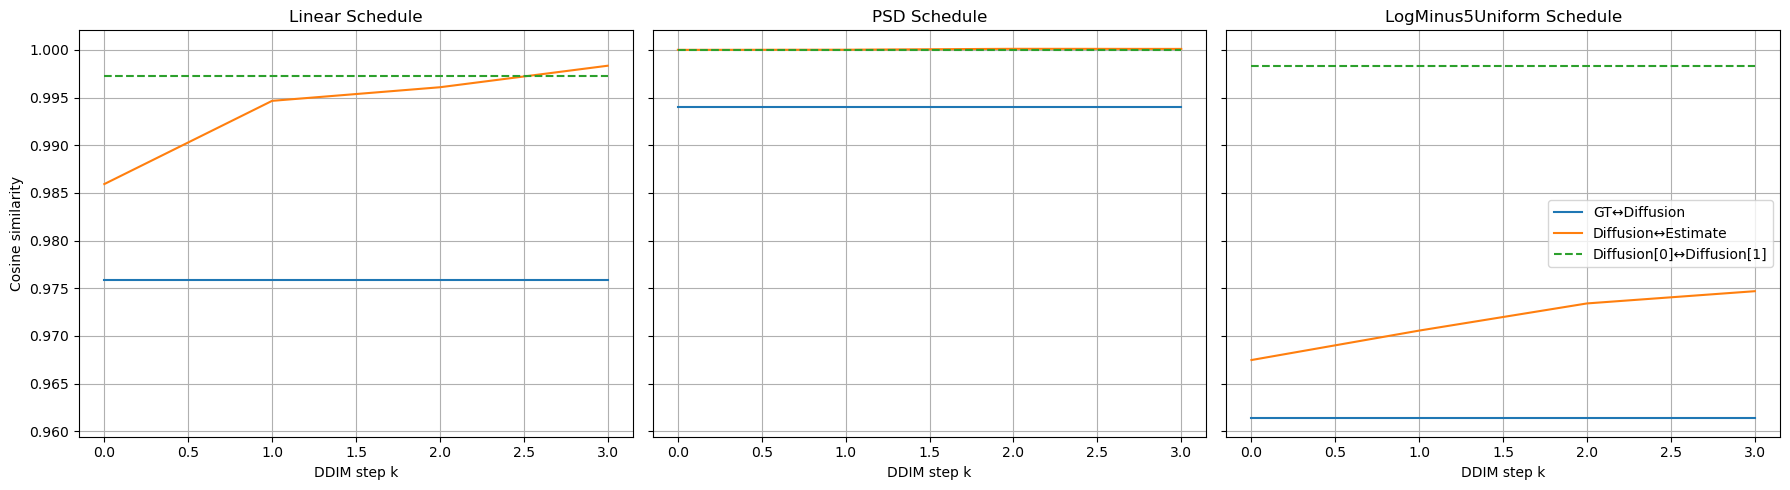

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ddim_max_steps = 0
diffusion_steps = 100
ddim_steps = range(ddim_max_steps, ddim_max_steps + 4)

def cosine_sim(a, b):
    return F.cosine_similarity(a, b, dim=0)

# results will store cosine sim curves per model
results_cosine = {m: None for m in models}

# =============================
#  LOAD EXACT SAME DATA FOR ALL MODELS
# =============================

model_eval_data = None

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        # extract one minibatch and freeze it
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        second_step_gt = data[:, 2]

        model_eval_data = (conditioning_frame, target_frame, second_step_gt)
        break  # only first batch

conditioning_frame, target_frame, gt_2nd_step = model_eval_data
gt_2nd_step = gt_2nd_step.to(device)

# we prepare the noisy input base for all models
noise = torch.randn_like(gt_2nd_step, device=device)

# ===========================================================
#  MAIN LOOP: SAME DATA → MULTIPLE MODELS
# ===========================================================
for model_name, model in models.items():
    print(f"\n=== Processing model: {model_name} ===")

    model.eval()

    # ---- generate two diffusion predictions for this model ----
    predictions = []
    with torch.no_grad():
        for _ in range(2):
            pred_sample, _ = model(conditioning_frame, return_x0_estimate=True)
            predictions.append(pred_sample.clone())

    pred_1st_step = predictions[0]
    pred_1st_step_alt = predictions[1]

    # ---- allocate gradient containers ----
    grads_per_k = {
        k: {"gt": [], "diffusion": [], "estimate": [], "diffusion_alt": []}
        for k in ddim_steps
    }

    # ===========================================================
    #  LOOP OVER ALL DIFFUSION STEPS (t from 0 to 99)
    # ===========================================================
    for t in range(diffusion_steps):
        t_tensor = torch.tensor([t]).long().to(device)

        # build noisy sample for this t
        dNoisy = model.sqrtAlphasCumprod[t_tensor] * gt_2nd_step + \
                 model.sqrtOneMinusAlphasCumprod[t_tensor] * noise

        for k in ddim_steps:

            # compute estimate(x0) for model
            with torch.no_grad():
                estimate_pred = compute_estimate(model, k, conditioning_frame, target_frame)[0]

            # conditions for second step
            cond_gt = target_frame
            cond_diff = pred_1st_step
            cond_diff_alt = pred_1st_step_alt
            cond_est = estimate_pred

            # build noisy inputs
            dNoisy_gt   = torch.cat((cond_gt,        dNoisy), dim=1)
            dNoisy_diff = torch.cat((cond_diff,      dNoisy), dim=1)
            dNoisy_alt  = torch.cat((cond_diff_alt,  dNoisy), dim=1)
            dNoisy_est  = torch.cat((cond_est,       dNoisy), dim=1)

            dNoise_gt   = torch.cat((cond_gt,        noise), dim=1)
            dNoise_diff = torch.cat((cond_diff,      noise), dim=1)
            dNoise_alt  = torch.cat((cond_diff_alt,  noise), dim=1)
            dNoise_est  = torch.cat((cond_est,       noise), dim=1)

            # forward passes
            pred_gt   = model.unet(dNoisy_gt,   t_tensor)
            pred_diff = model.unet(dNoisy_diff, t_tensor)
            pred_alt  = model.unet(dNoisy_alt,  t_tensor)
            pred_est  = model.unet(dNoisy_est,  t_tensor)

            # losses
            loss_gt   = F.smooth_l1_loss(pred_gt[:,  -2:], dNoise_gt[:,  -2:])
            loss_diff = F.smooth_l1_loss(pred_diff[:, -2:], dNoise_diff[:, -2:])
            loss_alt  = F.smooth_l1_loss(pred_alt[:,  -2:], dNoise_alt[:,  -2:])
            loss_est  = F.smooth_l1_loss(pred_est[:,  -2:], dNoise_est[:,  -2:])

            # compute gradients
            for name, loss in zip(
                ["gt", "diffusion", "diffusion_alt", "estimate"],
                [loss_gt, loss_diff, loss_alt, loss_est]
            ):
                model.unet.zero_grad()
                loss.backward(retain_graph=True)

                grad_flat = torch.cat([
                    p.grad.flatten().detach()
                    for p in model.unet.parameters()
                    if p.grad is not None
                ])

                grads_per_k[k][name].append(grad_flat.cpu())

    # ===========================================================
    #  COMPUTE MODEL-SPECIFIC COSINE SIMILARITIES
    # ===========================================================
    avg_cosine = torch.zeros(len(ddim_steps), 4)

    for i, k in enumerate(ddim_steps):
        avg_grads = {
            name: torch.stack(grads_per_k[k][name], dim=0).mean(dim=0)
            for name in ["gt", "diffusion", "diffusion_alt", "estimate"]
        }

        avg_cosine[i, 0] = cosine_sim(avg_grads["gt"],        avg_grads["diffusion"])
        avg_cosine[i, 1] = cosine_sim(avg_grads["gt"],        avg_grads["estimate"])
        avg_cosine[i, 2] = cosine_sim(avg_grads["diffusion"], avg_grads["estimate"])
        avg_cosine[i, 3] = cosine_sim(avg_grads["diffusion"], avg_grads["diffusion_alt"])

    results_cosine[model_name] = avg_cosine


# ===========================================================
#  PLOT: 1 SUBFIGURE PER MODEL
# ===========================================================



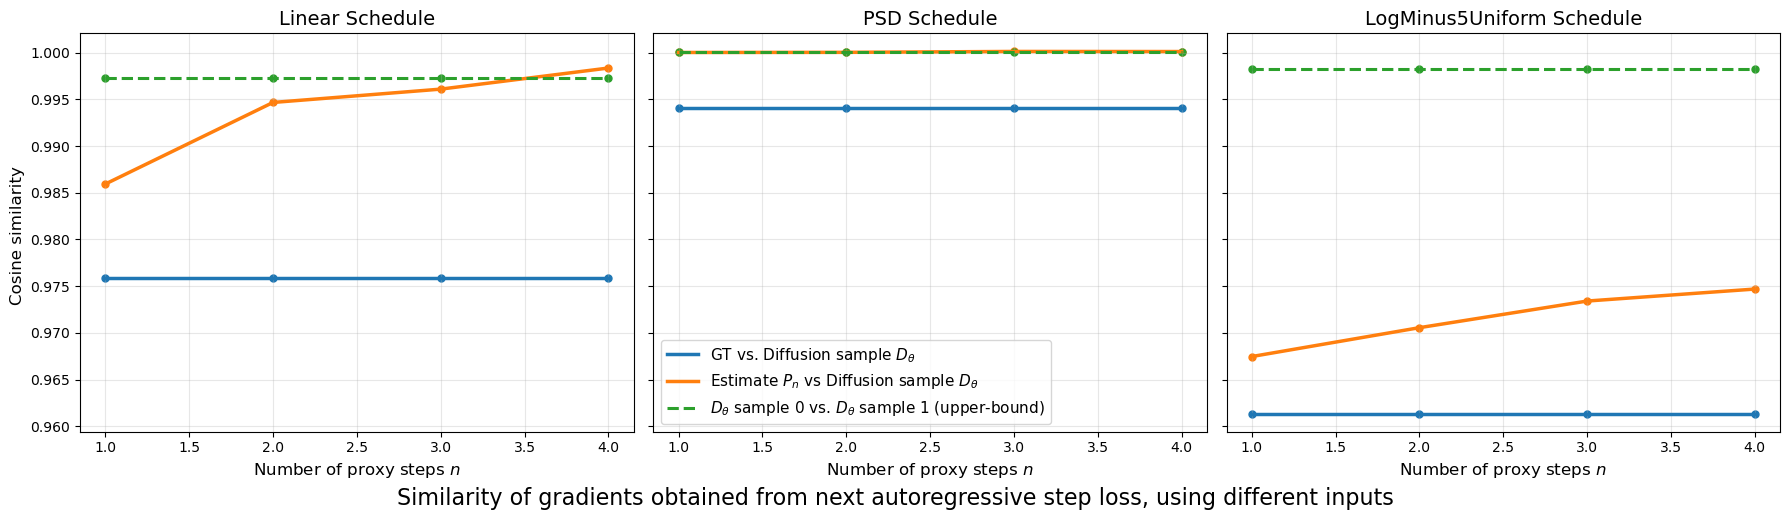

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a colormap for consistent distinct colors
cmap = plt.cm.tab10  # or "Set2", "Dark2", etc.

fig, axes = plt.subplots(
    1, 
    len(models), 
    figsize=(6*len(models), 5), 
    sharey=True
)

if len(models) == 1:
    axes = [axes]

# Optional smoothing helper
def smooth(x, window=3):
    if window <= 1:
        return x
    return np.convolve(x, np.ones(window)/window, mode='same')

for ax, (model_name, cos) in zip(axes, results_cosine.items()):
    k_list = np.array(list(ddim_steps))+1

    # Pick nice distinguishable colors
    c0 = cmap(0)
    c1 = cmap(1)
    c2 = cmap(2)
    c3 = cmap(3)

    # Plot with thicker lines + optional smoothing
    ax.plot(k_list, cos[:, 0], label=r'GT vs. Diffusion sample $D_\theta$ ',
            color=c0, linewidth=2.5)
    
    ax.plot(k_list, cos[:, 2], label=r'Estimate $P_n$ vs Diffusion sample $D_\theta$', 
            color=c1, linewidth=2.5)

    ax.plot(k_list, cos[:, 3], 
            label=r'$D_\theta$ sample 0 vs. $D_\theta$ sample 1 (upper-bound)', 
            color=c2, linestyle='--', linewidth=2.2)

    # Add markers every N points to help readability
    N = max(1, len(k_list)//12)
    ax.scatter(k_list[::N], cos[::N, 0], color=c0, s=25)
    ax.scatter(k_list[::N], cos[::N, 2], color=c1, s=25)
    ax.scatter(k_list[::N], cos[::N, 3], color=c2, s=25)

    ax.set_title(model_name, fontsize=14)
    ax.set_xlabel("Number of proxy steps $n$", fontsize=12)
    ax.grid(True, alpha=0.3)

# Shared y-label
axes[0].set_ylabel("Cosine similarity ", fontsize=12)

# Put the legend in the last axis
axes[1].legend(fontsize=11)

fig.text(0.5, -0.02, 'Similarity of gradients obtained from next autoregressive step loss, using different inputs', ha='center', fontsize=16)
plt.tight_layout()
plt.savefig('results/GradientSimilarity3Schedules.pdf', bbox_inches="tight")
plt.show()


In [ ]:
import torch

def normalize(x, mean=None, std=None, eps=1e-6):
    """
    Normalize tensor along channels.

    Args:
        x: (B, C, H, W)
        mean: optional precomputed mean (C,)
        std: optional precomputed std (C,)
    Returns:
        x_norm, mean, std
    """
    if mean is None:
        mean = x.mean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
    else:
        mean = mean.view(1, -1, 1, 1)

    if std is None:
        std = x.std(dim=(0, 2, 3), keepdim=True)    # (1, C, 1, 1)
    else:
        std = std.view(1, -1, 1, 1)

    x_norm = (x - mean) / (std + eps)
    return x_norm, mean, std


def unnormalize(x_norm, mean, std):
    """
    Undo normalization.

    Args:
        x_norm: (B, C, H, W)
        mean: (1, C, 1, 1)
        std: (1, C, 1, 1)
    Returns:
        x: (B, C, H, W)
    """
    return x_norm * std + mean


def normalize_time_wise(y: torch.Tensor, mean=None, std=None):
    """
    Normalize per time step T and per channel C,
    averaging over (B, H, W).

    Args:
        y: Tensor of shape (T, B, C, H, W)

    Returns:
        y_norm: normalized tensor (T, B, C, H, W)
        mean: tensor of shape (T, C)
        std: tensor of shape (T, C)
    """
    if mean is None and std is None:
        # Mean and std over (B, H, W)
        mean = y.mean(dim=(1, 3, 4))  # (T, C)
        std = y.std(dim=(1, 3, 4), unbiased=False)  # (T, C

    # Reshape for broadcasting
    mean_broadcast = mean[:, None, :, None, None]  # (T, 1, C, 1, 1)
    std_broadcast = std[:, None, :, None, None]    # (T, 1, C, 1, 1)

    # Normalize
    y_norm = (y - mean_broadcast) / (std_broadcast + 1e-8)

    return y_norm, mean, std

In [ ]:
x0_estimates = torch.concatenate(([est for est in estimates]), dim=1)

In [ ]:
x0_estimates_clean = torch.concatenate(([est for est in estimates_clean]), dim=1)

In [ ]:
target_frame = torch.concatenate([targ for targ in targets], dim=0)

In [ ]:
conditioning_frame = torch.concatenate([targ for targ in conditions], dim=0)

In [ ]:
x0_estimates.shape, target_frame.shape

(torch.Size([100, 100, 2, 64, 64]), torch.Size([100, 2, 64, 64]))

In [71]:
torch.mean((x0_estimates[-1] - target_frame)**2)

tensor(5.7568e-06)

tensor(2.8138e-06)
86
tensor(1.7556e-07)


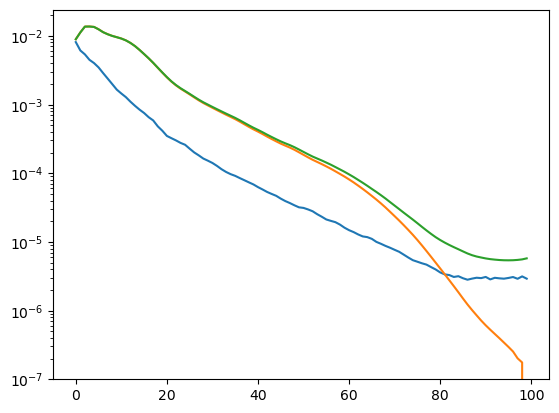

In [72]:
import numpy as np

plt.plot([torch.mean((x0_estimates_clean[t] - x0_estimates[-1])**2) for t in range(100)])
plt.plot([torch.mean((x0_estimates[t] - x0_estimates[-1])**2) for t in range(100)])
plt.plot([torch.mean((x0_estimates[t] - target_frame)**2) for t in range(100)])


plt.yscale('log')
print(min([torch.mean((x0_estimates_clean[t] - x0_estimates[-1])**2) for t in range(100)]))
print(np.argmin([torch.mean((x0_estimates_clean[t] - x0_estimates[-1])**2) for t in range(100)]))

print(torch.mean((x0_estimates[-2] - x0_estimates[-1])**2))

Why do some schedules benefit from multi-steps DDIM sampling and others not ? 

In [15]:
from src.diffusion_utils import ddim_x0_estimate
model.train()

with torch.no_grad():


    d = target_frame.to('cuda')
    dNoise = model.sqrtAlphasCumprod[94] * d + model.sqrtOneMinusAlphasCumprod[94] * torch.randn_like(d).to('cuda')

    estimate = dNoise

    

    for i in reversed(range(0,0,1)):
        print(i)
        
        t = i * torch.ones(d.shape[0]).to('cuda').long()
        
        dNoiseCond = torch.concat((conditioning_frame.to('cuda'), dNoise), dim=1)

        predictedNoiseCond = model.unet(dNoiseCond, t)

        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])
        dNoise = modelMean[:, 2:]
        #dNoise = dNoise + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoise)

        estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]
        
        print(torch.mean((estimate.to('cpu') - x0_estimates[-1])**2))
        #break

In [86]:
model.train()

with torch.no_grad():

    time = 10

    d = target_frame.to('cuda')
    dNoise = model.sqrtAlphasCumprod[time] * d + model.sqrtOneMinusAlphasCumprod[time] * torch.randn_like(d).to('cuda')

    estimate = dNoise
    
    t = time*torch.ones(d.shape[0]).to('cuda')

    dNoiseCond = torch.concat((conditioning_frame.to('cuda'), dNoise), dim=1)
    est = ddim_x0_estimate(dNoiseCond, t, model, model.unet, 5, 0)

    print(torch.mean((est.to('cpu') - x0_estimates[-1])**2))

tensor(1.8003e-06)


Greedily finding : what is the starting point that leads to the best estimate in the least number of steps ? And which steps along the way ?

In [185]:
print(torch.mean((d.to('cpu') - target_frame)**2))

tensor(0.)


In [40]:
X = x0_estimates_clean[5, :13000].unsqueeze(0)
#X = torch.concatenate((X, target_frame[:8000].unsqueeze(0).repeat(X.shape[0], 1, 1, 1, 1)), dim=2)
#X = target_frame[:28000]
y = x0_estimates[-1, :13000] - X

y, mean, std = normalize_time_wise(y)

#X = X.to('cuda')
#y = y.to('cuda')

In [41]:
X_val = x0_estimates_clean[5, 13000:].unsqueeze(0)
#X_val = target_frame[28000:]
y_val = x0_estimates[-1, 13000:] - X_val

y_val, _, _ = normalize_time_wise(y_val, mean, std)

#X_val = X_val.to('cuda')
#y_val = y_val.to('cuda')

In [42]:
X.shape, y.shape, X_val.shape, y_val.shape

(torch.Size([1, 13000, 2, 32, 32]),
 torch.Size([1, 13000, 2, 32, 32]),
 torch.Size([1, 2000, 2, 32, 32]),
 torch.Size([1, 2000, 2, 32, 32]))

In [124]:
import torch
from torch.utils.data import Dataset, DataLoader

class DiffusionDataset(Dataset):
    def __init__(self, X, y):
        """
        X: (T, B, C, H, W)
        y: (B, C, H, W)
        """
        assert X.shape[1] == y.shape[0], "Batch dimension mismatch!"
        self.X = X.permute(1, 0, 2, 3, 4).contiguous()  # -> (B, T, C, H, W)
        self.y = y.contiguous()
        self.T = X.shape[0]

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        # pick a random timestep for this sample
        t = torch.randint(0, self.T, (1,)).item()
        x_t = self.X[idx, t]  # (C, H, W)
        y_i = self.y[idx]     # (C, H, W)
        return x_t, y_i, t

# Example usage:
# X: (T,B,C,H,W), y: (B,C,H,W)
# Suppose you already have them as torch tensors

dataset = DiffusionDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=1)

val_dataset = DiffusionDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=1)


AssertionError: Batch dimension mismatch!

In [43]:
import torch
from torch.utils.data import Dataset, DataLoader

class DiffusionDataset(Dataset):
    def __init__(self, X, y):
        """
        X: (T, B, C, H, W)
        y: (T, B, C, H, W)
        """
        assert X.shape[0] == y.shape[0], "Batch dimension mismatch!"
        self.X = X
        self.y = y
        self.T = X.shape[0]

    def __len__(self):
        return self.y.shape[1]

    def __getitem__(self, idx):
        # pick a random timestep for this sample
        t = torch.randint(0, self.T, (1,)).item()
        x_t = self.X[t, idx]  # (C, H, W)
        y_i = self.y[t, idx]     # (C, H, W)
        return x_t, y_i, t

# Example usage:
# X: (T,B,C,H,W), y: (B,C,H,W)
# Suppose you already have them as torch tensors

dataset = DiffusionDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=1)

val_dataset = DiffusionDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=1)


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

def train(model, train_loader, val_loader, n_epochs=1000, lr=1e-4, device="cuda", mean=None, std=None):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    min_val_loss = 1

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        train_loss = 0.0

        for X, y, t in train_loader:
            # X: (B, T, C, H, W), y: (B, C, H, W)
            #print('a')
            X, y, t = X.to(device), y.to(device), t.to(device)
            #print('b')
            mean, std = mean.to(device), std.to(device)

            B, C, H, W = X.shape

            # choose one random timestep per batch element
            # t = torch.randint(0, T, (B,), device=device)

            # extract x_t from X (B,C,H,W)
            #x_t = X[torch.arange(B), t]

            # forward
            y_pred = model(X, t)[:, :2]

            # training loss (normalized)
            loss = criterion(y_pred, y)

            # log unnormalized loss
            unnormalized_loss = criterion(
                unnormalize(y_pred, mean, std),
                unnormalize(y, mean, std)
            )

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += unnormalized_loss.item()
            #print('c')

        avg_train_loss = train_loss / len(train_loader)

        

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, t in val_loader:
                X, y, t = X.to(device), y.to(device), t.to(device)
                B, C, H, W = X.shape
                #t = torch.randint(0, T, (B,), device=device)
                #x_t = X[torch.arange(B), t]
                y_pred = model(X, t)[:, :2]

                unnormalized_loss = criterion(
                    unnormalize(y_pred, mean, std),
                    unnormalize(y, mean, std)
                )
                val_loss += unnormalized_loss.item()

        avg_val_loss = val_loss / len(val_loader)

        min_val_loss = min(avg_val_loss, min_val_loss)

        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.8f} | Val Loss: {avg_val_loss:.8f} | Min Val Loss: {min_val_loss:.8f}")

    return model


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_normalize(model, train_loader, val_loader, n_epochs=1000, lr=1e-4, device="cuda", mean=None, std=None):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    min_val_loss = 1

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        train_loss = 0.0

        for X, y, t in train_loader:
            # X: (B, T, C, H, W), y: (B, C, H, W)
            #print('a')
            X, y, t = X.to(device), y.to(device), t.to(device)
            #print('b')
            mean, std = mean.to(device), std.to(device)

            B, C, H, W = X.shape

            # choose one random timestep per batch element
            # t = torch.randint(0, T, (B,), device=device)

            # extract x_t from X (B,C,H,W)
            #x_t = X[torch.arange(B), t]

            # forward
            y_pred = model(X, t)[:, :2]

            # training loss (normalized)
            loss = criterion(y_pred, y)

            # log unnormalized loss
            unnormalized_loss = criterion(
                y_pred, y
            )

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += unnormalized_loss.item()
            #print('c')

        avg_train_loss = train_loss / len(train_loader)

        

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, t in val_loader:
                X, y, t = X.to(device), y.to(device), t.to(device)
                B, C, H, W = X.shape
                #t = torch.randint(0, T, (B,), device=device)
                #x_t = X[torch.arange(B), t]
                y_pred = model(X, t)[:, :2]

                unnormalized_loss = criterion(
                    y_pred,
                    y
                )
                val_loss += unnormalized_loss.item()

        avg_val_loss = val_loss / len(val_loader)

        min_val_loss = min(avg_val_loss, min_val_loss)

        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.8f} | Val Loss: {avg_val_loss:.8f} | Min Val Loss: {min_val_loss:.8f}")

    return model


In [46]:
model = Unet(dim=64, channels=2, dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1)

In [47]:
train_normalize(model, dataloader, val_loader, device="cuda", mean=mean, std=std)

Epoch 1/1000 | Train Loss: 0.98179574 | Val Loss: 0.99620311 | Min Val Loss: 0.99620311
Epoch 2/1000 | Train Loss: 0.97154001 | Val Loss: 0.98773319 | Min Val Loss: 0.98773319
Epoch 3/1000 | Train Loss: 0.96812415 | Val Loss: 0.98271537 | Min Val Loss: 0.98271537
Epoch 4/1000 | Train Loss: 0.96514713 | Val Loss: 0.97879795 | Min Val Loss: 0.97879795
Epoch 5/1000 | Train Loss: 0.96384525 | Val Loss: 0.98257911 | Min Val Loss: 0.97879795
Epoch 6/1000 | Train Loss: 0.96055989 | Val Loss: 0.97656420 | Min Val Loss: 0.97656420
Epoch 7/1000 | Train Loss: 0.95775808 | Val Loss: 0.97659880 | Min Val Loss: 0.97656420


KeyboardInterrupt: 

In [134]:
with torch.no_grad():
    print(torch.mean((model(X_val[0].to('cuda'), time = 0*torch.ones(len(X_val[0])).to('cuda')) - y_val[0].to('cuda'))**2))

tensor(0.5044, device='cuda:0')


In [ ]:
train(model, dataloader, val_loader, device="cuda", mean=mean, std=std)

In [ ]:
([torch.mean((unnormalize(model(X_val[t].to('cpu'), t*torch.ones(X_val.shape[1]).to('cpu'))[:,:2], mean.to('cpu'), std.to('cpu')) + target_frame[38000:].to('cpu') - x0_estimates[-1, 38000:].to('cpu'))**2).cpu() for t in range(98,99)])

In [ ]:
([torch.mean((unnormalize(model(X[t, :2000].to('cpu'), t*torch.ones(2000).to('cpu'))[:,:2], mean.to('cpu'), std.to('cpu')) + target_frame[:2000].to('cpu') - x0_estimates[-1, :2000].to('cpu'))**2).cpu() for t in range(98,99)])

In [ ]:
torch.mean((x0_estimates[-1, 28000:] - target_frame[28000:])**2)

In [ ]:
import torch

def optimal_freqwise_mix_and_image_distances(
    x,         # (T, B, C, H, W) real or complex
    Y,         # (B, C, H, W)
    Z,         # (B, C, H, W)
    eps=1e-12,
    real=False,
    clamp01=False,
    reduction="mean",   # "mean" or "sum"
    device=None
):
    """
    Returns:
      c: (T, C, H, W) complex (or real if real=True) optimal coefficients
      distances: (T,) distance in image domain (MSE if reduction="mean", else sum of squared error)
      Zhat_img: (T, B, C, H, W) reconstructed images (real)
    """
    if device is None:
        device = x.device

    # ensure complex dtype for FFT math
    dtype = torch.complex64
    x_c = x.to(dtype) if not torch.is_complex(x) else x
    Y_c = Y.to(dtype) if not torch.is_complex(Y) else Y
    Z_c = Z.to(dtype) if not torch.is_complex(Z) else Z

    # FFT spatial dims
    F = torch.fft.fftn(x_c, dim=(-2, -1))    # (T, B, C, H, W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))   # (B, C, H, W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1)) # (B, C, H, W)

    # Broadcast FY and Zfft over time T
    FY_tb = FY.unsqueeze(0).expand(F.shape)  # (T, B, C, H, W)
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape) # (T, B, C, H, W)

    # A = F - FY, B = Z - FY (B independent of T, but expanded)
    A = F - FY_tb       # (T, B, C, H, W)
    B = Z_tb - FY_tb    # (T, B, C, H, W)

    # Numerator and denominator summed over batch only (dim=1)
    # num = sum_b A*^ B  (complex)
    num = torch.sum(A.conj() * B, dim=1)              # (T, C, H, W)
    denom = torch.sum(A.real**2 + A.imag**2, dim=1)   # (T, C, H, W)

    # solve for c (per t, c, h, w)
    if real:
        c = (num.real) / (denom + eps)                # real
        if clamp01:
            c = c.clamp(0.0, 1.0)
    else:
        c = num / (denom + eps)                       # complex

    # Reconstruct Zhat in Fourier domain:
    # c shape -> (T, 1, C, H, W) for broadcasting with F and FY_tb
    c_exp = c.unsqueeze(1)                            # (T,1,C,H,W)
    Zhat_fft = c_exp * F + (1.0 - c_exp) * FY_tb      # (T,B,C,H,W) complex

    # Inverse FFT to image domain
    # Zhat_img: (T,B,C,H,W), complex -> take real part (imag numerics)
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2, -1)).real

    # True image Z: inverse FFT of Zfft (B,C,H,W) -> real
    Z_img = torch.fft.ifftn(Zfft, dim=(-2, -1)).real   # (B,C,H,W)
    Z_img_tb = Z_img.unsqueeze(0).expand_as(Zhat_img)  # (T,B,C,H,W)

    # Squared error in image domain
    err = (Zhat_img - Z_img_tb) ** 2                   # (T,B,C,H,W)

    if reduction == "mean":
        distances = err.mean(dim=(1,2,3,4))            # (T,)
    elif reduction == "sum":
        distances = err.sum(dim=(1,2,3,4))             # (T,)
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return c, distances, Zhat_img


In [ ]:
c, distances_freq_wise, estimated_combinations = optimal_freqwise_mix_and_image_distances(x0_estimates[:-1, 38000:].to('cpu'), target_frame.to('cpu')[38000:], x0_estimates[-1, 38000:].to('cpu'))

In [ ]:
distances_freq_wise

In [ ]:
torch.mean(distances_freq_wise)

### Is there already no exposure-bias in early steps ?

Plot the error in predicting x0, with true input, and with propagated input

In [ ]:
model =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model.load_state_dict(checkpoint)

In [ ]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

In [ ]:
model.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        prediction1, x0_estimates, denoiser_inputs = model(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction1, x0_estimates_clean, denoiser_inputs_clean = model(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        if batch_idx ==3 : break

In [ ]:
model.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: break
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        prediction1 = model(conditioning_frame, data = target_frame, return_x0_estimate = False, return_denoiser_inputs = False)
        prediction2 = model(conditioning_frame, data = target_frame, return_x0_estimate = False, return_denoiser_inputs=False)

        #if batch_idx ==3 : break

In [ ]:
torch.mean((prediction1 - prediction2)**2)

In [ ]:
torch.mean((prediction1 - target_frame)**2)

In [ ]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean])
plt.yscale("log")

Can we map an error landscape to a diffusion schedule ? 

In [ ]:
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates])
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean])
plt.yscale("log")

In [ ]:
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates])
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean])
plt.yscale("log")

## Can we repeat a given noise level prediction to reduce the error ?

In [ ]:
torch.mean((x0_estimates[91] - target_frame)**2)

In [ ]:
i = 90

input = x0_estimates[90].to('cuda')
print(torch.mean((input - target_frame)**2))

for k in range(4):

    t = torch.Tensor([i]).long().to('cuda').repeat(input.shape[0])

    noise = torch.randn(input.shape).to('cuda')
    propagated_signal = model.sqrtAlphasCumprod[99-i].ravel() * input + model.sqrtOneMinusAlphasCumprod[99-i].ravel() * noise
    dNoiseCond = torch.concat((conditioning_frame, propagated_signal), dim=1)

    predictedNoiseCond = model.unet(dNoiseCond, 99-t)

    new_estimate = (dNoiseCond[:, -2:]  - model.sqrtOneMinusAlphasCumprod[99-i] * predictedNoiseCond[:, -2:])/model.sqrtAlphasCumprod[99-i]
    input = new_estimate
    print(torch.mean((new_estimate - target_frame)**2))

In [ ]:
torch.mean((denoiser_inputs[95] - target_frame)**2)

In [ ]:
torch.mean((propagated_signal-target_frame)**2)

In [ ]:
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates])/torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean]))
plt.plot(torch.ones(2))

In [ ]:
plt.plot(model.sqrtOneMinusAlphasCumprod.ravel().cpu(), torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates])/torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean]))
plt.plot((torch.ones(2)))

Does exposure bias begin with a too high error (of groundtruth prediction), which prevents the model from well propagating ? Like the errors before that don't really matter.

In [ ]:
errors = torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates[-30:]])
errors_clean = torch.Tensor([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean[-30:]])

In [ ]:
plt.plot(errors - errors_clean)

In [ ]:
denoiser_inputs.shape

In [ ]:
plt.plot([torch.mean((denoiser_inp - target_frame)**2).cpu() for denoiser_inp in denoiser_inputs[-10:]])
plt.plot([torch.mean((denoiser_inp - target_frame)**2).cpu() for denoiser_inp in denoiser_inputs_clean[-10:]])
plt.yscale("log")

In [ ]:
inputs_dirty = torch.Tensor([torch.mean((denoiser_inp - target_frame)**2).cpu() for denoiser_inp in denoiser_inputs[-50:]])
inputs_clean = torch.Tensor([torch.mean((denoiser_inp - target_frame)**2).cpu() for denoiser_inp in denoiser_inputs_clean[-50:]])

plt.plot(inputs_dirty/inputs_clean)

In [ ]:
def radial_psd(img: torch.Tensor):
    """
    Compute the radially averaged Power Spectral Density (PSD) of a 2D image.

    Args:
        img: torch.Tensor of shape (C, H, W), real-valued image

    Returns:
        freqs: torch.Tensor of shape (H//2,), frequency bins in [0, 0.5]
        psd_radial: torch.Tensor of shape (C, H//2), radial PSD per channel
    """
    C, H, W = img.shape
    assert H == W, "Only square images supported for simplicity"

    # FFT and power spectrum
    fft = torch.fft.fft2(img, dim=(-2, -1))
    psd2d = torch.abs(fft) ** 2 / (H * W)

    # Frequency grid
    fy = torch.fft.fftfreq(H, device=img.device)
    fx = torch.fft.fftfreq(W, device=img.device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    freq_radius = torch.sqrt(FX**2 + FY**2)

    # Flatten
    freq_radius = freq_radius.flatten()
    psd2d = psd2d.view(C, -1)

    # Bin edges (0..Nyquist)
    max_r = H // 2
    freqs = torch.linspace(0, 0.5, steps=max_r, device=img.device)

    psd_radial = torch.zeros((C, max_r), device=img.device)
    for i in range(max_r - 1):
        mask = (freq_radius >= freqs[i]) & (freq_radius < freqs[i+1])
        if mask.any():
            psd_radial[:, i] = psd2d[:, mask].mean(dim=1)

    return freqs, psd_radial

from src.utils import compute_radial_psd_error

In [ ]:
errors = torch.stack([torch.mean(torch.stack([radial_psd(torch.abs(e - target_frame[0]))[1].cpu().ravel() for e in est]), dim=0) for est in x0_estimates[-30:]])
errors_clean = torch.stack([torch.mean(torch.stack([radial_psd(torch.abs(e - target_frame[0]))[1].cpu().ravel() for e in est]), dim=0) for est in x0_estimates_clean[-30:]])


In [ ]:
errors[-1]

In [ ]:
errors_clean[-1]

In [ ]:

#plt.plot(compute_radial_psd_error(x0_estimates_clean[50], target_frame, num_bands=32).values(), color='blue')
#plt.plot(compute_radial_psd_error(x0_estimates_clean[70], target_frame, num_bands=32).values(), color='blue')
#plt.plot(compute_radial_psd_error(x0_estimates_clean[90], target_frame, num_bands=32).values(), color='blue')
plt.plot(compute_radial_psd_error(x0_estimates_clean[85], target_frame, num_bands=32).values(), color='blue')

plt.plot(compute_radial_psd_error(x0_estimates_clean[90], target_frame, num_bands=32).values(), color='blue')


#plt.plot(compute_radial_psd_error(x0_estimates[50], target_frame, num_bands=32).values(), color='green')
#plt.plot(compute_radial_psd_error(x0_estimates[70], target_frame, num_bands=32).values(), color='green')
#plt.plot(compute_radial_psd_error(x0_estimates[90], target_frame, num_bands=32).values(), color='green')
plt.plot(compute_radial_psd_error(x0_estimates[85], target_frame, num_bands=32).values(), color='green')

plt.plot(compute_radial_psd_error(x0_estimates[90], target_frame, num_bands=32).values(), color='green')


plt.yscale('log')

In [ ]:
plt.plot(compute_radial_psd_error(x0_estimates[50], target_frame, num_bands=32).values(), color='green')
plt.plot(compute_radial_psd_error(x0_estimates[95], target_frame, num_bands=32).values(), color='blue')
plt.plot(compute_radial_psd_error(x0_estimates[99], target_frame, num_bands=32).values(), color='red')


plt.yscale('log')

What leads to an exposure bias in Forecasting diffusion models ?

Focus on DDPM (no DDIM) : Error is the same all the way, except at a point where it starts drifting apart. Issue must be that the reconstructed image for next step is too different from the ground-truth one, while it was not the case in previous timesteps. Can we fix this issue by achieving the same error earlier, thus advancing the error by some timesteps ?

### What's different between PSD and Cubic ?

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [2]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim

device = 'cuda'

In [37]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_20/best_model.pth')
model_quad.load_state_dict(checkpoint)

<All keys matched successfully>

In [9]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [ ]:
model_quad.eval()
model_psd.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        prediction1, x0_estimates_psd, denoiser_inputs = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction1, x0_estimates_psd_clean, denoiser_inputs_clean = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction1, x0_estimates_quad, denoiser_inputs = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction1, x0_estimates_clean_quad, denoiser_inputs_clean = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        if batch_idx ==3 : break

In [ ]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean])

plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_quad])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad])
plt.yscale("log")
plt.yscale("log")

In [ ]:
plt.plot(model_psd.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])
plt.plot(model_psd.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean])

plt.plot(model_quad.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_quad])
plt.plot(model_quad.sqrtOneMinusAlphasCumprod.ravel().cpu(), [torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad])
plt.yscale("log")
plt.yscale("log")

In [ ]:
plt.hist(model_psd.sqrtOneMinusAlphasCumprod.ravel().cpu())
plt.hist(model_quad.sqrtOneMinusAlphasCumprod.ravel().cpu(), alpha=0.3)


### Doubling a timestep to reduce exposure bias ?

In [ ]:
print([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd][:10])
print([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean][:10])

In [ ]:
with torch.no_grad():

    model = model_psd
    model.eval()

    i = 0

    input = x0_estimates_psd[i].to('cuda')
    print(torch.mean((input - target_frame)**2))

    for k in range(3):

        t = torch.Tensor([i]).long().to('cuda').repeat(input.shape[0])

        noise = torch.randn(input.shape).to('cuda')
        propagated_signal = model.sqrtAlphasCumprod[99-i].ravel() * input + model.sqrtOneMinusAlphasCumprod[99-i].ravel() * noise
        dNoiseCond = torch.concat((conditioning_frame, propagated_signal), dim=1)

        predictedNoiseCond = model.unet(dNoiseCond, 99-t)

        new_estimate = (dNoiseCond[:, -2:]  - model.sqrtOneMinusAlphasCumprod[99-i] * predictedNoiseCond[:, -2:])/model.sqrtAlphasCumprod[99-i]
        input = new_estimate
        print(torch.mean((new_estimate - target_frame)**2))

In [ ]:
# conditioned reverse diffusion process



sampleStride = 1


all_x0_estimates = []

denoiser_inputs = []

cond = conditioning_frame

model = model_psd

model.eval()

dNoise = torch.randn_like(cond, device=device)
cNoise = torch.randn_like(cond, device=device)

went_back = False

with torch.no_grad():

    i = 99

    while i != -1:
        print(i)

        t = i * torch.ones(cond.shape[0], device=device).long()

        # compute conditioned part with normal forward diffusion
        condNoisy = cond

        dNoiseCond = torch.concat((condNoisy, dNoise), dim=1)

        denoiser_inputs.append(dNoise)

        predictedNoiseCond = model.unet(dNoiseCond, t)

        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])

        dNoise = modelMean[:, cond.shape[1]:modelMean.shape[1]] # discard prediction of conditioning
        
        dNoise = dNoise + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoise)

        x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]
        #print(torch.mean((x0_estimate - target_frame)**2))
        input = x0_estimate
        
        ks = 1
            
        for k in range(ks):

            noise = torch.randn(input.shape).to('cuda')
            propagated_signal = model.sqrtAlphasCumprod[t] * input + model.sqrtOneMinusAlphasCumprod[t] * noise
            dNoiseCond = torch.concat((condNoisy, propagated_signal), dim=1)

            predictedNoiseCond = model.unet(dNoiseCond, t)

            new_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]
            dNoise = model.sqrtAlphasCumprod[i] * x0_estimate + model.sqrtOneMinusAlphasCumprod[i] * noise

            x0_estimate = new_estimate
        

        i -= 1

        all_x0_estimates.append(x0_estimate)

In [ ]:
all_x0_estimates_vanilla = all_x0_estimates

In [ ]:
all_x0_estimates_doublestep = all_x0_estimates

In [ ]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in all_x0_estimates_doublestep])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean])


plt.yscale('log')

In [ ]:
min([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])

In [ ]:
min([torch.mean((est - target_frame)**2).cpu() for est in all_x0_estimates_doublestep])

### How much exposure bias is generated from a clean input at timestep $t$
We give a noisy groundtruth to a timestep t, and let the model generate from there

In [ ]:
# conditioned reverse diffusion process

sampleStride = 1


all_x0_estimates = []

denoiser_inputs = []

cond = conditioning_frame

model = model_psd

model.eval()

dNoise = torch.randn_like(cond, device=device)
cNoise = torch.randn_like(cond, device=device)

went_back = False

with torch.no_grad():

    i = 99

    with_clean_input = True

    while i != -1:

        if i == 30:
            with_clean_input = False

        t = i * torch.ones(cond.shape[0], device=device).long()

        # compute conditioned part with normal forward diffusion
        condNoisy = cond

        if with_clean_input:
            dNoise = torch.randn_like(target_frame, device=device)
            dNoise = model.sqrtAlphasCumprod[t] * target_frame + model.sqrtOneMinusAlphasCumprod[t] * dNoise

        dNoiseCond = torch.concat((condNoisy, dNoise), dim=1)

         

        denoiser_inputs.append(dNoise)

        predictedNoiseCond = model.unet(dNoiseCond, t)


        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])

        dNoise = modelMean[:, cond.shape[1]:modelMean.shape[1]] # discard prediction of conditioning
        
        dNoise = dNoise + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoise)

        x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]
        #print(torch.mean((x0_estimate - target_frame)**2))
        input = x0_estimate

        i -= 1

        all_x0_estimates.append(x0_estimate)

In [ ]:
print([torch.mean((est - target_frame)**2).cpu() for est in all_x0_estimates][67:])
print([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean][67:])

In [ ]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in all_x0_estimates])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd_clean])

plt.yscale('log')

There is a set of "useless" timesteps, where the model requires a too small error to be useful. At a given frequency, the model input error doesn't allow him to obtain a corresponding small error.

If the error required is smaller than the error the model makes, it's useless. How the 

### How much error is needed to have no exposure-bias, as a function of timestep ?

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model_diffusion_lowpass_target import DiffusionModelLowPassTarget
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim

device = 'cuda'

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [13]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_psd_lf =  DiffusionModelLowPassTarget(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_54/best_model.pth')
model_psd_lf.load_state_dict(checkpoint)

model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_20/best_model.pth')
model_quad.load_state_dict(checkpoint)

model_quad_lf =  DiffusionModelLowPassTarget(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_53/best_model.pth')
model_quad_lf.load_state_dict(checkpoint)

<All keys matched successfully>

In [39]:
model_lin =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_42/best_model.pth')
model_lin.load_state_dict(checkpoint)

<All keys matched successfully>

In [52]:
model_cub =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "cubic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_44/best_model.pth')
model_cub.load_state_dict(checkpoint)

<All keys matched successfully>

In [5]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [67]:
model_quad.eval()
model_psd.eval()
model_quad_lf.eval()
model_psd_lf.eval()
model_cub.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        #prediction1, x0_estimates_psd, denoiser_inputs = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #prediction1, x0_estimates_clean_psd, denoiser_inputs_clean = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        #_, x0_estimates_psd_lf, _ = model_psd_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #_, x0_estimates_clean_psd_lf, _ = model_psd_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        #prediction_quad_lf, x0_estimates_quad_lf, denoiser_inputs = model_quad_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #prediction_clean_quad_lf, x0_estimates_clean_quad_lf, denoiser_inputs_clean = model_quad_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_quad, x0_estimates_quad, denoiser_inputs = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_clean_quad, x0_estimates_clean_quad, denoiser_inputs_clean = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_cub, x0_estimates_cub, denoiser_inputs = model_cub(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_clean_cub, x0_estimates_clean_cub, denoiser_inputs_clean = model_cub(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_psd, x0_estimates_psd, denoiser_inputs = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_psd, x0_estimates_clean_psd, denoiser_inputs_clean = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_lin, x0_estimates_lin, denoiser_inputs = model_lin(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_lin, x0_estimates_clean_lin, denoiser_inputs_clean = model_lin(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        if batch_idx ==3 : break

tensor(1.5268e-05, device='cuda:0') tensor(6.7840e-06, device='cuda:0')


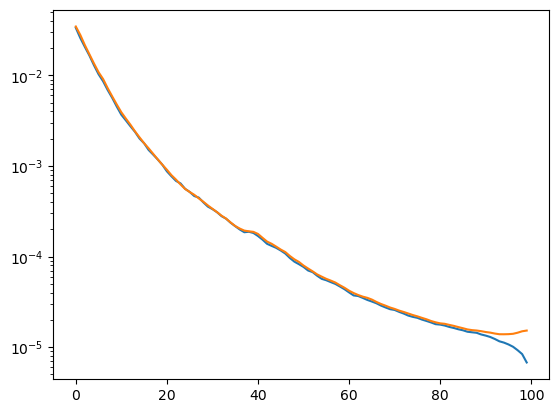

In [16]:
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad])
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad])

print(torch.mean((x0_estimates_quad[-1] - target_frame)**2), torch.mean((x0_estimates_clean_quad[-1] - target_frame)**2))

plt.yscale('log')

tensor(6.9942e-06, device='cuda:0') tensor(2.8261e-06, device='cuda:0')
tensor(6.1130e-06)


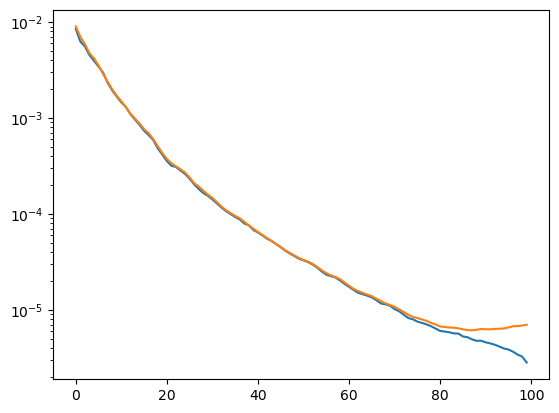

In [66]:
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_cub])
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_cub])

print(torch.mean((x0_estimates_cub[-1] - target_frame)**2), torch.mean((x0_estimates_clean_cub[-1] - target_frame)**2))
print(min([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_cub]))


plt.yscale('log')

tensor(1.3948e-05, device='cuda:0') tensor(5.1646e-06, device='cuda:0')


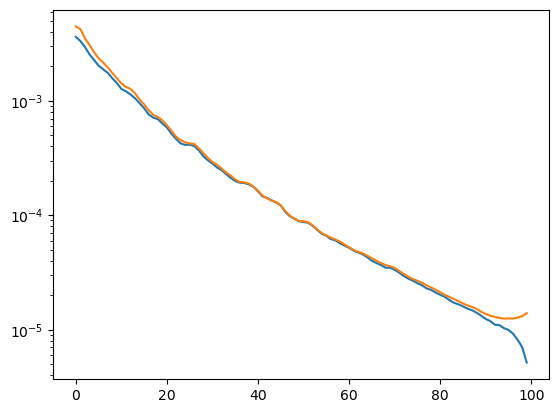

In [41]:
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_lin])
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_lin])

print(torch.mean((x0_estimates_lin[-1] - target_frame)**2), torch.mean((x0_estimates_clean_lin[-1] - target_frame)**2))

plt.yscale('log')

tensor(6.1553e-06, device='cuda:0') tensor(2.7355e-06, device='cuda:0')


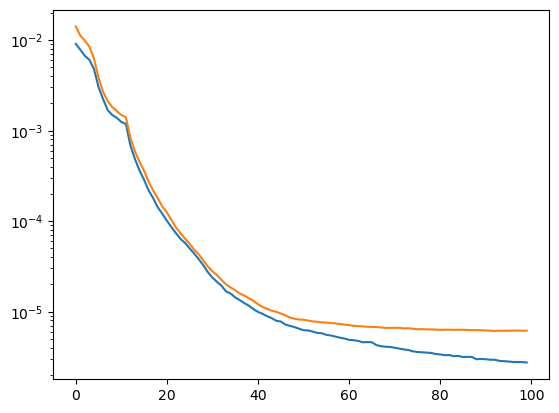

In [62]:
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_psd])
plt.plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_psd])

print(torch.mean((x0_estimates_psd[-1] - target_frame)**2), torch.mean((x0_estimates_clean_psd[-1] - target_frame)**2))

plt.yscale('log')

In [18]:
# conditioned reverse diffusion process

sampleStride = 1


all_x0_estimates = []
i_s = []
denoiser_inputs = []

cond = conditioning_frame

model = model_psd

model.eval()

dNoise = torch.randn_like(cond, device=device)
cNoise = torch.randn_like(cond, device=device)

went_back = False

with torch.no_grad():

    i = 99

    with_clean_input = True

    while i != -1:

        if i == 30:
            with_clean_input = False

        t = i * torch.ones(cond.shape[0], device=device).long()

        # compute conditioned part with normal forward diffusion
        condNoisy = cond

        if with_clean_input:
            dNoise = torch.randn_like(target_frame, device=device)
            dNoise = model.sqrtAlphasCumprod[t] * target_frame + model.sqrtOneMinusAlphasCumprod[t] * dNoise

        dNoiseCond = torch.concat((condNoisy, dNoise), dim=1)

        

        denoiser_inputs.append(dNoise)

        predictedNoiseCond = model.unet(dNoiseCond, t)


        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])

        dNoise = modelMean[:, cond.shape[1]:modelMean.shape[1]] # discard prediction of conditioning
        
        dNoise = dNoise + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoise)

        x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]
        #print(torch.mean((x0_estimate - target_frame)**2))
        input = x0_estimate

        i_s.append(i)

        i -= 1


        
        all_x0_estimates.append(x0_estimate)

### Lower resolution : is exposure bias trend same ?

In [71]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_39/best_model.pth')
model_psd.load_state_dict(checkpoint)

model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_37/best_model.pth')
model_quad.load_state_dict(checkpoint)


data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 32,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

model_quad.eval()
model_psd.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        #prediction1, x0_estimates_psd, denoiser_inputs = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #prediction1, x0_estimates_clean_psd, denoiser_inputs_clean = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        #_, x0_estimates_psd_lf, _ = model_psd_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #_, x0_estimates_clean_psd_lf, _ = model_psd_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        #prediction_quad_lf, x0_estimates_quad_lf, denoiser_inputs = model_quad_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        #prediction_clean_quad_lf, x0_estimates_clean_quad_lf, denoiser_inputs_clean = model_quad_lf(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_quad, x0_estimates_quad, denoiser_inputs = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_clean_quad, x0_estimates_clean_quad, denoiser_inputs_clean = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        prediction_psd, x0_estimates_psd, denoiser_inputs = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_psd, x0_estimates_clean_psd, denoiser_inputs_clean = model_psd(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)

        if batch_idx ==3 : break

aaaa 819
aaaa 102
aaaa 102


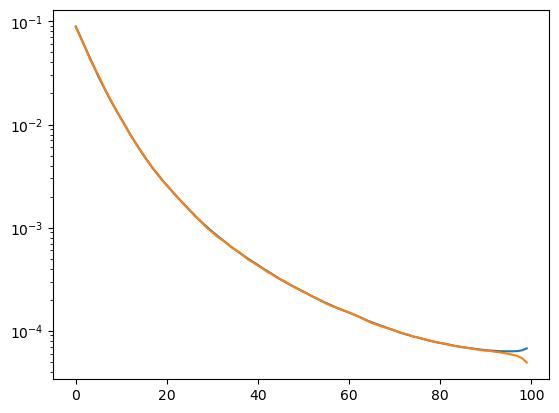

In [74]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_quad])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad])

plt.yscale('log')

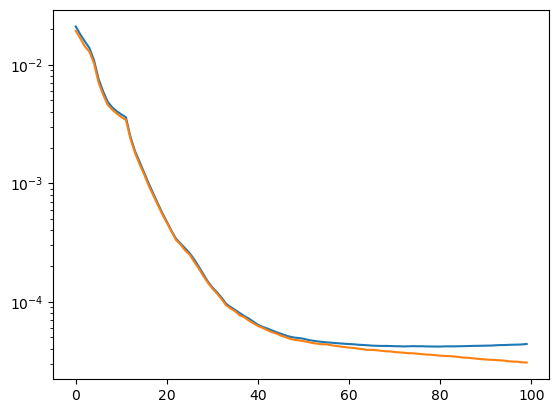

In [73]:
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])
plt.plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_psd])

plt.yscale('log')

In [ ]:
print([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_psd])

In [14]:
# conditioned reverse diffusion process

sampleStride = 1


all_x0_estimates = []

denoiser_inputs = []

cond = conditioning_frame

model = model_quad

model.eval()

with torch.no_grad():

    j = 30
    i = i_s[j]
    estimate = x0_estimates_psd[j]

    print(torch.mean((estimate - target_frame)**2))

    t = i * torch.ones(cond.shape[0], device=device).long()
    
    dNoise = torch.randn_like(target_frame, device=device)
    noisy_input = model.sqrtAlphasCumprod[t] * estimate + model.sqrtOneMinusAlphasCumprod[t] * dNoise
    clean_input = model.sqrtAlphasCumprod[t] * target_frame + model.sqrtOneMinusAlphasCumprod[t] * dNoise

    linear_factor = 0.95

    combined_estimate = linear_factor * estimate + (1-linear_factor) * target_frame
    combined_input = model.sqrtAlphasCumprod[t] * combined_estimate + model.sqrtOneMinusAlphasCumprod[t] * dNoise

    dNoiseCond = torch.concat((cond, noisy_input), dim=1)
    predictedNoiseCond = model.unet(dNoiseCond, t)
    x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

    print(torch.mean((x0_estimate - target_frame)**2))

    dNoiseCond = torch.concat((cond, clean_input), dim=1)
    predictedNoiseCond = model.unet(dNoiseCond, t)
    x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

    print(torch.mean((x0_estimate - target_frame)**2))

    dNoiseCond = torch.concat((cond, combined_input), dim=1)
    predictedNoiseCond = model.unet(dNoiseCond, t)
    x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

    print('Original error ', torch.mean((combined_estimate - target_frame)**2), 'Resulting error ', torch.mean((x0_estimate - target_frame)**2))

tensor(2.6393e-05, device='cuda:0')
tensor(0.0003, device='cuda:0')
tensor(0.0003, device='cuda:0')
Original error  tensor(2.3820e-05, device='cuda:0') Resulting error  tensor(0.0003, device='cuda:0')


Conclusion: For PSD at least, error needs to be very low to have 0 exposure bias at next step. Or maybe the MSE is not a good metric, in particular, it may depend on which frequencies are well reconstructed.

### What's the frequency error between sample estimate and train estimate looking like ?

In [77]:
from src.utils import compute_radial_psd_error

In [8]:
print(torch.mean((x0_estimates_psd[99]-target_frame)**2))

tensor(6.1273e-06, device='cuda:0')


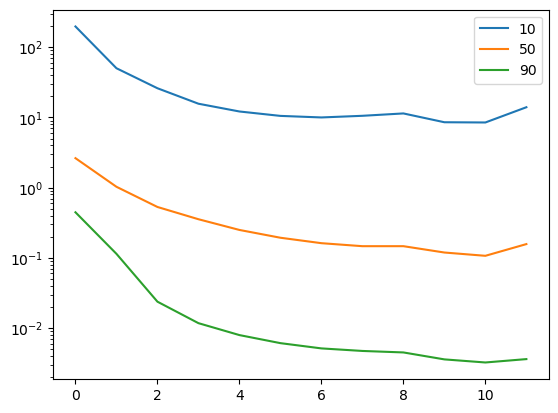

In [9]:
for i in [10, 50, 90]:
    plt.plot(compute_radial_psd_error(x0_estimates_quad[i], x0_estimates_clean_quad[i]).values(), label=i)
#plt.plot(compute_radial_psd_error(x0_estimates_psd_clean[30], target_frame).values())

plt.legend()
plt.yscale('log')

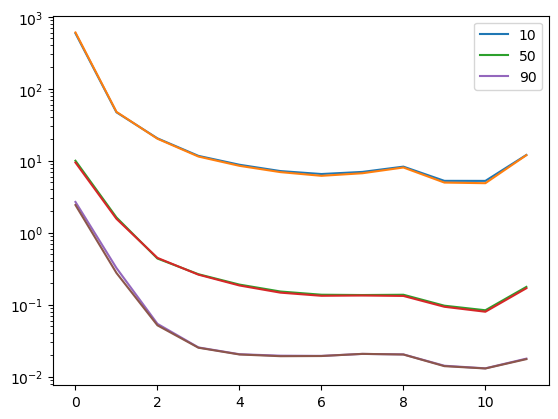

In [11]:
for i in [10, 50, 90]:
    plt.plot(compute_radial_psd_error(x0_estimates_quad[i], target_frame).values(), label=i)
    plt.plot(compute_radial_psd_error(x0_estimates_clean_quad[i], target_frame).values())

plt.legend()
plt.yscale('log')

### Is it needed to already predict high frequencies in the beginning of schedule ? Since they are anyway noised very high

What happens to performance if we change high frequencies of a signal before noising it

In [19]:
def make_freq_radius(H, W, device):
    fy = torch.fft.fftfreq(H, device=device)
    fx = torch.fft.fftfreq(W, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    return torch.sqrt(FX**2 + FY**2)

def lowpass_field(u, k_c=0.1):
    """Extract low-frequency component of a field."""
    U = torch.fft.fft2(u, dim=(-2,-1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r < k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2,-1)).real

def highpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r >= k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

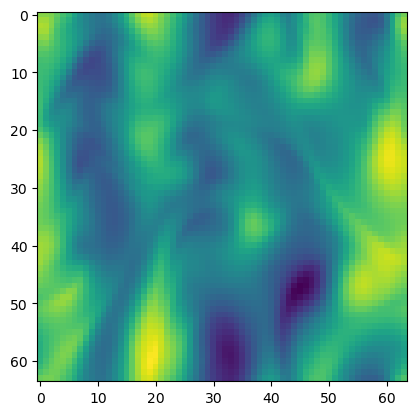

In [18]:
plt.imshow(lowpass_field(target_frame[0,0].cpu()))

In [20]:
def shuffle_batch_dim(x):
    idx = torch.randperm(x.size(0))
    x_shuffled = x[idx]
    return x_shuffled

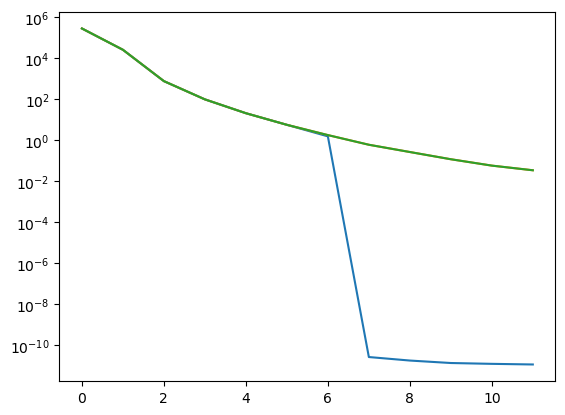

In [78]:
plt.plot(compute_radial_psd_error(lowpass_field(target_frame, k_c=0.4), torch.zeros(target_frame.shape)).values())
plt.plot(compute_radial_psd_error(target_frame, torch.zeros(target_frame.shape)).values())
plt.plot(compute_radial_psd_error(lowpass_field(target_frame, k_c=0.4) + highpass_field(shuffle_batch_dim(target_frame), k_c=0.4), torch.zeros(target_frame.shape)).values())
plt.yscale('log')

In [22]:
j_s

range(0, 99)

### For each timestep, what is minimal cutoff frequency such that low-pass filter estimate has same error as estimate itself ?

In [54]:
# conditioned reverse diffusion process

sampleStride = 1


all_x0_estimates = []

denoiser_inputs = []

cond = conditioning_frame

model = model_cub

model.eval()

j_s = range(99)

minimal_cutoffs = {}
errors = {}

with torch.no_grad():

    for j in j_s:

        for k_c in [0.4, 0.3, 0.2, 0.1, 0.05, 0.01]:

            i = i_s[j]
            estimate = x0_estimates_cub[j]

            t = i * torch.ones(cond.shape[0], device=device).long()
            
            dNoise = torch.randn_like(target_frame, device=device)
            noisy_input = model.sqrtAlphasCumprod[t] * estimate + model.sqrtOneMinusAlphasCumprod[t] * dNoise
            clean_input = model.sqrtAlphasCumprod[t] * target_frame + model.sqrtOneMinusAlphasCumprod[t] * dNoise

            lowpass_estimate = lowpass_field(estimate, k_c=k_c) + highpass_field(shuffle_batch_dim(estimate), k_c=k_c)
            combined_input = model.sqrtAlphasCumprod[t] * lowpass_estimate + model.sqrtOneMinusAlphasCumprod[t] * dNoise

            dNoiseCond = torch.concat((cond, noisy_input), dim=1)
            predictedNoiseCond = model.unet(dNoiseCond, t)
            x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

            error_estimate = torch.mean((x0_estimate - target_frame)**2)

            dNoiseCond = torch.concat((cond, combined_input), dim=1)
            predictedNoiseCond = model.unet(dNoiseCond, t)
            x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

            error_lowpass_estimate = torch.mean((x0_estimate - target_frame)**2)

            error_ratio = error_lowpass_estimate/error_estimate

            print(error_lowpass_estimate/error_estimate, error_lowpass_estimate/error_estimate < 1.001, error_estimate, error_lowpass_estimate)

            if error_ratio > 1.001:
                break
            else:
                minimal_cutoffs[j] = k_c
                errors[j] = (error_lowpass_estimate, error_estimate)

tensor(1.0003, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0081, device='cuda:0') tensor(0.0081, device='cuda:0')
tensor(0.9998, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0080, device='cuda:0') tensor(0.0080, device='cuda:0')
tensor(1.0004, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0080, device='cuda:0') tensor(0.0080, device='cuda:0')
tensor(0.9981, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0079, device='cuda:0') tensor(0.0079, device='cuda:0')
tensor(0.9815, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0082, device='cuda:0') tensor(0.0081, device='cuda:0')
tensor(1.1820, device='cuda:0') tensor(False, device='cuda:0') tensor(0.0081, device='cuda:0') tensor(0.0096, device='cuda:0')
tensor(1.0001, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0060, device='cuda:0') tensor(0.0060, device='cuda:0')
tensor(0.9999, device='cuda:0') tensor(True, device='cuda:0') tensor(0.0062, device='cuda:0') tensor(0.0062, device='

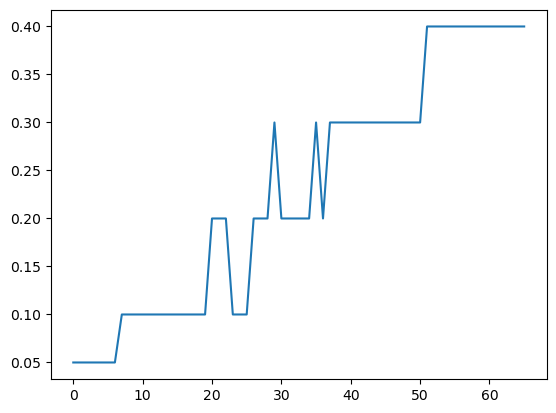

In [56]:
plt.plot(minimal_cutoffs.values())

In [57]:
errors

{0: (tensor(0.0081, device='cuda:0'), tensor(0.0082, device='cuda:0')),
 1: (tensor(0.0061, device='cuda:0'), tensor(0.0062, device='cuda:0')),
 2: (tensor(0.0053, device='cuda:0'), tensor(0.0054, device='cuda:0')),
 3: (tensor(0.0044, device='cuda:0'), tensor(0.0044, device='cuda:0')),
 4: (tensor(0.0040, device='cuda:0'), tensor(0.0040, device='cuda:0')),
 5: (tensor(0.0034, device='cuda:0'), tensor(0.0035, device='cuda:0')),
 6: (tensor(0.0028, device='cuda:0'), tensor(0.0028, device='cuda:0')),
 7: (tensor(0.0024, device='cuda:0'), tensor(0.0024, device='cuda:0')),
 8: (tensor(0.0019, device='cuda:0'), tensor(0.0019, device='cuda:0')),
 9: (tensor(0.0016, device='cuda:0'), tensor(0.0016, device='cuda:0')),
 10: (tensor(0.0014, device='cuda:0'), tensor(0.0014, device='cuda:0')),
 11: (tensor(0.0013, device='cuda:0'), tensor(0.0013, device='cuda:0')),
 12: (tensor(0.0011, device='cuda:0'), tensor(0.0011, device='cuda:0')),
 13: (tensor(0.0010, device='cuda:0'), tensor(0.0010, device=

## Now check that the error is still good after cutting-off at each step:

In [65]:
minimal_cutoffs = {0: 0.05,
                1: 0.05,
                2: 0.05,
                3: 0.05,
                4: 0.05,
                5: 0.05,
                6: 0.05,
                7: 0.1,
                8: 0.05,
                9: 0.05,
                10: 0.1,
                11: 0.1,
                12: 0.1,
                13: 0.1,
                14: 0.1,
                15: 0.1,
                16: 0.1,
                17: 0.1,
                18: 0.1,
                19: 0.1,
                20: 0.1,
                21: 0.1,
                22: 0.1,
                23: 0.2,
                24: 0.2,
                25: 0.2,
                26: 0.2,
                27: 0.2,
                28: 0.2,
                29: 0.2,
                30: 0.2,
                31: 0.2,
                32: 0.2,
                33: 0.2,
                34: 0.2,
                35: 0.2,
                36: 0.2,
                37: 0.2,
                38: 0.2,
                39: 0.2,
                40: 0.2,
                41: 0.2,
                42: 0.2,
                43: 0.2,
                44: 0.2,
                45: 0.2,
                46: 0.2,
                47: 0.2,
                48: 0.2,
                49: 0.2,
                50: 0.2,
                51: 0.2,
                52: 0.2,
                53: 0.2,
                54: 0.2,
                55: 0.2,
                56: 0.2,
                57: 0.2,
                58: 0.2,
                59: 0.2,
                60: 0.2,
                61: 0.2,
                62: 0.2,
                63: 0.2,
                64: 0.2,
                65: 0.2,
                66: 0.2,
                67: 0.2,
                68: 0.2,
                69: 0.2,
                70: 0.2,
                71: 0.2,
                72: 0.2,
                73: 0.2,
                74: 0.2,
                75: 0.2,
                76: 0.2,
                77: 0.2,
                78: 0.2,
                79: 0.2,
                80: 0.3,
                81: 0.3,
                82: 0.3,
                83: 0.3,
                84: 0.3,
                85: 0.3,
                86: 0.3,
                87: 0.3,
                88: 0.3,
                89: 0.3,
                90: 0.3,
                91: 0.3,
                92: 0.3,
                93: 0.3,
                94: 0.3,
                95: 0.3,
                96: 0.4,
                97: 0.4,
                98: 0.4,
                99: 1000}

In [28]:
dNoise = torch.randn_like(conditioning_frame, device=device)

model = model_cub

ests = []

with torch.no_grad():

    for i in reversed(range(0, 100)):
        #if i == 3 :break
        t = i * torch.ones(cond.shape[0], device=device).long()

        if i != 99 : # and i!= 0:
            hf_noise = highpass_field(model.sqrtAlphasCumprod[t] * shuffle_batch_dim(conditioning_frame) + model.sqrtOneMinusAlphasCumprod[t] * torch.randn_like(dNoise, device=device), minimal_cutoffs[98-i])
            #hf_noise = highpass_field(model.sqrtAlphasCumprod[t] * conditioning_frame + model.sqrtOneMinusAlphasCumprod[t] * torch.randn_like(dNoise, device=device), minimal_cutoffs[98-i])
            dNoise = lowpass_field(dNoise, minimal_cutoffs[98-i]) + hf_noise

        dNoiseCond = torch.concat((cond, dNoise), dim=1)

        predictedNoiseCond = model.unet(dNoiseCond, t)

        if i !=99 and i!= 0:
            predictedNoiseCond = lowpass_field(predictedNoiseCond, minimal_cutoffs[99-i]) #+ highpass_field(shuffle_batch_dim(predictedNoiseCond), minimal_cutoffs[98-i])

        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])

        dNoise = modelMean[:, cond.shape[1]:modelMean.shape[1]] # discard prediction of conditioning
        dNoise = dNoise + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoise)

        ests.append((dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t])
        
        """if return_x0_estimate:
            if self.x0_estimate_type == "mean":
                x0_estimate = 
            elif self.x0_estimate_type == "sample":-
                x0_estimate = ddim_x0_estimate(dNoiseCond, t, self, self.unet, 0, 0)
            all_x0_estimates.append(x0_estimate)"""

In [26]:
print(torch.mean((dNoise - target_frame)**2))

tensor(1.6998, device='cuda:0')


In [14]:
print(torch.mean((x0_estimates_quad[-1] - target_frame)**2))

tensor(1.4316e-05, device='cuda:0')


In [63]:
minimal_cutoffs

{0: 0.1,
 1: 0.1,
 2: 0.1,
 3: 0.1,
 4: 0.1,
 5: 0.1,
 6: 0.1,
 7: 0.1,
 8: 0.1,
 9: 0.1,
 10: 0.2,
 11: 0.1,
 12: 0.2,
 13: 0.2,
 14: 0.2,
 15: 0.2,
 16: 0.2,
 17: 0.2,
 18: 0.2,
 19: 0.2,
 20: 0.3,
 21: 0.3,
 22: 0.3,
 23: 0.3,
 24: 0.3,
 25: 0.3,
 26: 0.3,
 27: 0.3,
 28: 0.3,
 29: 0.3,
 30: 0.3,
 31: 0.3,
 32: 0.3,
 33: 0.3,
 34: 0.3,
 35: 0.3,
 36: 0.3,
 37: 0.4,
 38: 0.3,
 39: 0.4,
 40: 0.4,
 41: 0.4,
 42: 0.4,
 43: 0.4,
 44: 0.4,
 45: 0.4,
 46: 0.4,
 47: 0.4,
 48: 0.4,
 49: 0.4,
 50: 0.4,
 51: 0.4,
 52: 0.5,
 53: 0.5,
 54: 0.4,
 55: 0.4,
 56: 0.5,
 57: 0.5,
 58: 0.5,
 59: 0.5,
 60: 0.5,
 61: 0.5,
 62: 0.5,
 63: 0.5,
 64: 0.5,
 65: 0.5,
 66: 0.5,
 67: 0.5,
 68: 0.5,
 69: 0.5,
 70: 0.5,
 71: 0.5,
 72: 0.5,
 73: 0.5,
 74: 0.5,
 75: 0.5,
 76: 0.5,
 77: 0.5,
 78: 0.5,
 79: 0.5,
 80: 0.5,
 81: 0.5,
 82: 0.5,
 83: 0.5,
 84: 0.5,
 85: 0.5,
 86: 0.5,
 87: 0.5,
 88: 0.5,
 89: 0.5,
 90: 0.5,
 91: 0.5,
 92: 0.5,
 93: 0.5,
 94: 0.5,
 95: 0.5,
 96: 0.5,
 97: 0.5,
 98: 0.5}

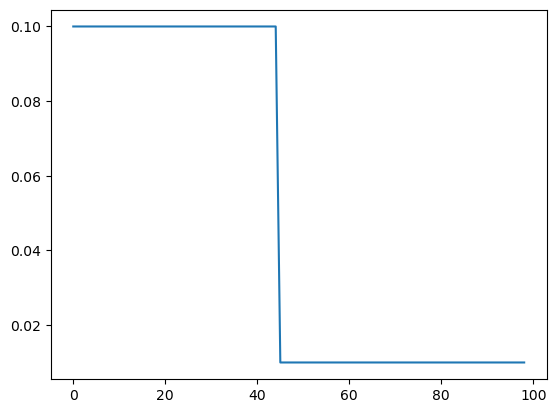

In [29]:
plt.plot(minimal_cutoffs.values())

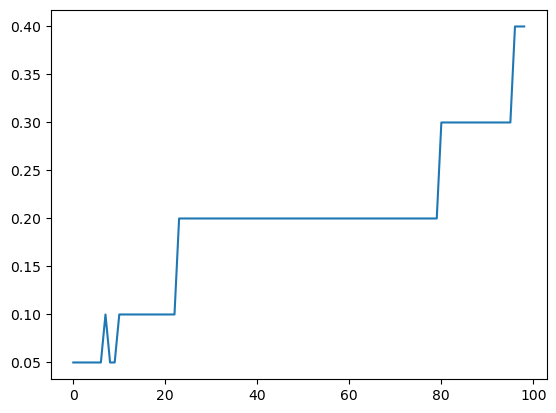

In [23]:
plt.plot(list(model_quad_lf.cutoffs.values())[:99])

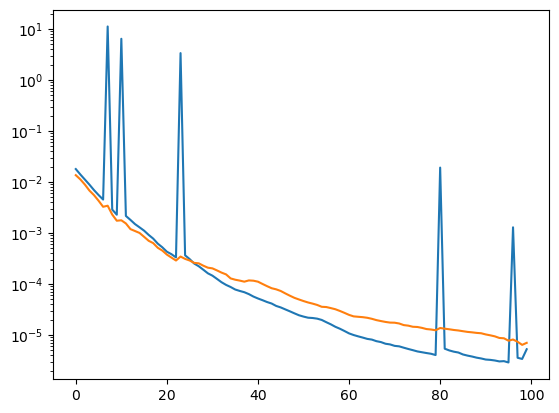

In [25]:
plt.plot([torch.mean((lowpass_field(x0_estimates_clean_quad_lf[i], model_quad_lf.cutoffs[i]) - lowpass_field(target_frame, model_quad_lf.cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad))])
#plt.plot([torch.mean((lowpass_field(x0_estimates_clean_quad_lf[i+1], minimal_cutoffs[i]) - lowpass_field(target_frame, minimal_cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])
plt.plot([torch.mean((lowpass_field(x0_estimates_clean_quad[i], model_quad_lf.cutoffs[i]) - lowpass_field(target_frame, model_quad_lf.cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad))])


plt.yscale('log')

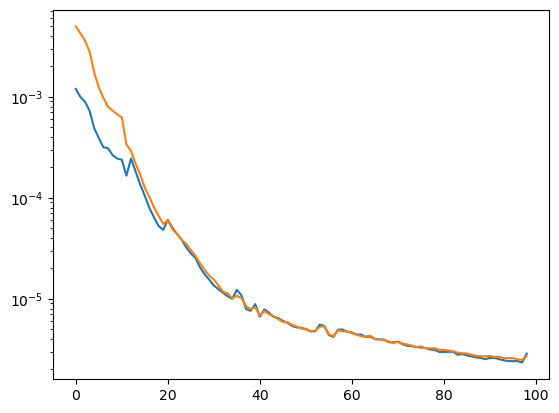

In [18]:
plt.plot([torch.mean((lowpass_field(x0_estimates_clean_psd_lf[i+1], model_psd_lf.cutoffs[i]) - lowpass_field(target_frame, model_psd_lf.cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])
#plt.plot([torch.mean((lowpass_field(x0_estimates_clean_quad_lf[i+1], minimal_cutoffs[i]) - lowpass_field(target_frame, minimal_cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])
plt.plot([torch.mean((lowpass_field(x0_estimates_clean_psd[i+1], model_psd_lf.cutoffs[i]) - lowpass_field(target_frame, model_psd_lf.cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])


plt.yscale('log')

tensor(1.6888e-05)
tensor(1.3541e-05)


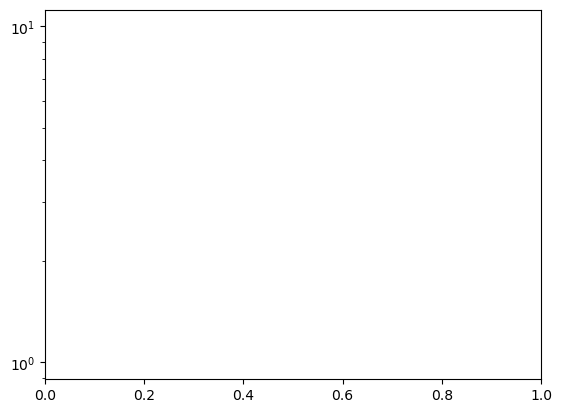

In [72]:
print(min([torch.mean((x0_estimates_quad_lf[i+1] - target_frame)**2).cpu() for i in range(len(x0_estimates_quad)-1)]))
print(min([torch.mean((x0_estimates_quad[i+1] - target_frame)**2).cpu() for i in range(len(x0_estimates_quad)-1)]))

plt.yscale('log')

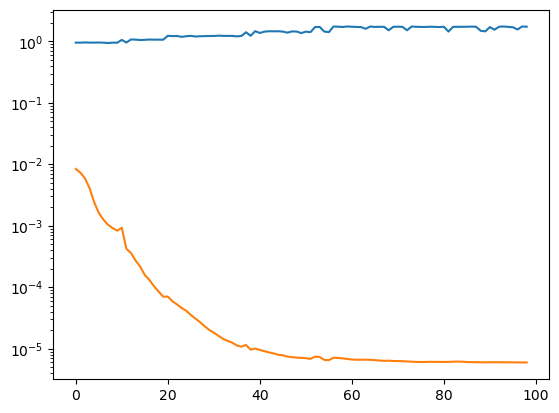

In [61]:
plt.plot([torch.mean((lowpass_field(x0_estimates_psd_lf[i+1], minimal_cutoffs[i]) - lowpass_field(target_frame, minimal_cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])
plt.plot([torch.mean((lowpass_field(x0_estimates_psd[i+1], minimal_cutoffs[i]) - lowpass_field(target_frame, minimal_cutoffs[i]))**2).cpu() for i in range(len(x0_estimates_quad)-1)])

plt.yscale('log')

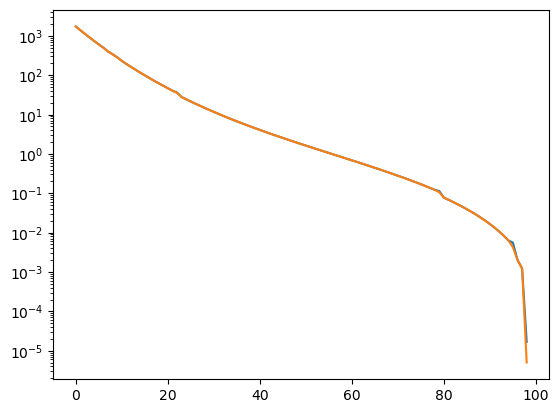

In [55]:
plt.plot([torch.mean((x0_estimates_quad_lf[i+1] - target_frame)**2).cpu() for i in range(len(x0_estimates_quad)-1)])
plt.plot([torch.mean((x0_estimates_clean_quad_lf[i+1]- target_frame)**2).cpu() for i in range(len(x0_estimates_quad)-1)])

plt.yscale('log')

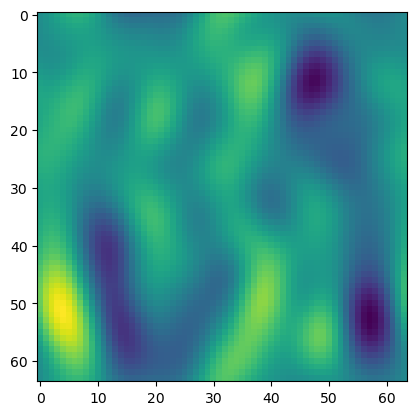

In [51]:
plt.imshow(lowpass_field(target_frame, 0.1)[0,0].cpu())

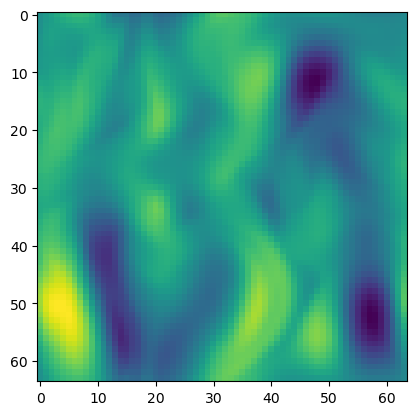

In [53]:
plt.imshow(target_frame[0,0].cpu())

In [18]:
print(torch.mean((prediction_quad_lf[-1] - target_frame)**2))

tensor(1.6756, device='cuda:0')


In [17]:
plt.plot(compute_radial_psd_error(dNoise, torch.zeros(target_frame.shape)).values())
plt.plot(compute_radial_psd_error(x0_estimates_quad[-1], torch.zeros(target_frame.shape)).values())
plt.yscale('log')

NameError: name 'compute_radial_psd_error' is not defined

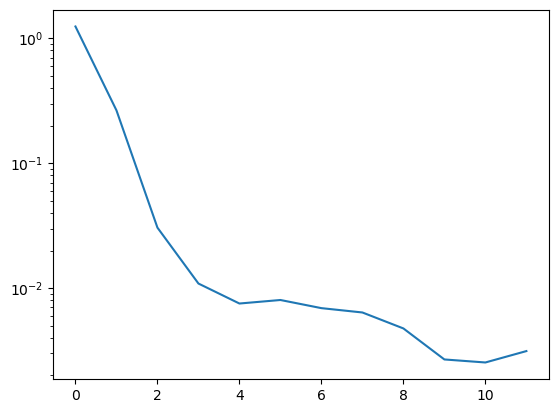

In [83]:
plt.plot(compute_radial_psd_error(dNoise, x0_estimates_quad[-1]).values())
plt.yscale('log')

In [53]:
print(torch.mean((x0_estimates_quad[-1] - target_frame)**2))

tensor(1.4985e-05, device='cuda:0')


### Results for cutting low-freq experiment

In [33]:
model_quad_lf.cutoffs

{0: 0.05,
 1: 0.05,
 2: 0.05,
 3: 0.05,
 4: 0.05,
 5: 0.05,
 6: 0.05,
 7: 0.1,
 8: 0.05,
 9: 0.05,
 10: 0.1,
 11: 0.1,
 12: 0.1,
 13: 0.1,
 14: 0.1,
 15: 0.1,
 16: 0.1,
 17: 0.1,
 18: 0.1,
 19: 0.1,
 20: 0.1,
 21: 0.1,
 22: 0.1,
 23: 0.2,
 24: 0.2,
 25: 0.2,
 26: 0.2,
 27: 0.2,
 28: 0.2,
 29: 0.2,
 30: 0.2,
 31: 0.2,
 32: 0.2,
 33: 0.2,
 34: 0.2,
 35: 0.2,
 36: 0.2,
 37: 0.2,
 38: 0.2,
 39: 0.2,
 40: 0.2,
 41: 0.2,
 42: 0.2,
 43: 0.2,
 44: 0.2,
 45: 0.2,
 46: 0.2,
 47: 0.2,
 48: 0.2,
 49: 0.2,
 50: 0.2,
 51: 0.2,
 52: 0.2,
 53: 0.2,
 54: 0.2,
 55: 0.2,
 56: 0.2,
 57: 0.2,
 58: 0.2,
 59: 0.2,
 60: 0.2,
 61: 0.2,
 62: 0.2,
 63: 0.2,
 64: 0.2,
 65: 0.2,
 66: 0.2,
 67: 0.2,
 68: 0.2,
 69: 0.2,
 70: 0.2,
 71: 0.2,
 72: 0.2,
 73: 0.2,
 74: 0.2,
 75: 0.2,
 76: 0.2,
 77: 0.2,
 78: 0.2,
 79: 0.2,
 80: 0.3,
 81: 0.3,
 82: 0.3,
 83: 0.3,
 84: 0.3,
 85: 0.3,
 86: 0.3,
 87: 0.3,
 88: 0.3,
 89: 0.3,
 90: 0.3,
 91: 0.3,
 92: 0.3,
 93: 0.3,
 94: 0.3,
 95: 0.3,
 96: 0.4,
 97: 0.4,
 98: 0.4,
 99: 1000}

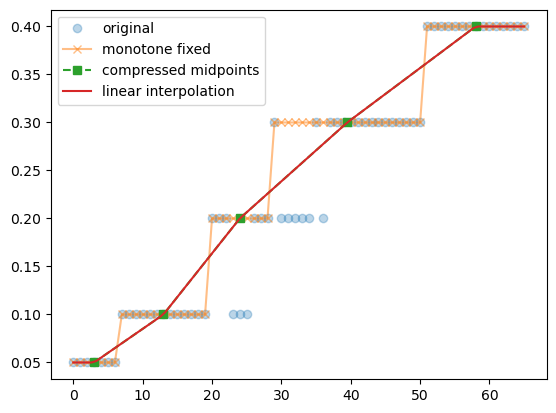

In [58]:
import numpy as np
import matplotlib.pyplot as plt

v = list(minimal_cutoffs.values())

# --- 1. enforce monotonic non-decreasing ---
monotone_v = []
current_max = v[0]
for val in v:
    if val < current_max:
        monotone_v.append(current_max)
    else:
        current_max = val
        monotone_v.append(val)

# --- 2. compress runs into midpoints ---
compressed_x = []
compressed_v = []

start = 0
for i in range(1, len(monotone_v)+1):
    if i == len(monotone_v) or monotone_v[i] != monotone_v[i-1]:
        mid = (start + (i-1)) / 2   # midpoint index
        compressed_x.append(mid)
        compressed_v.append(monotone_v[start])
        start = i

# --- 3. linear interpolator ---
f = lambda xi: np.interp(xi, compressed_x, compressed_v)

# --- test + plot ---
xi = np.linspace(0, len(monotone_v)-1, 99)
yi = f(xi)

plt.plot(range(len(v)), v, "o", alpha=0.3, label="original")
plt.plot(range(len(monotone_v)), monotone_v, "x-", alpha=0.5, label="monotone fixed")
plt.plot(compressed_x, compressed_v, "s--", label="compressed midpoints")
plt.plot(xi, yi, "-", label="linear interpolation")
plt.legend()
plt.show()


In [59]:
print(*yi, sep=',')

0.05,0.05,0.05,0.05,0.05,0.051581632653061225,0.05489795918367347,0.05821428571428572,0.06153061224489796,0.0648469387755102,0.06816326530612245,0.07147959183673469,0.07479591836734695,0.07811224489795918,0.08142857142857143,0.08474489795918366,0.08806122448979592,0.09137755102040816,0.0946938775510204,0.09801020408163266,0.10241187384044527,0.10844155844155844,0.11447124304267162,0.12050092764378478,0.12653061224489795,0.13256029684601114,0.1385899814471243,0.14461966604823748,0.15064935064935064,0.15667903525046384,0.16270871985157698,0.16873840445269017,0.17476808905380334,0.1807977736549165,0.1868274582560297,0.19285714285714284,0.19888682745825603,0.20348913759052006,0.2077682685977617,0.2120473996050033,0.2163265306122449,0.2206056616194865,0.22488479262672809,0.2291639236339697,0.23344305464121132,0.23772218564845293,0.24200131665569452,0.24628044766293614,0.25055957867017775,0.25483870967741934,0.2591178406846609,0.26339697169190257,0.2676761026991441,0.27195523370638575,0.2762

In [60]:
len(yi)

99

### Using the last noising timesteps as condition for next autoregressive step

Intuition: Since exposure bias only starts at later steps, we can approximate the propapagated signal via the noisy ground-truth for earlier steps. We just need to run a few steps, starting from the point where exposure bias starts.

In [2]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model_diffusion_lowpass_target import DiffusionModelLowPassTarget
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim

device = 'cuda'

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [2]:
model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_20/best_model.pth')
model_quad.load_state_dict(checkpoint)


model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_37/best_model.pth')
model_quad.load_state_dict(checkpoint)


model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_39/best_model.pth')
model_quad.load_state_dict(checkpoint)

model_quad =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_84/best_model.pth')
model_quad.load_state_dict(checkpoint)

<All keys matched successfully>

In [3]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 32,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [4]:
model_quad.eval()

statistics_eval_mode = {}

targets = []
estimates = []

with torch.no_grad():
    for batch_idx, sample in enumerate(train_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
       
        prediction_quad, x0_estimates_quad, denoiser_inputs = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs = True)
        prediction_clean_quad, x0_estimates_clean_quad, denoiser_inputs_clean = model_quad(conditioning_frame, data = target_frame, return_x0_estimate = True, return_denoiser_inputs=True, with_clean_input = True)
    
        if batch_idx ==3 : break

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'Denoising step t')

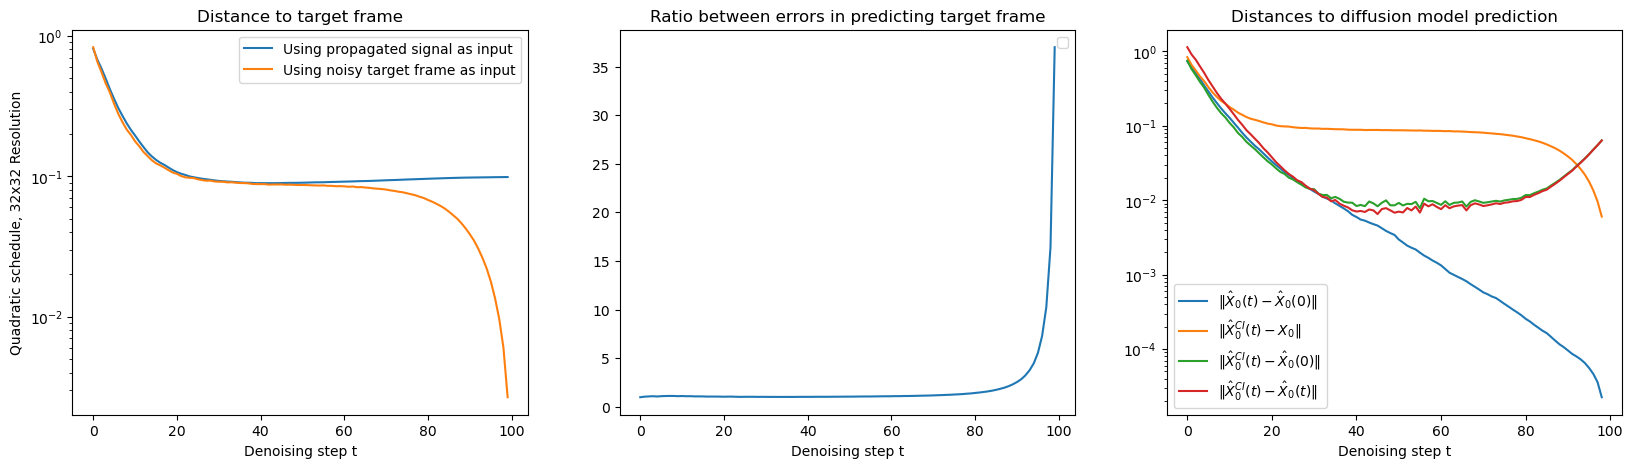

In [11]:
fig, axes = plt.subplots(1,3, figsize=(20,5))

i = 0

axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad], label="Using propagated signal as input")
axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad], label="Using noisy target frame as input")

axes[i].set_title("Distance to target frame")
axes[i].set_yscale('log')
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

axes[i].set_ylabel("Quadratic schedule, 32x32 Resolution")

i = 1

axes[i].plot(torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad])/torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad]))

axes[i].set_title("Ratio between errors in predicting target frame")
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

i = 2

axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_quad[:99]], label = r'$\| \hat{X}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - X_0 \| $')
axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((x0_estimates_clean_quad[i] - x0_estimates_quad[i])**2).cpu() for i in range(len(x0_estimates_clean_quad[:99]))], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(t) \| $')
axes[i].legend()
axes[i].set_yscale('log')
axes[i].set_title("Distances to diffusion model prediction")
axes[i].set_xlabel("Denoising step t")

- First plot shows exposure bias : One can see that 
- Second plot gives a clearer visualization of First plot: It shows that there is indeed a point where the distance between the prediction increases fastly. This point depends on diffusion schedules.
- Third plot shows that the estimate when given a noisy ground-truth as input is actually closer to the EOS diffusion prediction than the target frame, which is somehow unexpected. Furthermore, for times before the "exposure-bias" start, it shows that it gives an at-least-as-good estimation of the EOS prediction than the propagated prediction. It gives intuition that if we wanted to obtain an estimate of the EOS prediction, we could start from the "exposure bias" timestep.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'Denoising step t')

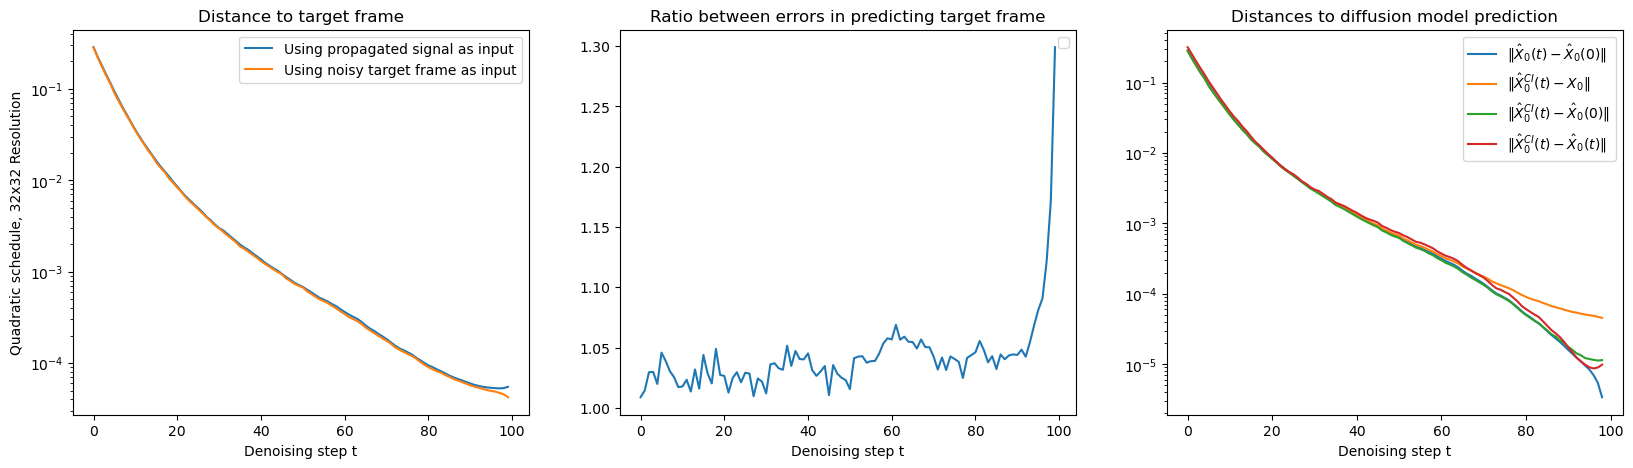

In [21]:
fig, axes = plt.subplots(1,3, figsize=(20,5))

i = 0

axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad], label="Using propagated signal as input")
axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad], label="Using noisy target frame as input")

axes[i].set_title("Distance to target frame")
axes[i].set_yscale('log')
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

axes[i].set_ylabel("Quadratic schedule, 32x32 Resolution")

i = 1

axes[i].plot(torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad])/torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad]))

axes[i].set_title("Ratio between errors in predicting target frame")
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

i = 2

axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_quad[:99]], label = r'$\| \hat{X}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - X_0 \| $')
axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((x0_estimates_clean_quad[i] - x0_estimates_quad[i])**2).cpu() for i in range(len(x0_estimates_clean_quad[:99]))], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(t) \| $')
axes[i].legend()
axes[i].set_yscale('log')
axes[i].set_title("Distances to diffusion model prediction")
axes[i].set_xlabel("Denoising step t")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'Denoising step t')

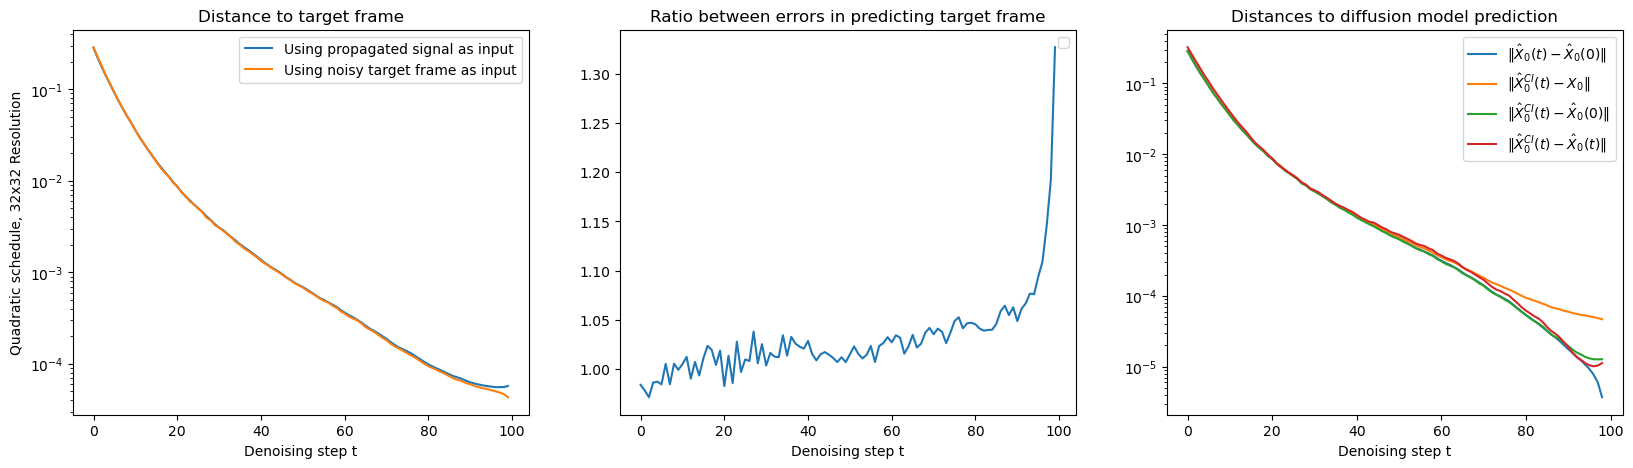

In [5]:
fig, axes = plt.subplots(1,3, figsize=(20,5))

i = 0

axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad], label="Using propagated signal as input")
axes[i].plot([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad], label="Using noisy target frame as input")

axes[i].set_title("Distance to target frame")
axes[i].set_yscale('log')
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

axes[i].set_ylabel("Quadratic schedule, 32x32 Resolution")

i = 1

axes[i].plot(torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_quad])/torch.Tensor([torch.mean((est-target_frame)**2).cpu() for est in x0_estimates_clean_quad]))

axes[i].set_title("Ratio between errors in predicting target frame")
axes[i].set_xlabel("Denoising step t")
axes[i].legend()

i = 2

axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_quad[:99]], label = r'$\| \hat{X}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((est - target_frame)**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - X_0 \| $')
axes[i].plot([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_clean_quad[:99]], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(0) \| $')
axes[i].plot([torch.mean((x0_estimates_clean_quad[i] - x0_estimates_quad[i])**2).cpu() for i in range(len(x0_estimates_clean_quad[:99]))], label = r'$\| \hat{X}^{CI}_0(t) - \hat{X}_0(t) \| $')
axes[i].legend()
axes[i].set_yscale('log')
axes[i].set_title("Distances to diffusion model prediction")
axes[i].set_xlabel("Denoising step t")

In [5]:
print(torch.mean((x0_estimates_quad[-1] - target_frame)**2))

tensor(3.5966e-05, device='cuda:0')


In [16]:
print(torch.mean((x0_estimates_quad[-1] - target_frame)**2))

tensor(7.2665e-05, device='cuda:0')


In [6]:
torch.mean(torch.Tensor([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_clean_quad[95:99]]))


tensor(1.2851e-05)

In [10]:
torch.mean(torch.Tensor([torch.mean((est - x0_estimates_quad[-1])**2).cpu() for est in x0_estimates_quad[95:99]]))


tensor(7.5650e-07)

In [11]:
print(torch.mean((x0_estimates_clean_quad[94] - x0_estimates_quad[-1])**2).cpu())
print(torch.mean((x0_estimates_clean_quad[94] - target_frame)**2).cpu())
print(torch.mean((x0_estimates_quad[-1] - target_frame)**2))

tensor(1.2068e-05)
tensor(3.2070e-05)
tensor(4.4485e-05, device='cuda:0')


In [19]:
print(torch.mean((x0_estimates_clean_quad[50] - x0_estimates_quad[-1])**2).cpu())

tensor(1.8841e-05)


In [15]:
print(torch.mean((x0_estimates_quad[50] - target_frame)**2))

tensor(4.8939e-05, device='cuda:0')


That means that until timestep 80 (more or less), the approximation we make from the propagated signal is the same as the estimation made from the noisy groundtruth prediction. It seems that this "similarity" is modulated by the exposure bias in the chain : if the exposure bias appears later, the approximation is better.

In [24]:
# conditioned reverse diffusion process

sampleStride = 1


all_x0_estimates = []

denoiser_inputs = []

cond = conditioning_frame

model = model_quad

model.eval()
with torch.no_grad():

    j = 60
    estimate = x0_estimates_quad[j]

    i = 99 - j
    t = i * torch.ones(cond.shape[0], device=device).long()

    print(torch.mean((estimate-target_frame)**2), torch.mean((x0_estimates_clean_quad[j]-target_frame)**2))
    
    dNoise = torch.randn_like(target_frame, device=device)
    noisy_input = model.sqrtAlphasCumprod[t] * estimate + model.sqrtOneMinusAlphasCumprod[t] * dNoise
    clean_input = model.sqrtAlphasCumprod[t] * target_frame + model.sqrtOneMinusAlphasCumprod[t] * dNoise

    dNoiseCond = torch.concat((cond, noisy_input), dim=1)
    predictedNoiseCond = model.unet(dNoiseCond, t)
    x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

    error_estimate = torch.mean((x0_estimate - target_frame)**2)

    dNoiseCond = torch.concat((cond, clean_input), dim=1)
    predictedNoiseCond = model.unet(dNoiseCond, t)
    x0_estimate = (dNoiseCond[:, -model.dimension:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, -model.dimension:])/model.sqrtAlphasCumprod[t]

    error_lowpass_estimate = torch.mean((x0_estimate - target_frame)**2)

    error_ratio = error_lowpass_estimate/error_estimate

    print(error_lowpass_estimate/error_estimate, error_lowpass_estimate/error_estimate < 1.001, error_estimate, error_lowpass_estimate)

tensor(4.1589e-05, device='cuda:0') tensor(4.0802e-05, device='cuda:0')
tensor(0.9850, device='cuda:0') tensor(True, device='cuda:0') tensor(4.0168e-05, device='cuda:0') tensor(3.9565e-05, device='cuda:0')


### Estimating the exposure bias of 1-step diffusion vs 2-steps diffusion

In [2]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 32,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [40, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [20]:
### Resolution 64

m_unet_1 = Unet(
            dim=32,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_32_ts_1_dim_32_framesPerTs_1_unet-periodicconv-m2_00/Model.pth")['stateDictDecoder']
#checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_unet_1.load_state_dict(checkpoint)

m_unet_1.to(device)


model_diff = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model_diff.load_state_dict(checkpoint)

<All keys matched successfully>

In [21]:
models = [m_unet_1, model_diff]

[m.eval() for m in models]

traj_length = 5

distances_all = torch.zeros((len(models), len(models)-1, traj_length))
errors = torch.zeros((len(models), traj_length))

# Cross-comparison on ground-truth trajectory

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        
        if batch_idx ==1: break

        data = sample["data"].to(device)

        preds_self_traj = torch.zeros((len(models), traj_length, data.shape[0], data.shape[2], data.shape[3], data.shape[4]))
        preds_gt_traj = torch.zeros((len(models), traj_length, data.shape[0], data.shape[2], data.shape[3], data.shape[4]))

        for i in range(len(models)):

            conditioning_frame = data[:, 0]

            traj_model = models[i]
            evaluators = [models[j] for j in range(len(models)) if j!=i]

            for t in range(traj_length):

                target = data[:, t+1]

                if isinstance(traj_model, Unet):
                    pred_traj_model = traj_model(conditioning_frame, time=None)
                else:
                    pred_traj_model = traj_model(conditioning_frame)

                preds_self_traj[i, t] = pred_traj_model
                errors[i, t] = torch.mean((pred_traj_model - target)**2)

                for j in range(len(evaluators)):
                    if isinstance(evaluators[j], Unet):
                        pred_evaluator = evaluators[j](conditioning_frame, time=None)
                    else:
                        pred_evaluator = evaluators[j](conditioning_frame)
                    distances_all[i, j, t] = torch.mean((pred_evaluator - pred_traj_model)**2)
                
                conditioning_frame = pred_traj_model

                if isinstance(traj_model, Unet):
                    preds_gt_traj[i, t] = traj_model(data[:, t], time=None)
                else: 
                    preds_gt_traj[i, t] = traj_model(data[:, t])

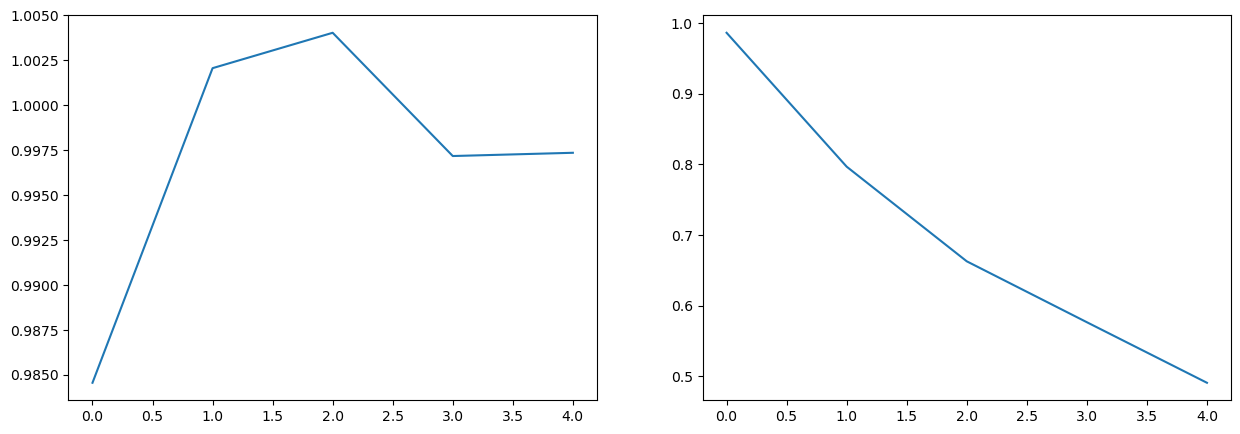

In [22]:
fig, axes = plt.subplots(1, distances_all.shape[0], figsize=(15,5))

distances_gt_traj = [[[torch.mean((preds_gt_traj[i,t] - preds_gt_traj[j, t].cpu())**2) for t in range(traj_length)] for j in range(len(models)) if j!=i] for i in range(len(models))]

for i in range(distances_all.shape[0]):
    for j in range(distances_all.shape[1]):
        axes[i].plot(distances_all[i, j] / torch.Tensor(distances_gt_traj[i][j]))

In [8]:
preds_self_traj.shape

torch.Size([2, 20, 100, 2, 64, 64])

In [23]:
distances_gt_traj_unet1 = [torch.mean((preds_self_traj[0, t].to('cuda') - data[:, t+1])**2) for t in range(traj_length)]
#distances_gt_traj_unet2 = [torch.mean((preds_self_traj[1, t].to('cuda') - data[:, t+1])**2) for t in range(traj_length)]

In [25]:
print(distances_gt_traj_unet1)

[tensor(4.0287e-05, device='cuda:0'), tensor(7.6782e-05, device='cuda:0'), tensor(0.0001, device='cuda:0'), tensor(0.0002, device='cuda:0'), tensor(0.0002, device='cuda:0')]


In [96]:
preds = []

with torch.no_grad():
    pred = data[:, 0]
    for i in range(traj_length):
        if i % 30 == 0 :
            pred = m_unet_1(pred, time=None)
        else:
            pred = m_unet_2(pred, time=None)

        preds.append(pred)

In [97]:
print([(torch.mean((preds[t]-data[:,t+1])**2)).cpu() for t in range(traj_length)])


[tensor(8.6465e-07), tensor(1.8218e-06), tensor(2.9411e-06), tensor(4.3178e-06), tensor(5.9847e-06), tensor(7.9900e-06), tensor(1.0377e-05), tensor(1.3208e-05), tensor(1.6629e-05), tensor(2.0814e-05), tensor(2.5962e-05), tensor(3.2350e-05), tensor(4.0396e-05), tensor(5.0514e-05), tensor(6.2966e-05), tensor(7.8116e-05), tensor(9.6590e-05), tensor(0.0001), tensor(0.0001), tensor(0.0002), tensor(0.0002), tensor(0.0003), tensor(0.0004), tensor(0.0005), tensor(0.0006), tensor(0.0007), tensor(0.0009), tensor(0.0011), tensor(0.0013), tensor(0.0017), tensor(0.0021), tensor(0.0027), tensor(0.0035), tensor(0.0045), tensor(0.0059)]


In [72]:
distances_gt_traj_unet2

[tensor(0.9033, device='cuda:0'),
 tensor(0.9011, device='cuda:0'),
 tensor(0.8989, device='cuda:0'),
 tensor(0.8967, device='cuda:0'),
 tensor(0.8947, device='cuda:0'),
 tensor(0.8930, device='cuda:0'),
 tensor(0.8917, device='cuda:0'),
 tensor(0.8908, device='cuda:0'),
 tensor(0.8905, device='cuda:0'),
 tensor(0.8906, device='cuda:0'),
 tensor(0.8912, device='cuda:0'),
 tensor(0.8923, device='cuda:0'),
 tensor(0.8937, device='cuda:0'),
 tensor(0.8955, device='cuda:0'),
 tensor(0.8974, device='cuda:0'),
 tensor(0.8995, device='cuda:0'),
 tensor(0.9019, device='cuda:0'),
 tensor(0.9045, device='cuda:0'),
 tensor(0.9073, device='cuda:0'),
 tensor(0.9104, device='cuda:0'),
 tensor(0.9138, device='cuda:0'),
 tensor(0.9174, device='cuda:0'),
 tensor(0.9212, device='cuda:0'),
 tensor(0.9252, device='cuda:0'),
 tensor(0.9293, device='cuda:0'),
 tensor(0.9334, device='cuda:0'),
 tensor(0.9375, device='cuda:0'),
 tensor(0.9413, device='cuda:0'),
 tensor(0.9449, device='cuda:0'),
 tensor(0.9481

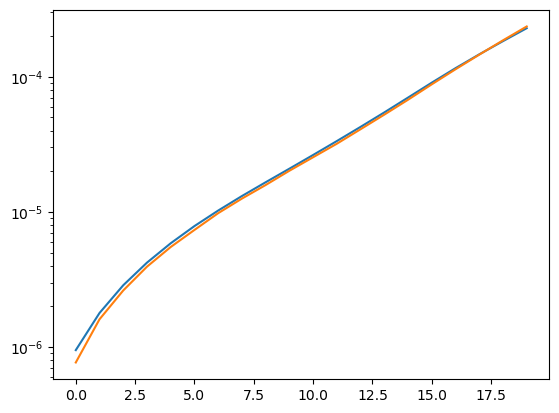

In [44]:
plt.plot(torch.Tensor(distances_gt_traj_unet2).cpu())
plt.plot([(torch.mean((preds[t]-data[:,t+1])**2)).cpu() for t in range(traj_length)])
plt.yscale('log')

In [29]:
with torch.no_grad():
    print(torch.mean((m_unet_2(m_unet_2(m_unet_1(conditioning_frame, time=None), time=None), time=None) - m_unet_1(m_unet_2(m_unet_1(conditioning_frame, time=None), time=None), time=None))**2))

tensor(1.0914e-06, device='cuda:0')


In [18]:
with torch.no_grad():
    print(torch.mean((m_unet_2(m_unet_2(m_unet_2(m_unet_1(m_unet_1(conditioning_frame, time=None), time=None), time=None), time=None), time=None) - m_unet_1(m_unet_2(m_unet_2(m_unet_1(m_unet_1(conditioning_frame, time=None), time=None), time=None), time=None), time=None))**2))

tensor(1.0137e-06, device='cuda:0')


In [11]:
with torch.no_grad():
    print(torch.mean((m_unet_2(m_unet_1(conditioning_frame, time=None), time=None) - m_unet_1(m_unet_1(conditioning_frame, time=None), time=None))**2))

tensor(1.1586e-06, device='cuda:0')


In [14]:
with torch.no_grad():
    print(torch.mean((m_unet_2(conditioning_frame, time=None) - m_unet_1(conditioning_frame, time=None))**2))

tensor(1.0236e-06, device='cuda:0')


In [7]:
preds_gt_traj.shape, target.shape

(torch.Size([2, 5, 100, 2, 64, 64]), torch.Size([100, 2, 64, 64]))

tensor(8.6465e-07)
tensor(1.0706e-06)


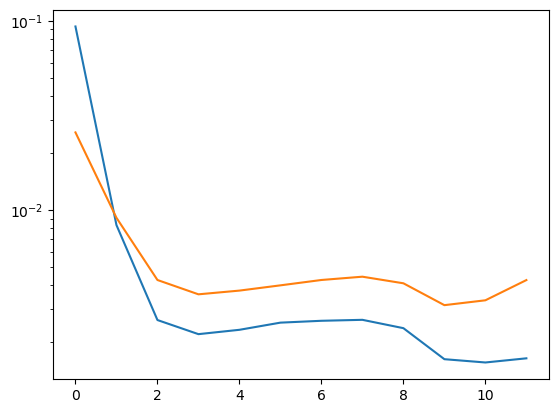

In [103]:
from src.utils import compute_radial_psd_error

plt.plot(compute_radial_psd_error(preds_gt_traj[0, 0], data[:,1]).values())
plt.plot(compute_radial_psd_error(preds_gt_traj[1, 0], data[:,1]).values())

print(torch.mean((preds_gt_traj[0, 0] - data[:,1].cpu())**2))
print(torch.mean((preds_gt_traj[1, 0] - data[:,1].cpu())**2))
plt.yscale('log')

In [113]:
hybrid_img, band_choices = bandwise_hybrid(preds_gt_traj[0,0].cpu(), preds_gt_traj[1, 0].cpu(), data[:,1].cpu())
print(torch.mean((torch.Tensor(hybrid_img) - data[:,1].cpu())**2))

tensor(6.8463e-07)


In [130]:
preds = []

with torch.no_grad():
    pred = data[:, 0]
    for i in range(traj_length):
        pred_1 = m_unet_1(pred, time=None)
        pred_2 = m_unet_2(pred, time=None)

        hybrid_img, _ = bandwise_hybrid_torch(pred_1, pred_2, band_choice=band_choices)

        preds.append(hybrid_img)

In [132]:
print([(torch.mean((preds[t]-data[:,t+1])**2)).cpu() for t in range(traj_length)])

[tensor(6.8465e-07), tensor(0.0565), tensor(0.1851), tensor(0.3370), tensor(0.4850), tensor(0.6170), tensor(0.7304), tensor(0.8271), tensor(0.9105), tensor(0.9846), tensor(1.0529), tensor(1.1178), tensor(1.1792), tensor(1.2364), tensor(1.2880), tensor(1.3325), tensor(1.3690), tensor(1.3979), tensor(1.4198), tensor(1.4370), tensor(1.4516), tensor(1.4643), tensor(1.4754), tensor(1.4849), tensor(1.4928), tensor(1.4995), tensor(1.5051), tensor(1.5096), tensor(1.5126), tensor(1.5145), tensor(1.5167), tensor(1.5202), tensor(1.5256), tensor(1.5340), tensor(1.5451)]


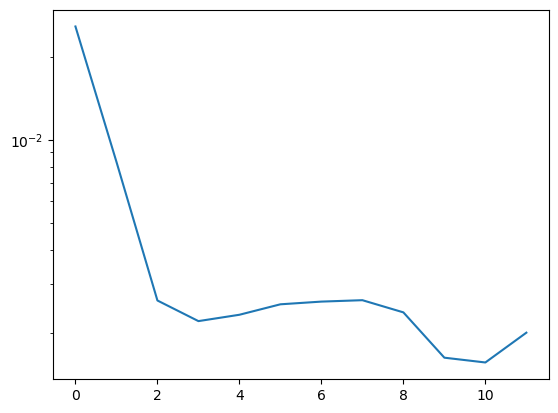

In [131]:
plt.plot(compute_radial_psd_error(torch.Tensor(hybrid_img), data[:,1]).values())
plt.yscale('log')

In [2]:
import torch

def bandwise_hybrid_torch(A: torch.Tensor, B: torch.Tensor, data: torch.Tensor = None, num_bands: int = 12, band_choice=None) -> torch.Tensor:
    """
    Build a hybrid signal that keeps A's Fourier coefficients in frequency bands
    where A (on average over dataset) is closer to data than B (in terms of PSD error),
    and B's coefficients otherwise.

    Args:
        A, B, data: tensors of shape (N, C, H, W), real-valued
        num_bands: number of radial frequency bands

    Returns:
        hybrid: tensor of shape (N, C, H, W), real-valued
    """

    device = A.device
    N, C, H, W = A.shape

    # FFTs (shifted to center frequencies)
    FA = torch.fft.fftshift(torch.fft.fft2(A, dim=(-2, -1)), dim=(-2, -1))
    FB = torch.fft.fftshift(torch.fft.fft2(B, dim=(-2, -1)), dim=(-2, -1))
    if data is not None:
        Fdata = torch.fft.fftshift(torch.fft.fft2(data, dim=(-2, -1)), dim=(-2, -1))

    # Radii map
    yy, xx = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing="ij")
    center_y, center_x = H // 2, W // 2
    radii = torch.sqrt((xx - center_x).float()**2 + (yy - center_y).float()**2)
    max_radius = radii.max()
    bin_edges = torch.linspace(0, max_radius, num_bands + 1, device=device)

    # Decide ownership per band
    if band_choice is None:
        band_choice = []
        for b in range(num_bands):
            mask = (radii >= bin_edges[b]) & (radii < bin_edges[b + 1])
            if not mask.any():
                band_choice.append("A")  # arbitrary
                continue

            # Compute mean errors
            err_A = torch.mean(torch.abs(FA[:, :, mask] - Fdata[:, :, mask])**2)
            err_B = torch.mean(torch.abs(FB[:, :, mask] - Fdata[:, :, mask])**2)

            band_choice.append("A" if err_A < err_B else "B")

    # Build hybrid Fourier spectrum
    Fhybrid = torch.zeros_like(FA, dtype=torch.complex64)
    for b in range(num_bands):
        mask = (radii >= bin_edges[b]) & (radii < bin_edges[b + 1])
        if band_choice[b] == "A":
            Fhybrid[:, :, mask] = FA[:, :, mask]
        else:
            Fhybrid[:, :, mask] = FB[:, :, mask]

    # Inverse FFT
    hybrid = torch.fft.ifft2(torch.fft.ifftshift(Fhybrid, dim=(-2, -1)), dim=(-2, -1)).real

    return hybrid, band_choices


### Phase/Magnitude recombination from 2 different models to check if there is EBs

In [3]:
import torch

def image_with_phase_and_psd(
    image_phase: torch.Tensor,
    image_magnitude: torch.Tensor,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Construct an image using the phase of `image_phase` and 
    the PSD magnitude of `image_magnitude`.

    Args:
        image_phase (torch.Tensor): Image tensor (N, C, H, W) providing the phase.
        image_magnitude (torch.Tensor): Image tensor (N, C, H, W) providing the PSD magnitude.
        device (str): Device for computation.

    Returns:
        torch.Tensor: Hybrid image with phase from `image_phase` and magnitude from `image_magnitude`.
    """
    image_phase = image_phase.to(device)
    image_magnitude = image_magnitude.to(device)

    # FFTs
    fft_phase = torch.fft.fft2(image_phase)
    fft_magnitude = torch.fft.fft2(image_magnitude)

    # Extract phase (from image_phase)
    phase = torch.angle(fft_phase)

    # Extract amplitude (sqrt of PSD) from image_magnitude
    amplitude = torch.abs(fft_magnitude)

    # Recombine magnitude + phase
    new_fft = amplitude * torch.exp(1j * phase)

    # Inverse FFT → image domain
    hybrid_image = torch.fft.ifft2(new_fft).real

    return hybrid_image


In [6]:
recombined_image = image_with_phase_and_psd(preds_self_traj[0, 0] - data[:,1].cpu(), preds_self_traj[1, 0] - data[:,0+1].cpu())

In [7]:
torch.mean((recombined_image)**2)

tensor(9.4950e-07)

In [8]:
torch.mean((m_unet_2(data[:,1] + recombined_image.to('cuda'), time=None) - data[:, 2])**2)

tensor(1.7029e-06, device='cuda:0', grad_fn=<MeanBackward0>)

In [33]:
torch.mean((m_unet_2(preds_self_traj[0,1].to('cuda'), time=None) - data[:,3])**2)

tensor(2.8281e-06, device='cuda:0', grad_fn=<MeanBackward0>)

In [ ]:
for t in range(5):
    print(torch.mean((preds_self_traj[0, t] - data[:,t+1].cpu())**2))
    print(torch.mean((preds_self_traj[1, t] - data[:,t+1].cpu())**2))

tensor(7.6936e-07)
tensor(9.4950e-07)
tensor(1.7513e-06)
tensor(1.7876e-06)
tensor(3.1772e-06)
tensor(2.8673e-06)
tensor(5.1909e-06)
tensor(4.2153e-06)
tensor(7.9943e-06)
tensor(5.8620e-06)


How to separate systematic drift vs exposure bias, i.e. can we know how much of error comes from the exposure bias ? Given that we can only measure model with others : it could be that for instance, Unet-2 has less exposure bias, but error increase rate is similar : In the difference of errors between 2 steps $\epsilon_1 - \epsilon_2$, how much error is induced by trajectory drift and how much by EB ?

### Resolution 32

In [21]:
m_eval =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_39/best_model.pth')
m_eval.load_state_dict(checkpoint)

m_eval = Unet(
            dim=32,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_32_ts_1_dim_32_framesPerTs_1_unet-periodicconv-m2_00/Model.pth")['stateDictDecoder']
#checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

Unet(
  (init_conv): Conv2d(2, 20, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=circular)
  (downs): ModuleList(
    (0): ModuleList(
      (0): ConvNextBlock(
        (ds_conv): Conv2d(20, 20, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=20, padding_mode=circular)
        (net): Sequential(
          (0): GroupNorm(1, 20, eps=1e-05, affine=True)
          (1): Conv2d(20, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
          (2): GELU(approximate='none')
          (3): GroupNorm(1, 32, eps=1e-05, affine=True)
          (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
        )
        (res_conv): Conv2d(20, 32, kernel_size=(1, 1), stride=(1, 1), padding_mode=circular)
      )
      (1): ConvNextBlock(
        (ds_conv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=32, padding_mode=circular)
        (net): Sequential(
          (0): GroupNorm(1, 32, 

In [29]:
m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_37/best_model.pth')
m1.load_state_dict(checkpoint)

<All keys matched successfully>

In [30]:
m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_100/best_model.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [36]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 32,
        "sequence_length": [10, 1],
        "trajectory_sequence_length": [40, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 500
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

KeyError: 'dataset_name'

In [4]:
import torch

def run_model(model, x):
    """Wrapper for forward pass."""
    if isinstance(model, DiffusionModel):
        return model(x)
    else:
        return model(x, time=None)

def evaluate_models(models, m_eval, traj_loader, device, rollout_steps=30, with_meta_eval=False):
    """
    Compare:
    - plain model rollouts vs. m_eval rollouts (eval_distances)
    - plain model rollouts vs. model(eval(model)) rollouts (meta_distances)

    Args:
        models (dict): { "name": model } dictionary of models to evaluate
        m_eval (nn.Module): evaluator model
        traj_loader (DataLoader): trajectory loader
        device (torch.device): device to run on
        rollout_steps (int): number of rollout steps

    Returns:
        dict with:
            predictions[name]: list of model rollout tensors
            meta_eval[name]: list of model(eval(model)) rollout tensors
            eval_distances[name]: list of distances vs m_eval
            meta_distances[name]: list of distances vs meta trajectory
    """
    # Put all models in eval mode
    for model in list(models.values()) + [m_eval]:
        model.eval()

    if with_meta_eval :
        meta_eval = {name: [] for name in models}
        meta_distances = {name: [] for name in models}
        meta_preds = {name: [] for name in models}
    
    eval_distances = {name: [] for name in models}

    with torch.no_grad():
        sample = next(iter(traj_loader))

        data = sample["data"].to(device)
        print("Input shape:", data.shape)

        conditioning_frame = data[:, 0]

        # Initialize plain and meta trajectories
        preds = {name: run_model(model, conditioning_frame) for name, model in models.items()}
        predictions = {name: [preds[name]] for name, model in models.items()}
        

        # Store step 0
        for name, model in models.items():    
            pred_eval = run_model(m_eval, conditioning_frame)
            if with_meta_eval:
                meta_preds[name].append(pred_eval)
            eval_distances[name].append(torch.mean((pred_eval - preds[name]) ** 2))

        # Rollout
        for t in range(rollout_steps):
            for name, model in models.items():

                eval_pred_on_model = run_model(m_eval, preds[name])

                if with_meta_eval:
                    model_pred_on_eval = run_model(model, meta_preds[name])
                    meta_preds[name] = eval_pred_on_model
                
                # plain model step
                preds[name] = run_model(model, preds[name])
                predictions[name].append(preds[name])
                
                # distance vs m_eval
                eval_distances[name].append(torch.mean((eval_pred_on_model - preds[name]) ** 2))
                # distance vs meta trajectory
                if with_meta_eval:
                    meta_distances[name].append(torch.mean((model_pred_on_eval - preds[name]) ** 2))

    if with_meta_eval:
        return {
            "predictions": preds,
            "meta_eval": meta_eval,
            "eval_distances": eval_distances,
            "meta_distances": meta_distances,
        }
    return {"predictions": predictions,
            "eval_distances": eval_distances,
            "data": data}


In [18]:
results = evaluate_models({"diffusion-1step-quadratic-32x32" : m1, "diffusion-2steps-quadratic-32x32" : m2}, m_eval, val_loader, device, rollout_steps=20)

Input shape: torch.Size([64, 64, 2, 64, 64])


KeyboardInterrupt: 

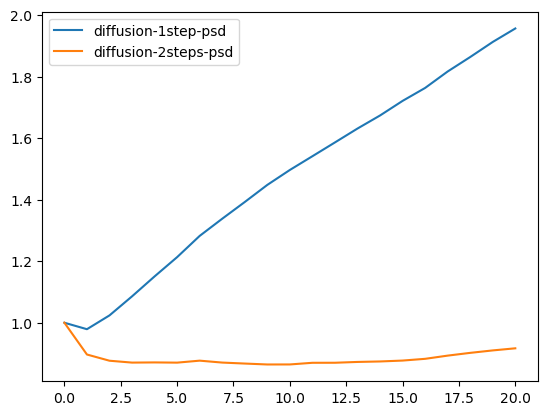

In [34]:
for k in results["eval_distances"].keys():
    plt.plot(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu(), label=k)

plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


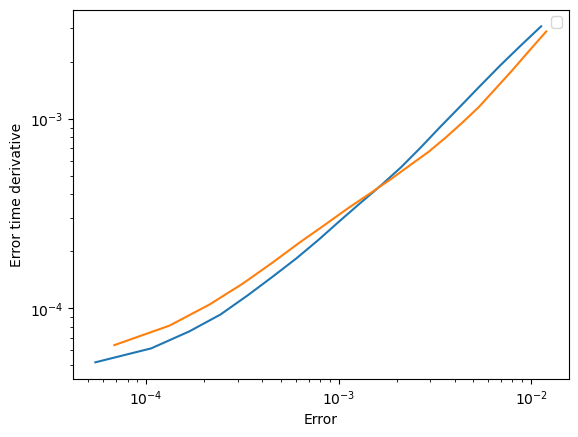

In [40]:
for k in results["eval_distances"].keys():
    errors = torch.Tensor([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(20)])
    plt.plot(errors[:-1], torch.diff(errors))

plt.yscale('log')
plt.xscale('log')
plt.ylabel("Error time derivative")
plt.xlabel("Error")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


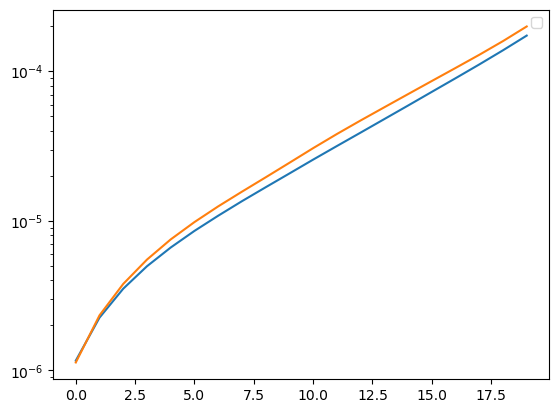

In [10]:
for k in results["eval_distances"].keys():
    plt.plot([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(20)])

plt.yscale('log')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.00027524037
0.00031701245


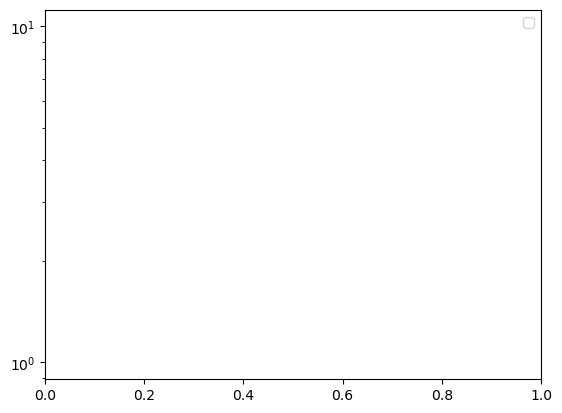

In [14]:
import numpy as np

for k in results["eval_distances"].keys():
    print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(30)]))

plt.yscale('log')
plt.legend()

In [48]:
for k in results["eval_distances"].keys():
    errors = torch.Tensor([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(20)])
    plt.plot(errors[:19], torch.diff(errors))

plt.yscale('log')
plt.xscale('log')
plt.ylabel("Error time derivative")
plt.xlabel("Error")
plt.legend()

[]

In [50]:
print(torch.median((predictions_m1[0] - predictions_m2[0])**2))


tensor(1.0324e-05, device='cuda:0')


### Resolution 64 : Is the exposure bias trend dependent on the evaluation model ? In particular, is the evaluation model more sensible to drift from M1 than drift from M2, without them having different exposure biases ?

In [5]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "dataset_name": "KolmogorovFlow",
        "resolution": 64,
        "sequence_length": [3, 1],
        "trajectory_sequence_length": [20, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [22]:
m_eval_1 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_1.load_state_dict(checkpoint)

m_eval_1.to(device)


m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_196/best_model.pth')
m1.load_state_dict(checkpoint)

m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [41]:
results = evaluate_models({"diffusion-2steps-psd": m1, "diffusion-1step-psd": m2}, m_eval_1, val_loader, device, rollout_steps=10)

Input shape: torch.Size([100, 10, 2, 64, 64])


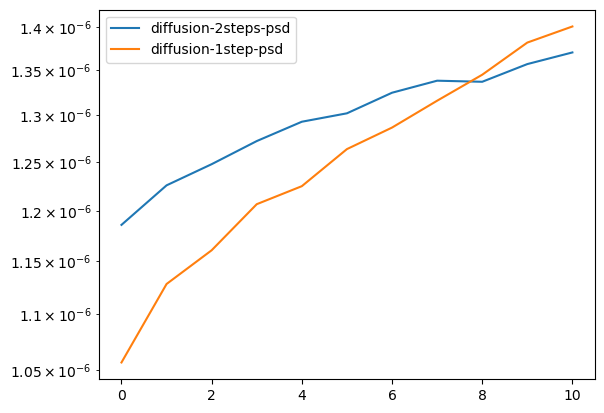

In [34]:
for i, k in enumerate(results["eval_distances"]):
    plt.plot(torch.Tensor(results["eval_distances"][k][:50]), label=k)

plt.yscale('log')

plt.legend()

In [39]:
import numpy as np
for k in results["eval_distances"].keys():
    print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)]))


7.4531686e-06
9.067734e-06


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[tensor(1.0393e-06), tensor(2.0435e-06), tensor(3.2092e-06), tensor(4.6027e-06), tensor(6.2380e-06), tensor(8.1947e-06), tensor(1.0625e-05), tensor(1.3662e-05), tensor(1.7464e-05)]
[tensor(1.0177e-06), tensor(2.1639e-06), tensor(3.6000e-06), tensor(5.3600e-06), tensor(7.4723e-06), tensor(1.0046e-05), tensor(1.3186e-05), tensor(1.7028e-05), tensor(2.1737e-05)]


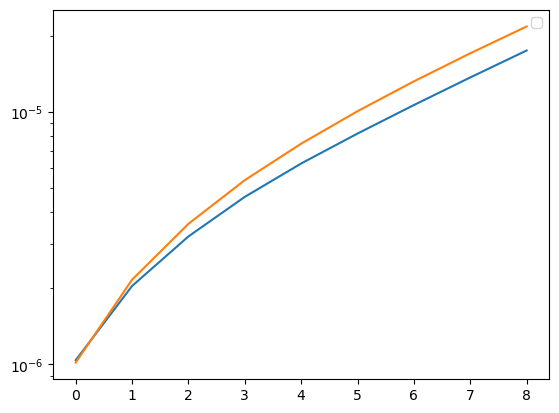

In [40]:
for k in results["eval_distances"].keys():
    print([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)])
    plt.plot([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)])


plt.yscale('log')
plt.legend()

In [6]:
m_eval_1 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_1.load_state_dict(checkpoint)

m_eval_1.to(device)


m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
m1.load_state_dict(checkpoint)

m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_243/best_model.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [8]:
results = evaluate_models({"diffusion-1step-linear": m1, "diffusion-2steps-linear": m2}, m_eval_1, traj_loader, device, rollout_steps=20)

Input shape: torch.Size([100, 20, 2, 64, 64])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[tensor(2.4961e-06), tensor(5.5629e-06), tensor(9.9194e-06), tensor(1.7531e-05), tensor(4.9992e-05), tensor(0.0001), tensor(0.0002), tensor(0.0004), tensor(0.0006), tensor(0.0008), tensor(0.0009), tensor(0.0011), tensor(0.0014), tensor(0.0017), tensor(0.0020), tensor(0.0024), tensor(0.0030), tensor(0.0038), tensor(0.0048)]
[tensor(3.1840e-06), tensor(6.7962e-06), tensor(1.1526e-05), tensor(1.7997e-05), tensor(2.6252e-05), tensor(3.7414e-05), tensor(5.5774e-05), tensor(7.7591e-05), tensor(0.0001), tensor(0.0001), tensor(0.0002), tensor(0.0002), tensor(0.0003), tensor(0.0004), tensor(0.0005), tensor(0.0006), tensor(0.0008), tensor(0.0010), tensor(0.0012)]


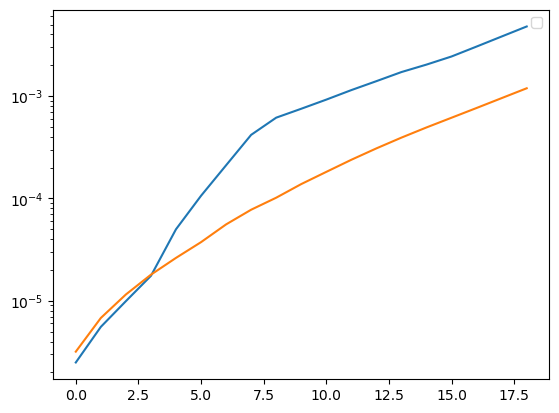

In [9]:
for k in results["eval_distances"].keys():
    print([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(19)])
    plt.plot([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(19)])


plt.yscale('log')
plt.legend()

In [11]:
import numpy as np
for k in results["eval_distances"].keys():
    print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)]))


0.00015959397
3.757748e-05


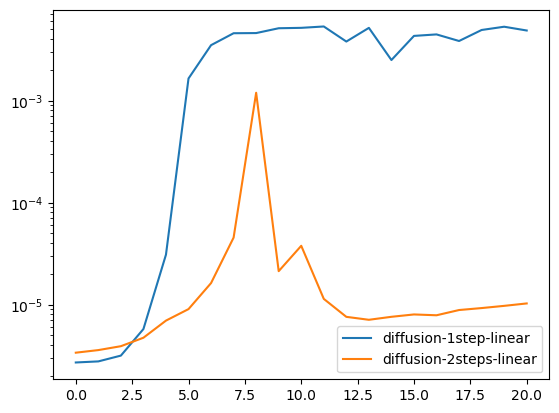

In [10]:
for i, k in enumerate(results["eval_distances"]):
    plt.plot(torch.Tensor(results["eval_distances"][k][:50]), label=k)

plt.yscale('log')

plt.legend()

In [29]:
m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)
print()

### Cubic schedule

In [4]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [40, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [9]:
m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_90/best_model.pth')
m1.load_state_dict(checkpoint)

m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_113/best_model.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [13]:
results = evaluate_models({"diffusion-1step-psd" : m1, "diffusion-2steps-psd" : m2}, m_eval, traj_loader, device, rollout_steps=10)

Input shape: torch.Size([100, 40, 2, 64, 64])


In [14]:
for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][0] - results["data"][:,1])**2).cpu())

tensor(3.9953e-06)
tensor(6.0948e-06)


In [15]:
for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][10] - results["data"][:,11])**2).cpu())

tensor(0.0003)
tensor(0.0005)


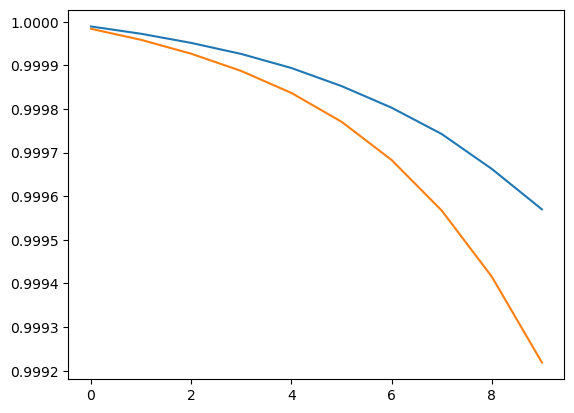

In [16]:
from src.utils import correlation, vorticity

for k in results["eval_distances"].keys():
    plt.plot([correlation(vorticity(results["predictions"][k][t].cpu()), vorticity(results["data"][:,t+1].cpu())) for t in range(10)])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


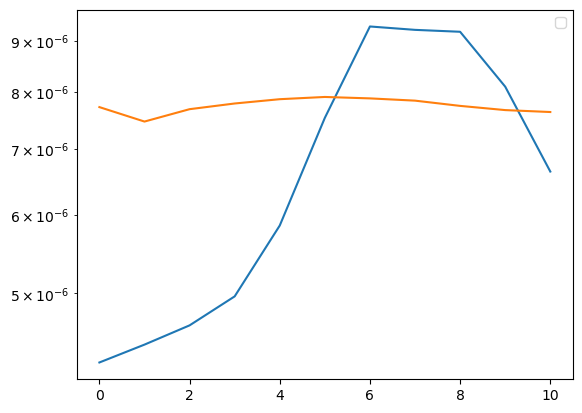

In [17]:
for k in results["eval_distances"].keys():
    #plt.plot(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu())
    plt.plot(torch.Tensor(results["eval_distances"][k]))
    #print(torch.sum(torch.diff(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu())))

plt.yscale('log')
plt.legend()


In [18]:
import torch

def spectral_vectors_torch(x, take_log=True, channel_reduce='flatten'):
    """
    Convert batch of 2D fields into flattened spectral magnitude vectors.
    Args:
        x: (N, H, W) or (N, H, W, C)
    Returns:
        spectral_vectors: (N, F)
    """
    if x.ndim == 3:
        N, H, W = x.shape
        C = None
    elif x.ndim == 4:
        N, H, W, C = x.shape
    else:
        raise ValueError("Expected (N,H,W) or (N,H,W,C)")

    x = x.to(torch.float64)
    out = []

    for i in range(x.shape[0]):
        if C is None:
            fft = torch.fft.fft2(x[i])
            mag = torch.abs(fft)
            if take_log:
                mag = torch.log1p(mag)
            out.append(mag.flatten())
        else:
            if channel_reduce == 'sum':
                mag_sum = torch.zeros((H, W), dtype=torch.float64, device=x.device)
                for c in range(C):
                    fft = torch.fft.fft2(x[i, :, :, c])
                    mag_sum += torch.abs(fft)
                if take_log:
                    mag_sum = torch.log1p(mag_sum)
                out.append(mag_sum.flatten())
            elif channel_reduce == 'flatten':
                ch_vecs = []
                for c in range(C):
                    fft = torch.fft.fft2(x[i, :, :, c])
                    mag = torch.abs(fft)
                    if take_log:
                        mag = torch.log1p(mag)
                    ch_vecs.append(mag.flatten())
                out.append(torch.cat(ch_vecs))
            else:
                raise ValueError("channel_reduce must be 'sum' or 'flatten'")

    return torch.stack(out, dim=0)  # (N, F)


def _cov_torch(x, eps=1e-6):
    """
    Estimate covariance matrix of shape (F, F)
    x: (N, F)
    """
    x = x - x.mean(dim=0, keepdim=True)
    N = x.shape[0]
    cov = (x.T @ x) / (N - 1)
    cov += torch.eye(cov.shape[0], device=x.device, dtype=x.dtype) * eps
    return cov


def _sqrtm_symmetric_torch(mat):
    """
    Matrix square root for symmetric positive semi-definite matrix.
    Uses eigen decomposition: mat = Q Λ Q^T → mat^(1/2) = Q Λ^(1/2) Q^T
    """
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = torch.clamp(eigvals, min=0)  # numerical safety
    sqrt_eigvals = torch.sqrt(eigvals)
    return (eigvecs * sqrt_eigvals.unsqueeze(0)) @ eigvecs.T


def frechet_distance_torch(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Compute squared Fréchet distance between two Gaussians.
    """
    diff = mu1 - mu2
    diff_sq = diff.dot(diff)

    # product sqrt: (sigma1 * sigma2)^(1/2)
    cov_prod = sigma1 @ sigma2
    covmean = _sqrtm_symmetric_torch(cov_prod)

    trace_term = torch.trace(sigma1) + torch.trace(sigma2) - 2 * torch.trace(covmean)
    trace_term = torch.clamp(trace_term, min=0)  # avoid tiny negatives
    return diff_sq + trace_term


def fsd_torch_full(real_samples, gen_samples, take_log=True,
                   channel_reduce='flatten', eps=1e-6, return_sqrt=False):
    """
    Fully torch-based Fréchet Spectral Distance.
    Args:
        real_samples, gen_samples: torch.Tensor (N, H, W) or (N, H, W, C)
        return_sqrt: if True, return sqrt(FSD^2)
    Returns:
        scalar torch.Tensor
    """
    Xr = spectral_vectors_torch(real_samples, take_log, channel_reduce)
    Xg = spectral_vectors_torch(gen_samples, take_log, channel_reduce)

    mu_r = Xr.mean(dim=0)
    mu_g = Xg.mean(dim=0)

    cov_r = _cov_torch(Xr, eps)
    cov_g = _cov_torch(Xg, eps)

    fsd_sq = frechet_distance_torch(mu_r, cov_r, mu_g, cov_g, eps)
    return torch.sqrt(fsd_sq) if return_sqrt else fsd_sq


In [81]:
t=0
for k in results["eval_distances"].keys():
    print(fsd_torch_full(results["predictions"][k][t], results["data"][:,t+1]))

tensor(0.0079, device='cuda:0', dtype=torch.float64)
tensor(0.0206, device='cuda:0', dtype=torch.float64)


In [31]:
results["predictions"][k][0].shape

torch.Size([100, 2, 64, 64])

dict_values([277060.50591372943, 25096.37762456908, 764.3077504517892, 98.41016664980036, 20.81539776844693, 5.702244927830284, 1.731756667376133, 0.5989280026926479, 0.2698785679143871, 0.11042898866952931, 0.04859168995022567, 0.025942116598801582])
dict_values([287442.4128791362, 25003.14018262439, 724.4814839209824, 97.02418486175169, 20.383383702784624, 5.544267016935261, 1.6966885817952755, 0.5804606265886383, 0.2572606191168346, 0.10936070181240375, 0.049012893717343714, 0.02970987158683258])
dict_values([276678.40139336046, 24963.189665102895, 753.6318073314759, 100.19126935839853, 21.29439145857845, 5.817123631988726, 1.7738453738881297, 0.6071839636121267, 0.27367380827416804, 0.1171816927180627, 0.051743639937766026, 0.030404764463392412])


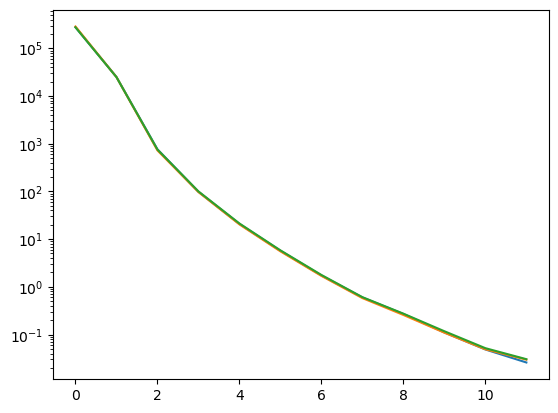

In [86]:
from src.utils import compute_radial_psd_error
t=30

for k in results["eval_distances"].keys():
    plt.plot(compute_radial_psd_error(results["predictions"][k][t], torch.zeros(results["predictions"][k][t].shape)).values())
    print(compute_radial_psd_error(results["predictions"][k][t], torch.zeros(results["predictions"][k][t].shape)).values())

plt.plot(compute_radial_psd_error(results["data"][:,t+1], torch.zeros(results["predictions"][k][10].shape)).values())
print(compute_radial_psd_error(results["data"][:,t+1], torch.zeros(results["predictions"][k][10].shape)).values())


plt.yscale('log')
#plt.xscale('log')

In [20]:
import torch

# ---------- Utilities ----------

def _fft_magnitude(x, take_log=True):
    """Compute magnitude of 2D FFT for tensor (N,C,H,W)."""
    fft = torch.fft.fft2(x)
    mag = torch.abs(fft)
    if take_log:
        mag = torch.log1p(mag)
    return mag


def _radial_average(psd2d):
    """Compute radially averaged power spectrum for (H,W) or (N,C,H,W)."""
    if psd2d.ndim == 4:
        N, C, H, W = psd2d.shape
        cy, cx = H // 2, W // 2
        y, x = torch.meshgrid(torch.arange(H, device=psd2d.device),
                              torch.arange(W, device=psd2d.device),
                              indexing='ij')
        r = torch.sqrt((x - cx)**2 + (y - cy)**2).to(torch.int64)
        nbins = int(r.max()) + 1
        radial_profiles = []
        for n in range(N):
            ch_profiles = []
            for c in range(C):
                psd_flat = psd2d[n, c].flatten()
                r_flat = r.flatten()
                tbin = torch.bincount(r_flat, weights=psd_flat, minlength=nbins)
                nr = torch.bincount(r_flat, minlength=nbins).float()
                radial = tbin / (nr + 1e-8)
                ch_profiles.append(radial)
            radial_profiles.append(torch.stack(ch_profiles))
        return torch.stack(radial_profiles)  # (N,C,K)
    else:
        raise ValueError("Expected (N,C,H,W)")


def _cov_torch(x, eps=1e-6):
    """Covariance along batch dimension."""
    x = x - x.mean(dim=0, keepdim=True)
    N = x.shape[0]
    cov = (x.T @ x) / (N - 1)
    cov += torch.eye(cov.shape[0], device=x.device, dtype=x.dtype) * eps
    return cov


def _sqrtm_symmetric_torch(mat):
    """Matrix square root via eigen-decomposition (symmetric PSD case)."""
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = torch.clamp(eigvals, min=0)
    sqrt_eigvals = torch.sqrt(eigvals)
    return (eigvecs * sqrt_eigvals.unsqueeze(0)) @ eigvecs.T


def frechet_distance_torch(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Compute squared Fréchet distance between two Gaussians.
    """
    diff = mu1 - mu2
    diff_sq = diff.dot(diff)

    # product sqrt: (sigma1 * sigma2)^(1/2)
    cov_prod = sigma1 @ sigma2
    covmean = _sqrtm_symmetric_torch(cov_prod)

    trace_term = torch.trace(sigma1) + torch.trace(sigma2) - 2 * torch.trace(covmean)
    trace_term = torch.clamp(trace_term, min=0)  # avoid tiny negatives
    return diff_sq + trace_term


# ---------- Metrics ----------

def spectral_psd_error(pred, true):
    """
    Mean relative error of radially averaged power spectra.
    pred, true: (N,C,H,W)
    """
    Fp = torch.fft.fftshift(torch.fft.fft2(pred))
    Ft = torch.fft.fftshift(torch.fft.fft2(true))
    psd_pred = torch.abs(Fp) ** 2
    psd_true = torch.abs(Ft) ** 2

    rad_pred = _radial_average(psd_pred)
    rad_true = _radial_average(psd_true)

    rel_err = ((rad_pred - rad_true) ** 2) / (rad_true ** 2 + 1e-8)
    return rel_err.mean()


def spectral_coherence(pred, true):
    """
    Global spectral coherence between predicted and true fields.
    pred, true: (N,C,H,W)
    Returns: scalar in [0,1].
    """
    Fp = torch.fft.fft2(pred)
    Ft = torch.fft.fft2(true)
    num = torch.abs((Fp * Ft.conj()).mean(dim=(-2, -1)))
    denom = torch.sqrt((torch.abs(Fp) ** 2).mean(dim=(-2, -1)) *
                       (torch.abs(Ft) ** 2).mean(dim=(-2, -1)))
    coherence = (num / (denom + 1e-8)).mean()
    return coherence


def fsd_torch_full(real, gen, take_log=True, eps=1e-6, return_sqrt=False):

    N, C, H, W = real.shape
    real_mag = _fft_magnitude(real, take_log)
    gen_mag = _fft_magnitude(gen, take_log)

    # Flatten spatial dims and channels per sample
    Xr = real_mag.view(N, -1)
    Xg = gen_mag.view(N, -1)

    mu_r = Xr.mean(dim=0)
    mu_g = Xg.mean(dim=0)
    cov_r = _cov_torch(Xr, eps)
    cov_g = _cov_torch(Xg, eps)

    fsd_sq = frechet_distance_torch(mu_r, cov_r, mu_g, cov_g)
    return torch.sqrt(fsd_sq) if return_sqrt else fsd_sq


# ---------- Combined evaluator ----------

def spectral_metrics(pred, true):
    """
    Compute spectral correctness metrics between predicted and ground-truth fields.
    Input: (N,C,H,W) tensors
    Output: dict with PSD error, coherence, FSD
    """
    return {
        "psd_error": spectral_psd_error(pred, true),
        "coherence": spectral_coherence(pred, true),
        "fsd": fsd_torch_full(true, pred, return_sqrt=False)
    }


In [21]:
t=5
for k in results["eval_distances"].keys():
    print(spectral_metrics(results["predictions"][k][t], results["data"][:,t+1]))

{'psd_error': tensor(2.4388e+08, device='cuda:0'), 'coherence': tensor(1.0000, device='cuda:0'), 'fsd': tensor(4.4296, device='cuda:0')}
{'psd_error': tensor(6.6677e+08, device='cuda:0'), 'coherence': tensor(0.9999, device='cuda:0'), 'fsd': tensor(6.5061, device='cuda:0')}


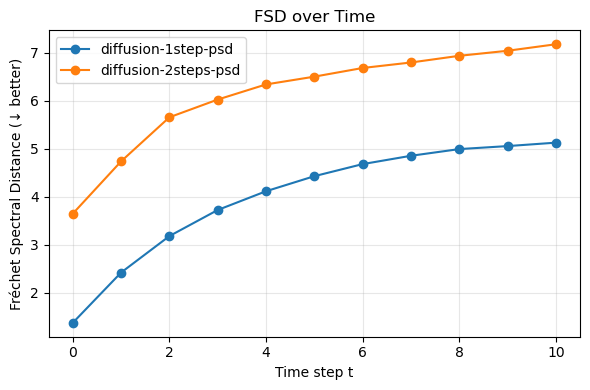

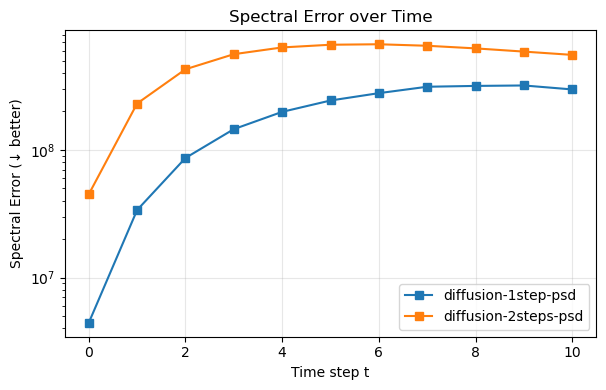

In [22]:
import torch
import matplotlib.pyplot as plt

# Range of time steps to evaluate
T_max = 10

# Store results for all models
metric_over_time = {}

for k in results["eval_distances"].keys():
    fsd_vals = []
    psd_vals = []

    for t in range(T_max + 1):
        pred = results["predictions"][k][t]      # (N,C,H,W)
        gt   = results["data"][:, t + 1]         # (N,C,H,W)
        metrics = spectral_metrics(pred, gt)

        fsd_vals.append(metrics["fsd"].item())
        psd_vals.append(metrics["psd_error"].item())

    metric_over_time[k] = {
        "fsd": torch.tensor(fsd_vals),
        "psd_error": torch.tensor(psd_vals)
    }

# ---- Plot FSD over time ----
plt.figure(figsize=(6, 4))
for k, vals in metric_over_time.items():
    plt.plot(range(T_max + 1), vals["fsd"], marker='o', label=f'{k}')
plt.xlabel("Time step t")
plt.ylabel("Fréchet Spectral Distance (↓ better)")
plt.title("FSD over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot Spectral Error over time ----
plt.figure(figsize=(6, 4))
for k, vals in metric_over_time.items():
    plt.plot(range(T_max + 1), vals["psd_error"], marker='s', label=f'{k}')
plt.xlabel("Time step t")
plt.ylabel("Spectral Error (↓ better)")
plt.title("Spectral Error over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()


In [ ]:
t=0
for k in results["eval_distances"].keys():
    print(spectral_metrics(results["predictions"][k][t], results["data"][:,t+1]))

In [2]:
import torch
import matplotlib.pyplot as plt

def evaluate_multiple_checkpoints(
    checkpoint_dir_run108,
    checkpoint_dir_run109,
    eval_model,
    traj_loader,
    device,
    checkpoints=[901, 921, 941, 961, 981, "best"],
    rollout_steps=10,
):
    """
    Evaluate multiple checkpoints for two diffusion models (run_108 and run_109)
    and plot error at t=0 vs t=10, annotated with eval_distances metric.

    Args:
        checkpoint_dir_run108 (str): Path to run_108 checkpoint directory.
        checkpoint_dir_run109 (str): Path to run_109 checkpoint directory.
        eval_model (torch.nn.Module): Evaluation UNet model.
        traj_loader (DataLoader): Data loader for trajectories.
        device (torch.device): Torch device (e.g., 'cuda' or 'cpu').
        checkpoints (list): List of checkpoint identifiers (integers or 'best').
        rollout_steps (int): Number of rollout steps for evaluation.

    Returns:
        dict: results per checkpoint, each containing evaluation output.
    """

    def load_diffusion_model(checkpoint_path):
        """Helper to load and return a DiffusionModel from a checkpoint."""
        model = DiffusionModel(
            **{
                "dimension": 2,
                "dataSize": [64, 64],
                "condChannels": 2,
                "diffSchedule": "cubic",
                "diffSteps": 100,
                "inferenceSamplingMode": "ddim",
                "inferenceConditioningIntegration": "clean",
                "diffCondIntegration": "clean",
                "inferenceInitialSampling": "random",
                "x0_estimate_type": "mean",
            }
        ).to(device)

        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        return model

    results_all = {}

    plt.figure(figsize=(8, 6))

    for ckpt in checkpoints:
        # Build checkpoint paths
        ckpt108 = (
            f"{checkpoint_dir_run108}/epoch_{ckpt}.pth"
            if ckpt != "best"
            else f"{checkpoint_dir_run108}/best_model.pth"
        )
        ckpt109 = (
            f"{checkpoint_dir_run109}/epoch_{ckpt}.pth"
            if ckpt != "best"
            else f"{checkpoint_dir_run109}/best_model.pth"
        )

        print(f"\n🧩 Evaluating checkpoints: {ckpt108} and {ckpt109}")

        # Load models
        m1 = load_diffusion_model(ckpt108)
        m2 = load_diffusion_model(ckpt109)

        # Evaluate
        results = evaluate_models(
            {"diffusion-1step-psd": m1, "diffusion-2steps-psd": m2},
            eval_model,
            traj_loader,
            device,
            rollout_steps=rollout_steps,
        )

        results_all[ckpt] = results

        # Compute mean squared error per time step
        mse_t1 = [
            torch.mean(
                (results["predictions"]["diffusion-1step-psd"][t] - results["data"][:, t + 1]) ** 2
            ).cpu().item()
            for t in range(rollout_steps)
        ]
        mse_t2 = [
            torch.mean(
                (results["predictions"]["diffusion-2steps-psd"][t] - results["data"][:, t + 1]) ** 2
            ).cpu().item()
            for t in range(rollout_steps)
        ]

        # Compute sum of normalized differences of eval_distances
        for model_key, color, marker in zip(
            ["diffusion-1step-psd", "diffusion-2steps-psd"], ["tab:blue", "tab:orange"], ["o", "x"]
        ):
            dist = torch.tensor(results["eval_distances"][model_key])
            metric = (dist[-1]/dist[0]).cpu().item()

            # Scatter and annotate
            x_val = mse_t1[0] if model_key == "diffusion-1step-psd" else mse_t2[0]
            y_val = mse_t1[-1] if model_key == "diffusion-1step-psd" else mse_t2[-1]

            plt.scatter(x_val, y_val, color=color, marker=marker, label=f"{model_key} @ {ckpt}")
            plt.text(
                x_val,
                y_val,
                f"{metric:.3f}",
                color=color,
                fontsize=9,
                ha="left",
                va="bottom",
            )

    # Finalize plot
    plt.xlabel("Error at t=0")
    plt.ylabel(f"Error at t={rollout_steps}")
    plt.title("Error evolution (t=0 vs t=10) across checkpoints")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_all



🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108/epoch_601.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_109/epoch_601.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108/epoch_641.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_109/epoch_641.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108/epoch_681.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_109/epoch_681.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108/epoch_721.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_109/epoch_721.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run

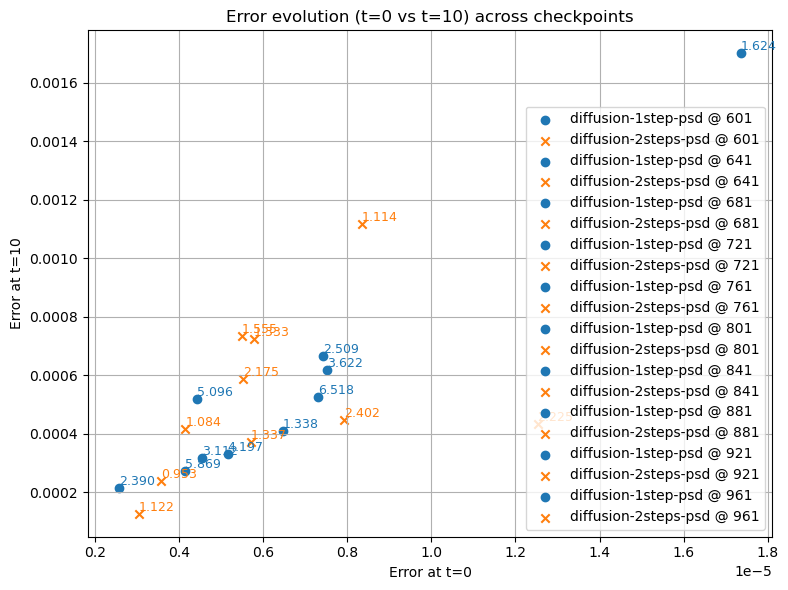

In [11]:
results_all = evaluate_multiple_checkpoints(
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108',
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_109',
    m_eval,
    traj_loader,
    device="cuda",
    checkpoints=[601, 641, 681, 721, 761, 801, 841, 881, 921, 961],
    rollout_steps=10
    )

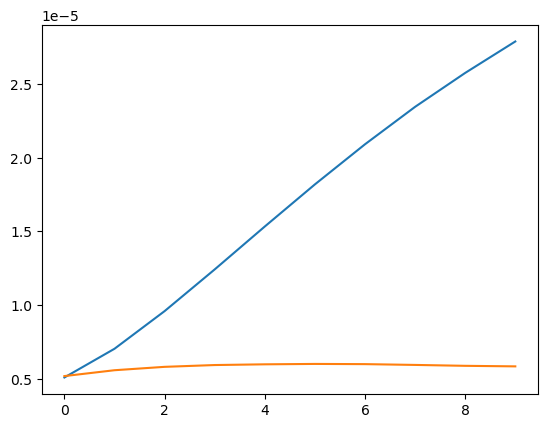

In [14]:
plt.plot(torch.Tensor([results_all[921]["eval_distances"]["diffusion-1step-psd"][k].cpu() for k in range(10)]))
plt.plot(torch.Tensor([results_all[881]["eval_distances"]["diffusion-2steps-psd"][k].cpu() for k in range(10)]))

Looking at different checkpoints is important as it shows that exposure bias reduction is not a "random" phenomenon that happens only at the last timestep, but actually a behaviour that stays constant during training. However, if we fit a linear-regression curve on the orange points, we actually observe that for a similar error at t=0, the error at t=10 is larger.


🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_110/epoch_901.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_111/epoch_901.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_110/epoch_921.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_111/epoch_921.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_110/epoch_941.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_111/epoch_941.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_110/epoch_961.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_111/epoch_961.pth
Input shape: torch.Size([100, 40, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run

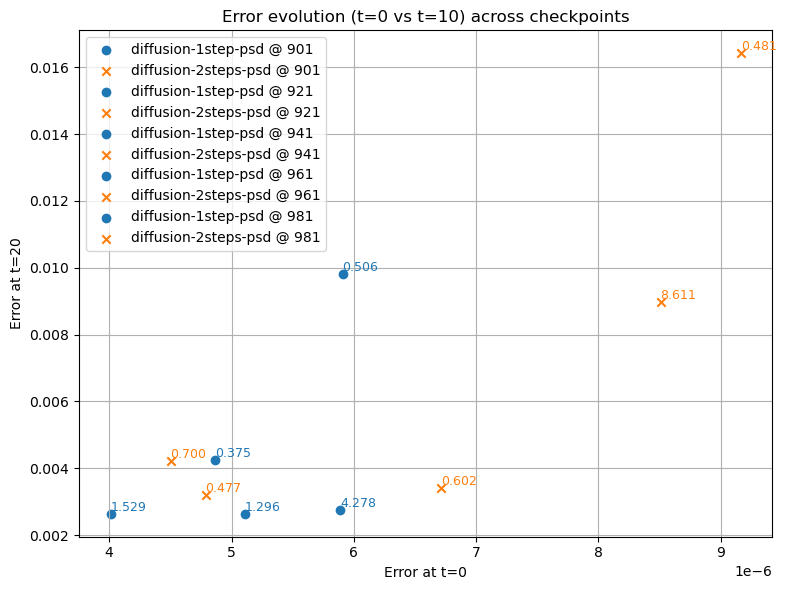

In [105]:
results_all = evaluate_multiple_checkpoints(
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_110',
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_111',
    m_eval,
    traj_loader,
    device="cuda",
    checkpoints=[901, 921, 941, 961, 981],
    rollout_steps=20
    )

In [128]:
print(torch.mean((results_all[981]["predictions"]["diffusion-2steps-psd"][0] - results["data"][:,1])**2).cpu())

tensor(8.5081e-06)


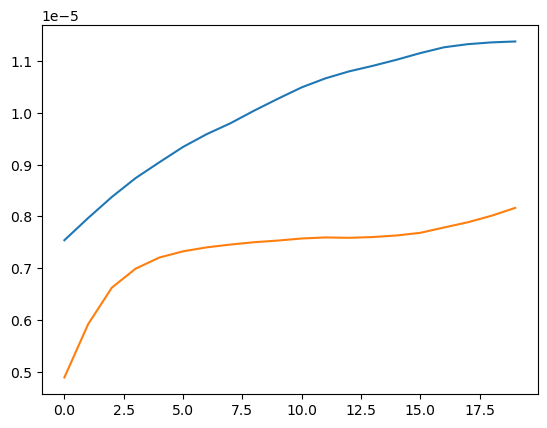

In [122]:
plt.plot(torch.Tensor([results_all[901]["eval_distances"]["diffusion-1step-psd"][k].cpu() for k in range(20)]))
plt.plot(torch.Tensor([results_all[961]["eval_distances"]["diffusion-2steps-psd"][k].cpu() for k in range(20)]))

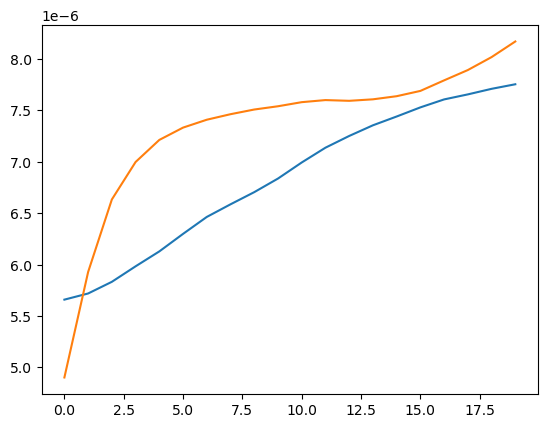

In [125]:
plt.plot(torch.Tensor([results_all[961]["eval_distances"]["diffusion-1step-psd"][k].cpu() for k in range(20)]))
plt.plot(torch.Tensor([results_all[961]["eval_distances"]["diffusion-2steps-psd"][k].cpu() for k in range(20)]))

In [90]:
torch.sum(torch.diff(torch.Tensor([results_all[961]["eval_distances"]["diffusion-1step-psd"][k].cpu() for k in range(10)])/results_all[961]["eval_distances"]["diffusion-1step-psd"][0].cpu()))

tensor(0.2089)

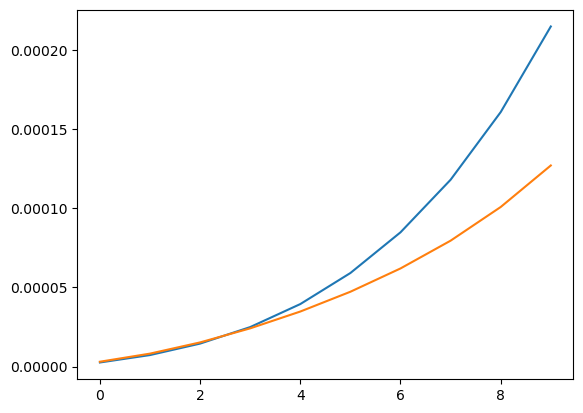

In [56]:
for k in results["eval_distances"].keys():
    plt.plot([torch.mean((results["predictions"][k][t] - results["data"][:,t+1])**2).cpu() for t in range(10)])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


tensor(1.3918)
tensor(0.1222)


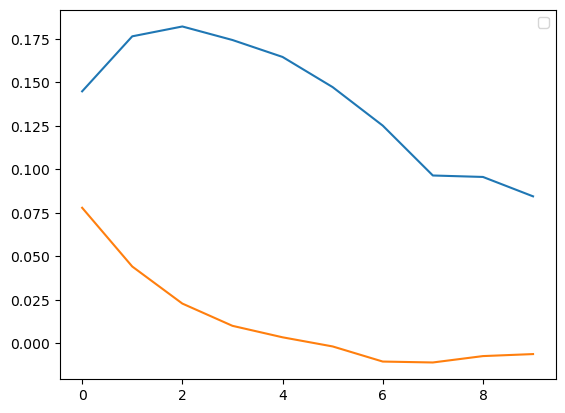

In [123]:
for k in results["eval_distances"].keys():
    plt.plot(torch.diff(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu()))
    print(torch.sum(torch.diff(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu())))

plt.legend()


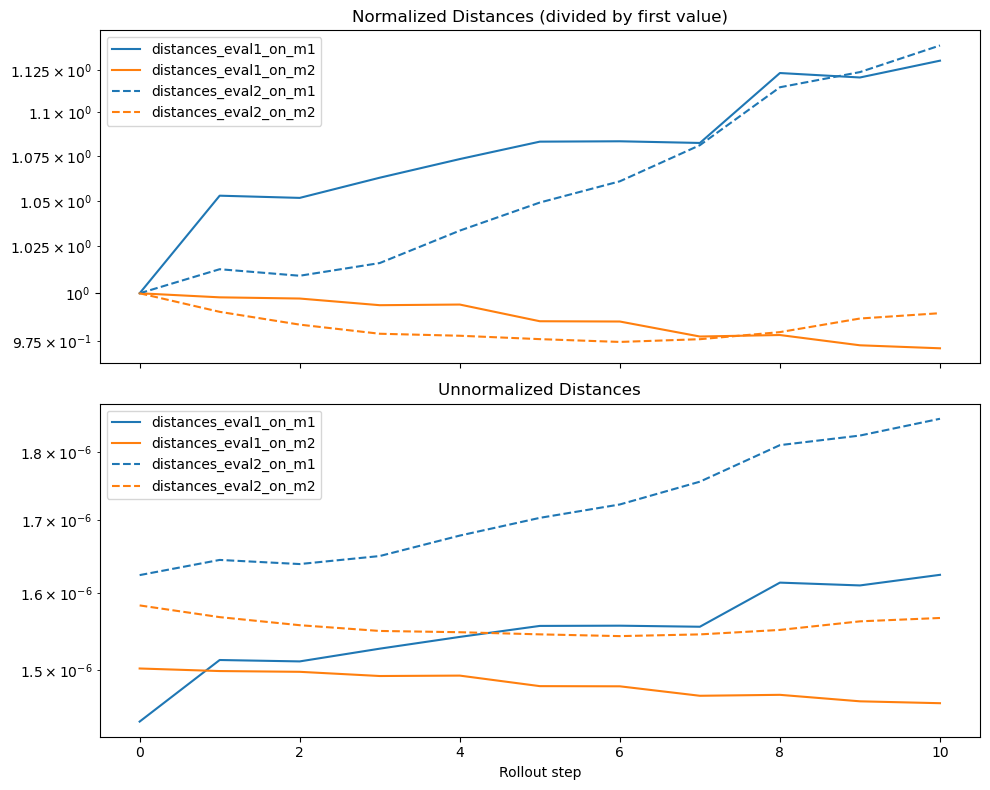

In [5]:
import matplotlib.pyplot as plt

# Define color/style mapping
color_map = {
    "m1": "tab:blue",
    "m2": "tab:orange",
}
style_map = {
    "eval1": "-",
    "eval2": "--",
}

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Normalized distances ---
for key in results:
    if key.startswith("distances"):
        values = torch.stack(results[key]).cpu()

        # Figure out which model and evaluator this belongs to
        model = "m1" if "m1" in key else "m2"
        eval_ = "eval1" if "eval1" in key else "eval2"

        axes[0].plot(
            values / values[0],
            label=key,
            color=color_map[model],
            linestyle=style_map[eval_],
        )

axes[0].set_title("Normalized Distances (divided by first value)")
axes[0].set_yscale('log')
axes[0].legend()

# --- Unnormalized distances ---
for key in results:
    if key.startswith("distances"):
        values = torch.stack(results[key]).cpu()

        model = "m1" if "m1" in key else "m2"
        eval_ = "eval1" if "eval1" in key else "eval2"

        axes[1].plot(
            values,
            label=key,
            color=color_map[model],
            linestyle=style_map[eval_],
        )

axes[1].set_title("Unnormalized Distances")
axes[1].set_yscale('log')
axes[1].legend()

plt.xlabel("Rollout step")
plt.tight_layout()
plt.show()

In [16]:
m2

DiffusionModel(
  (unet): Unet(
    (init_conv): Conv2d(4, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=circular)
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (downs): ModuleList(
      (0): ModuleList(
        (0): ConvNextBlock(
          (mlp): Sequential(
            (0): GELU(approximate='none')
            (1): Linear(in_features=256, out_features=42, bias=True)
          )
          (ds_conv): Conv2d(42, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=42, padding_mode=circular)
          (net): Sequential(
            (0): GroupNorm(1, 42, eps=1e-05, affine=True)
            (1): Conv2d(42, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
            (2): GELU(approximate='none')
            (3): GroupNorm(1, 64, eps=1e

In [8]:
print(torch.mean((results["predictions_m1"][0] - target)**2))
print(torch.mean((results["predictions_m2"][0] - target)**2))

print(torch.mean((results["predictions_m1"][1] - data[:,2])**2))
print(torch.mean((results["predictions_m2"][1] - data[:,2])**2))

print(torch.mean((results["predictions_m1"][2] - data[:,3])**2))
print(torch.mean((results["predictions_m2"][2] - data[:,3])**2))

tensor(4.5620e-06, device='cuda:0')
tensor(3.8626e-05, device='cuda:0')
tensor(1.4734e-05, device='cuda:0')
tensor(8.1849e-05, device='cuda:0')
tensor(3.0814e-05, device='cuda:0')
tensor(0.0001, device='cuda:0')


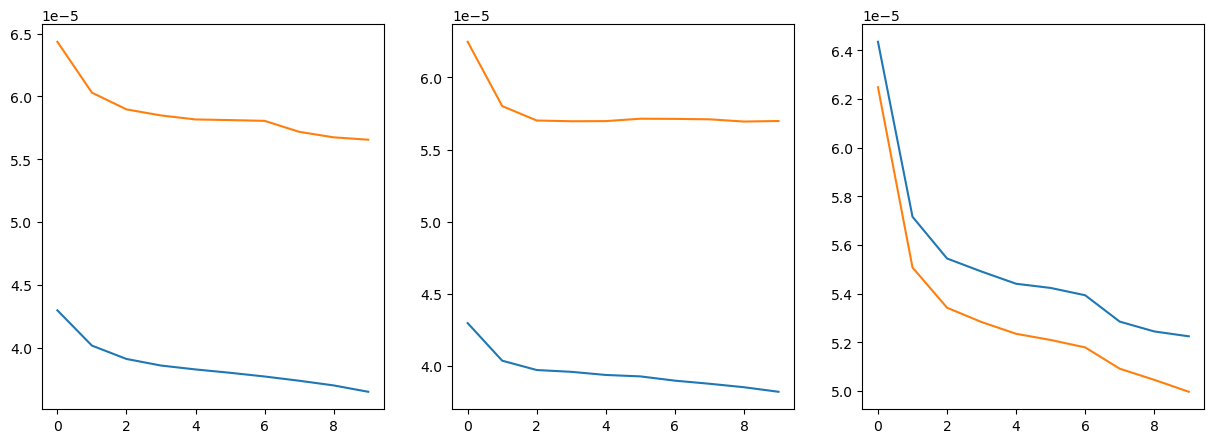

In [84]:
fig, axes = plt.subplots(1, distances_all.shape[0], figsize=(15,5))

for i in range(distances_all.shape[0]):
    for j in range(distances_all.shape[1]):
        axes[i].plot(distances_all[i, j])

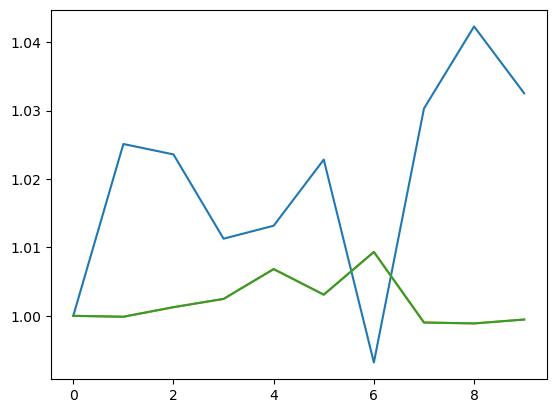

In [57]:
cross_distances_gt_traj = [[torch.mean((preds_gt_traj[i,t] - preds_gt_traj[(i+1)%3, t])**2) for t in range(traj_length)] for i in range(len(models))]

for dist in cross_distances_gt_traj:
    plt.plot(torch.Tensor(dist)/dist[0])

In [ ]:
distances_gt_traj = [[torch.mean((preds_gt_traj[i,t] - preds_gt_traj[(i+1)%3, t])**2) for t in range(traj_length)] for i in range(len(models))]

for dist in cross_distances_gt_traj:
    plt.plot(torch.Tensor(dist)/dist[0])

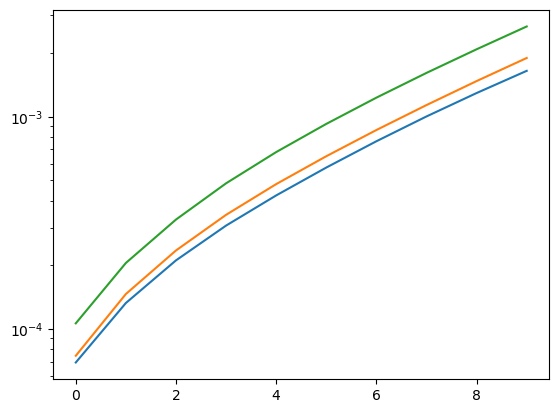

In [83]:
for i in range(len(errors)):
    plt.plot(errors[i, :10])
plt.yscale('log')

In [82]:
errors[:, 0], errors[:, 1]

(tensor([3.3394e-05, 4.4768e-05, 3.7899e-05]),
 tensor([6.5654e-05, 8.8113e-05, 7.3785e-05]))

One needs to show that exposure bias correlates with performance, i.e. a model with more cross-correlation drift performs less good.

In [41]:
print(torch.mean((prediction_m1_initial-target)**2))

tensor(3.4920e-05, device='cuda:0')


In [42]:
print(torch.mean((prediction_m2_initial-target)**2))

tensor(4.7462e-05, device='cuda:0')


In [43]:
print(torch.mean((prediction_psd_initial-target)**2))

tensor(4.0381e-05, device='cuda:0')


In [38]:
from src.utils import compute_radial_psd_error

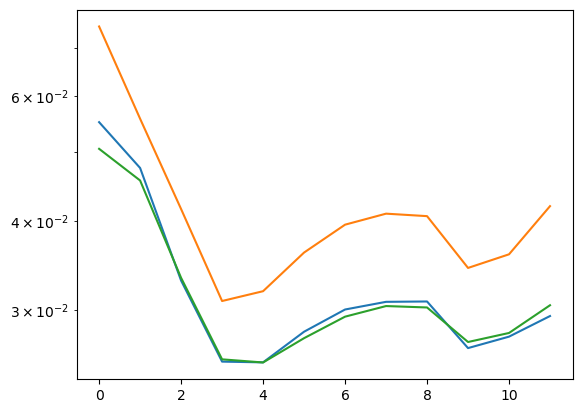

In [39]:
plt.plot(compute_radial_psd_error(prediction_m1_initial, target).values())
plt.plot(compute_radial_psd_error(prediction_m2_initial, target).values())
plt.plot(compute_radial_psd_error(prediction_psd_initial, target).values())
plt.yscale('log')

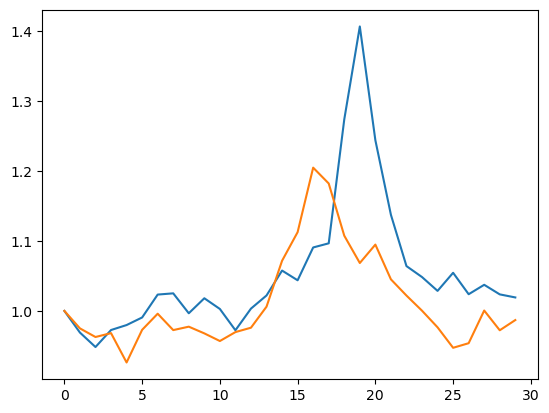

In [15]:
plt.plot(torch.Tensor(distances_m2_on_m1)/distances_m2_on_m1[0].cpu())
plt.plot(torch.Tensor(distances_m1_on_m2)/distances_m1_on_m2[0].cpu())

--> M1 is PSD, M2 is Quad. One can see that at some point, M1 commits some bias which leads distance to explode. M2 
It could also mean that M2 is more sensible to the drift of M1. But that means there is some long-term drift.

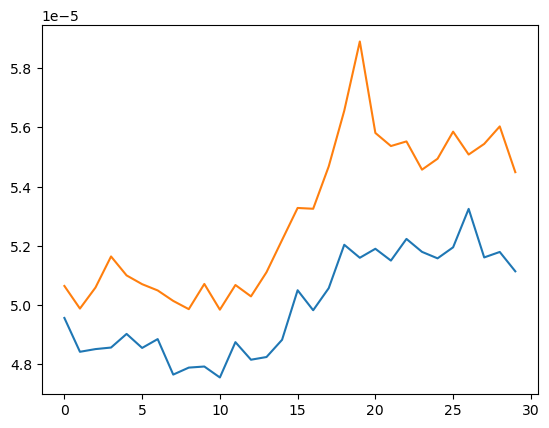

In [9]:
plt.plot(torch.Tensor(distances_m2_on_m1).cpu())
plt.plot(torch.Tensor(distances_m1_on_m2).cpu())